In [2]:
# ────────────────────────────────────────────────────────────
# Import libraries & set base paths
# ────────────────────────────────────────────────────────────
import pandas as pd
import re                       # (Not used directly below, but commonly
                                #  imported for regex work; kept for clarity)

#base_dir  = r"D:\lsy_DL\Oscilation"     # Working directory
#raw_csv   = fr"{base_dir}\0. Feature data_PIDoN4.csv"   # Source CSV file
#out_csv   = fr"{base_dir}\0. Feature data_withID.csv"  # Destination CSV file

base_dir  = r"D:\Code review\0. Training data"     # Working directory
raw_csv   = fr"{base_dir}\0. Feature data_Bayesian.csv"   # Source CSV file
out_csv   = fr"{base_dir}\0. Feature data_withID.csv"  # Destination CSV file



df = pd.read_csv(raw_csv)       # Read source data into a DataFrame

# ────────────────────────────────────────────────────────────
# Create a new column 'waveform_id'
#    Goal: convert strings like "30 voltage waveform" → "v30"
#    Steps:
#      ① Extract numeric part with regex r"(\d+)"
#      ② Cast to integer (optional but convenient)
#      ③ Prepend the letter 'v' to obtain the final ID
# ────────────────────────────────────────────────────────────
df["waveform_id"] = (
    df["V_name"]                       # target text column
    .str.extract(r"(\d+)", expand=False)   # ① extract digits only
    .astype(int)                          # ② convert to integer
    .apply(lambda x: f"v{x}")             # ③ add 'v' prefix → "v30"
)

df = df.drop(columns=["V_name"])
df.to_csv(out_csv, index=False)
print(f"✔  waveform_id created and saved →  {out_csv}")


✔  waveform_id created and saved →  D:\Code review\0. Training data\0. Feature data_withID.csv


In [3]:
# Load the processed feature CSV and preview the first 3 rows
#csv_path = r"D:\lsy_DL\Oscilation\0. Feature data_withID.csv"
csv_path = r"D:\Code review\0. Training data\0. Feature data_withID.csv"
df = pd.read_csv(csv_path)
print(df.head(3))
print(df.shape)


      mu   sigma   rho     c    t  v1        v2        v3  v4         v5  ...  \
0  15.76  0.0474  1114  1688  118   0  3.333333  6.666667  10  13.333333  ...   
1  15.76  0.0474  1114  1688  121   0  3.666667  7.333333  11  14.666667  ...   
2  15.76  0.0474  1114  1688  122   0  4.000000  8.000000  12  16.000000  ...   

   v292  v293  v294  v295  v296  v297  v298  v299  v300  waveform_id  
0     0     0     0     0     0     0     0     0     0          v20  
1     0     0     0     0     0     0     0     0     0          v22  
2     0     0     0     0     0     0     0     0     0          v24  

[3 rows x 306 columns]
(11, 306)


In [4]:
# Load the target CSV and preview the first row (q1 … q300)
tgt_path = r"D:\Code review\0. Training data\0. Target data_Bayesian.csv"
target_df = pd.read_csv(tgt_path)
print(target_df.head(1))
print(target_df.shape)

         q1        q2        q3        q4        q5        q6        q7  \
0  0.000001  0.000001  0.000001  0.000001  0.000001  0.000001  0.000001   

         q8        q9       q10  ...      q291      q292      q293      q294  \
0  0.000001  0.000001  0.000001  ...  0.000001  0.000001  0.000001  0.000001   

       q295      q296      q297      q298      q299      q300  
0  0.000001  0.000001  0.000001  0.000001  0.000001  0.000001  

[1 rows x 300 columns]
(11, 300)


In [5]:
import pandas as pd
import torch

# ────────────────────────────────
# Load feature data
# ────────────────────────────────
#csv_path = r"D:\lsy_DL\Oscilation\0. Feature data_withID.csv"
csv_path = r"D:\Code review\0. Training data\0. Feature data_withID.csv"
df = pd.read_csv(csv_path)
print("전체 shape:", df.shape)

# ────────────────────────────────
# 1. X1 = scalar physical parameters
# ────────────────────────────────
scalar_cols = ['mu', 'sigma', 'rho', 'c', 't']
X1 = df[scalar_cols].copy()
print("X1 shape:", X1.shape)

# ────────────────────────────────
# 2. X2 = voltage waveform vectors (v1 ~ v300)
# ────────────────────────────────
vec_cols = [c for c in df.columns if c.startswith("v") and c[1:].isdigit()]
X2 = df[vec_cols].copy()
print("X2 shape:", X2.shape)

# ────────────────────────────────
# 3. waveform_id
# ────────────────────────────────
waveform_id = df[['waveform_id']].copy()
print("waveform_id shape:", waveform_id.shape)

# ────────────────────────────────
# Convert to torch tensors (optional)
# ────────────────────────────────
X1_t = torch.tensor(X1.values, dtype=torch.float32)
X2_t = torch.tensor(X2.values, dtype=torch.float32)

print("Tensor X1:", X1_t.shape)
print("Tensor X2:", X2_t.shape)


전체 shape: (11, 306)
X1 shape: (11, 5)
X2 shape: (11, 300)
waveform_id shape: (11, 1)
Tensor X1: torch.Size([11, 5])
Tensor X2: torch.Size([11, 300])


---

In [6]:
import os, re
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ============================================================
# 0) Paths
# ============================================================
#base_dir   = r"D:\lsy_DL\Oscilation"
base_dir  = r"D:\Code review\0. Training data" 
feat_raw   = fr"{base_dir}\0. Feature data_withID.csv"   # (66,306)
tgt_raw    = fr"{base_dir}\0. Target data_Bayesian.csv"   # (66,300)
feat_csv   = fr"{base_dir}\features_Bayesian.csv"          # (66,6)
lib_csv    = fr"{base_dir}\waveforms_Bayesian.csv"         # (66,301)
tgt_out    = fr"{base_dir}\targets_Bayesian_withID.csv"    # (66,301)

# ============================================================
# 1) Load raw features
# ============================================================
raw = pd.read_csv(feat_raw)
print("[info] raw shape:", raw.shape)  # (66,306)

scalar_cols = ['mu','sigma','rho','c','t']
vec_cols = sorted([c for c in raw.columns if re.fullmatch(r'v\d+', c)],
                  key=lambda s: int(s[1:]))
q_cols = [f"q{i}" for i in range(1,301)]

# ============================================================
# 2) Save features (scalars+ID) and waveforms (ID+vectors)
# ============================================================
feat = raw[scalar_cols + ['waveform_id']].copy()
feat.to_csv(feat_csv, index=False)

waves = raw[['waveform_id'] + vec_cols].copy()
waves.to_csv(lib_csv, index=False)

print("[info] features rows:", len(feat))   # should be 66
print("[info] waveforms rows:", len(waves)) # should be 66

# ============================================================
# 3) Attach waveform_id to targets (1:1, same order)
# ============================================================
tgt = pd.read_csv(tgt_raw)
if len(tgt) != len(feat):
    raise ValueError(f"targets({len(tgt)}) vs features({len(feat)}) length mismatch")

tgt_out_df = tgt.copy()
tgt_out_df.insert(0, 'waveform_id', feat['waveform_id'].values)
tgt_out_df.to_csv(tgt_out, index=False)

print("[info] targets rows:", len(tgt_out_df))  # 66

# ============================================================
# 4) Merge into final training dataframe
# ============================================================
df = feat.merge(waves, on='waveform_id').merge(tgt_out_df, on='waveform_id')
print("[info] final merged shape:", df.shape)

# ============================================================
# 5) Convert to tensors
# ============================================================
X1 = torch.tensor(df[scalar_cols].to_numpy(dtype=np.float32))   # (66,5)
X2 = torch.tensor(df[vec_cols].to_numpy(dtype=np.float32))      # (66,300)
Y  = torch.tensor(df[q_cols].to_numpy(dtype=np.float32))        # (66,300)

print("X1.shape:", X1.shape)
print("X2.shape:", X2.shape)
print("Y.shape :", Y.shape)

# ============================================================
# 6) Optional: Dataset
# ============================================================
class PIDoNDataset(Dataset):
    def __init__(self, df, scalar_cols, vec_cols, q_cols):
        self.df = df
        self.scalar_cols = scalar_cols
        self.vec_cols = vec_cols
        self.q_cols = q_cols
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x1 = row[self.scalar_cols].to_numpy(dtype=np.float32)
        x2 = row[self.vec_cols].to_numpy(dtype=np.float32)
        y  = row[self.q_cols].to_numpy(dtype=np.float32)
        wid = row['waveform_id']
        return torch.from_numpy(x1), torch.from_numpy(x2), torch.from_numpy(y), wid

dataset = PIDoNDataset(df, scalar_cols, vec_cols, q_cols)
print("[info] dataset length:", len(dataset))


[info] raw shape: (11, 306)
[info] features rows: 11
[info] waveforms rows: 11
[info] targets rows: 11
[info] final merged shape: (11, 606)
X1.shape: torch.Size([11, 5])
X2.shape: torch.Size([11, 300])
Y.shape : torch.Size([11, 300])
[info] dataset length: 11


---


In [7]:
import os, re
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# ======================================================================
# 1) Load CSVs  ---------------------------------------------------------
# ======================================================================
base_dir  = r"D:\Code review\0. Training data" 
feat_csv  = fr"{base_dir}\features_Bayesian.csv"               # (66 × (5+1))
lib_csv   = fr"{base_dir}\waveforms_Bayesian.csv"              # (66 × (300+1))
tgt_csv   = fr"{base_dir}\targets_Bayesian_withID.csv"         # (66 × (300+1))

# 스칼라: 5개 고정 (p 제거)
scalar_cols = ['mu','sigma','rho','c','t']

# v1..v300: 정규식으로 안전하게 추출 후 숫자 기준 정렬
lib_cols  = pd.read_csv(lib_csv, nrows=1).columns
vec_cols  = sorted([c for c in lib_cols if re.fullmatch(r'v\d+', c)],
                   key=lambda s: int(s[1:]))

# 타깃 열
q_cols    = [f"q{i}" for i in range(1,301)]

# 데이터 로드
feat_df = pd.read_csv(feat_csv)           # columns: scalar_cols + waveform_id
waves   = pd.read_csv(lib_csv)            # columns: waveform_id + v1..v300
tgt_df  = pd.read_csv(tgt_csv)            # columns: waveform_id + q1..q300

# 방어적 재정렬(열 순서 보장)
waves = waves[['waveform_id'] + vec_cols]
missing_q = set(q_cols) - set(tgt_df.columns)
if missing_q:
    raise ValueError(f"targets file missing columns: {sorted(missing_q)}")
tgt_df = tgt_df[['waveform_id'] + q_cols]

# 병합(1:1, 66행 유지)
df = (feat_df
      .merge(waves,  on='waveform_id', how='inner')
      .merge(tgt_df, on='waveform_id', how='inner'))

# 재현성 위해 waveform_id 숫자 기준 정렬
df['_wid_num'] = df['waveform_id'].str.extract(r'(\d+)', expand=False).astype(int)
df = df.sort_values('_wid_num').drop(columns=['_wid_num'])

# 텐서 변환
X1 = torch.tensor(df[scalar_cols].to_numpy(dtype=np.float32), dtype=torch.float32)  # [N,5]
X2 = torch.tensor(df[vec_cols].to_numpy(dtype=np.float32),    dtype=torch.float32)  # [N,300]
Y  = torch.tensor(df[q_cols].to_numpy(dtype=np.float32),      dtype=torch.float32)  # [N,300]

print("X1.shape:", X1.shape)
print("X2.shape:", X2.shape)
print("Y.shape :", Y.shape)

# 300-점 파형 라이브러리(dict) : 단일 예측 시 사용
# 열 순서 의존 제거 → vec_cols 사용
waves = pd.read_csv(lib_csv)
waves = waves[['waveform_id'] + vec_cols]
WAVE_DB = dict(zip(waves['waveform_id'], waves[vec_cols].to_numpy(dtype=np.float32)))

#  GT(정답) 라이브러리 생성 (예측-실측 비교용)
GT_DB = dict(zip(tgt_df['waveform_id'], tgt_df[q_cols].to_numpy(dtype=np.float32)))
# ======================================================================
# 3) Dataset -----------------------------------------------------------
# ======================================================================
class RawSet(Dataset):
    def __init__(self, X1, X2, Y):
        self.X1, self.X2, self.Y = X1, X2, Y
    def __len__(self):  
        return len(self.Y)
    def __getitem__(self, i):
        return self.X1[i], self.X2[i], self.Y[i]

dataset = RawSet(X1, X2, Y)


X1.shape: torch.Size([11, 5])
X2.shape: torch.Size([11, 300])
Y.shape : torch.Size([11, 300])


---

[   1] mean loss 6.859e+05 | data 6.859e-01 | pde 0.000e+00 | ic 0.000e+00
[ 200] mean loss 2.053e+04 | data 2.053e-02 | pde 1.284e-03 | ic 2.751e-03
[ 400] mean loss 1.415e+04 | data 1.415e-02 | pde 3.430e-03 | ic 1.434e-02
[ 600] mean loss 1.068e+04 | data 1.068e-02 | pde 5.814e-03 | ic 2.980e-02
[ 800] mean loss 8.925e+03 | data 8.925e-03 | pde 8.268e-03 | ic 3.966e-02
[1000] mean loss 8.189e+03 | data 8.189e-03 | pde 1.031e-02 | ic 4.382e-02
[1200] mean loss 8.848e+03 | data 8.848e-03 | pde 1.140e-02 | ic 5.006e-02
[1400] mean loss 7.897e+03 | data 7.897e-03 | pde 1.189e-02 | ic 4.912e-02
[1600] mean loss 7.556e+03 | data 7.556e-03 | pde 1.251e-02 | ic 4.753e-02
[1800] mean loss 7.015e+03 | data 7.015e-03 | pde 1.297e-02 | ic 4.845e-02
[2000] mean loss 6.727e+03 | data 6.727e-03 | pde 1.286e-02 | ic 5.224e-02
[2200] mean loss 6.207e+03 | data 6.207e-03 | pde 1.335e-02 | ic 5.546e-02
[2400] mean loss 6.142e+03 | data 6.142e-03 | pde 1.327e-02 | ic 5.093e-02
[2600] mean loss 5.366e+0

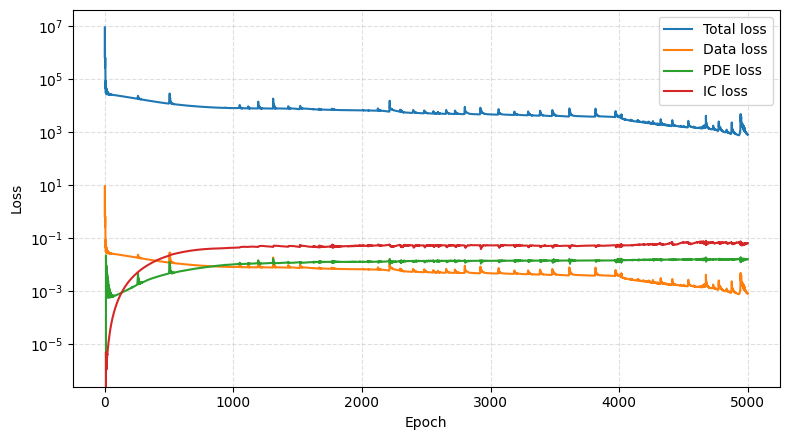

In [8]:
# ======================================================================
# 0) Imports ------------------------------------------------------------
# ======================================================================
import math
import numpy as np                     # ← 누락되어 있던 numpy import 추가
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt        # ← 시각화를 위한 import

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float32)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
np.random.seed(42)

# ======================================================================
# 2) 상수 & 정규화 계수 -------------------------------------------------
# ======================================================================
T_norm = torch.linspace(0, 1, 300)            # 정규화 시간축 (길이 L=300)
dt      = (T_norm[1]-T_norm[0]).item()        # 1/299

R_Norm, L_Norm, C_Norm = 1e-14, 1e-11, 1e16
Ud_Norm, Q_Norm        = 1e-8,  1e-2          # q·Ud 무차원화

# ======================================================================
# 4) DeepONet -----------------------------------------------------------
#   - Branch-1 입력 차원: 5 (p 제거: [mu, sigma, rho, c, t])
# ======================================================================
def mlp(d_in, hid, d_out):
    layers, h_prev = [], d_in
    for h in hid:
        layers += [nn.Linear(h_prev, h), nn.GELU()]
        h_prev = h
    layers.append(nn.Linear(h_prev, d_out))
    return nn.Sequential(*layers)

class DeepONet(nn.Module):
    def __init__(self, seq_len=300, latent=256,
                 branch1_hid=[256, 256, 256, 256, 256, 256],      # 5 layers
                 branch2_hid=[256, 256, 256, 256, 256,256],      # 5 layers
                 trunk_hid=[256, 256, 256, 256, 256, 256],        # 5 layers
                 gate_hid=[256]*7):                         # 10 layers
        super().__init__()

        self.branch1 = mlp(5,        branch1_hid, latent)   # (Input=5)
        self.branch2 = mlp(seq_len,  branch2_hid, latent)   # (Input=300)
        self.trunk   = mlp(1,        trunk_hid,   latent)   # (Input=1)
        self.gate    = mlp(1,        gate_hid,    latent)   # (Input=1)
        self.bias    = nn.Parameter(torch.zeros(1, seq_len))

        # Time grid normalization
        t = torch.linspace(1, seq_len, seq_len).view(-1, 1) / seq_len
        self.register_buffer("t_grid", t)

    def forward(self, x1, x2):
        # x1: (B,5), x2: (B,300)
        B = self.branch1(x1) + self.branch2(x2)     # (B, latent)
        T = self.trunk(self.t_grid)                 # (L, latent)
        G = torch.sigmoid(self.gate(self.t_grid))   # (L, latent)
        return B @ (T * G).T + self.bias            # (B, L=300)

# Device 설정 및 모델 초기화
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = DeepONet().to(DEVICE)

# ======================================================================
# 5) Physics helper -----------------------------------------------------
#   - 스칼라 인덱싱: mu(0), sigma(1), rho(2), c(3), t(4)
# ======================================================================
def physics_terms(q, scal, v):
    # scal: (B,5) = [mu, sigma, rho, c, t]
    mu     = scal[:, 0:1]
    sigma  = scal[:, 1:2]  # 현재 식에서는 미사용(확장 시 활용 가능)
    rho    = scal[:, 2:3]
    c      = scal[:, 3:4]
    t_pin  = scal[:, 4:5]  # 현재 항에서는 직접 사용하지 않음

    # 기하/상수
    l1,l2,l3,l4 = 0.012, 0.0084, 0.00542303, 0.00057697
    L_tot       = l1 + l2 + l3 + l4
    r_ch        = 235e-6
    alpha_pzt   = 0.29e-9

    # 점성 경계층 두께 근사 및 무차원화 계수
    T_visc  = 2 * L_tot / c
    delta_v = torch.sqrt(mu * T_visc / math.pi / rho)

    R_nd = 2 * mu * L_tot / (math.pi * delta_v * r_ch**3) * R_Norm
    L_nd = rho * L_tot / (math.pi * r_ch**2)              * L_Norm
    C_nd = math.pi * r_ch**2 * L_tot / (c**2 * rho)       * C_Norm

    # 중앙차분 (길이 L → 내부  L-2)
    dq_nd  = (q[:, 2:] - q[:, :-2]) / (2 * dt) * Q_Norm
    d2q_nd = (q[:, :-2] - 2*q[:, 1:-1] + q[:, 2:]) / (dt**2) * Q_Norm
    q_mid  =  q[:, 1:-1] * Q_Norm

    dVdt   = (v[:, 2:] - v[:, :-2]) / (2 * dt)
    Ud1    = (rho * c**2 * alpha_pzt * 2 / r_ch) * dVdt
    Ud_nd  = Ud1 * Ud_Norm

    return R_nd, L_nd, C_nd, Ud_nd, dq_nd, d2q_nd, q_mid

# ----------------------------------------------------------------------
# Losses
# ----------------------------------------------------------------------
def data_loss(q_pred, q_true):
    return torch.mean((q_pred - q_true).pow(2))

def pde_loss(q_pred, scal, v):
    R_nd, L_nd, C_nd, Ud_nd, dq_nd, d2q_nd, q_mid = physics_terms(q_pred, scal, v)
    resid = L_nd * d2q_nd + R_nd * dq_nd + q_mid / C_nd - Ud_nd
    return torch.mean(resid.pow(2))

def ic_loss(q_pred, scal, v):
    L_nd, *_ = physics_terms(q_pred, scal, v)
    q0_nd  = q_pred[:, 0] * Q_Norm
    dq0_nd = (q_pred[:, 1] - q_pred[:, 0]) / dt * Q_Norm
    v0_nd  = v[:, 0] * Ud_Norm
    return torch.mean(q0_nd.pow(2) + (L_nd.squeeze(-1) * dq0_nd - v0_nd).pow(2))

# ======================================================================
# 6) Training loop (+ 시각화 기록) --------------------------------------
# ======================================================================
EPOCHS, PHYS_ON     = 5000, 10
DATA_W, PDE_W, IC_W = 1e6, 1e-2, 1e-2
loader   = DataLoader(dataset, batch_size=300, shuffle=True)
optim    = torch.optim.Adam(model.parameters(), lr=5e-4)

# ----- 기록용 컨테이너 -------------------------------------------------
hist = {
    "epoch": [],
    "total": [],
    "data":  [],
    "pde":   [],
    "ic":    []
}

for ep in range(1, EPOCHS + 1):
    model.train()
    sum_tot = 0.0
    sum_d   = 0.0
    sum_p   = 0.0
    sum_i   = 0.0

    for x1, x2, y in loader:
        x1, x2, y = x1.to(DEVICE), x2.to(DEVICE), y.to(DEVICE)  # x1:(B,5), x2:(B,300)
        q_pred    = model(x1, x2)                                # (B,300)

        l_d = data_loss(q_pred, y)
        if ep >= PHYS_ON:
            l_p = pde_loss(q_pred, x1, x2)
            l_i = ic_loss(q_pred, x1, x2)
        else:
            l_p = torch.tensor(0.0, device=DEVICE)
            l_i = torch.tensor(0.0, device=DEVICE)

        loss = DATA_W*l_d + PDE_W*l_p + IC_W*l_i

        optim.zero_grad()
        loss.backward()
        optim.step()

        # 배치 합계(에폭 평균 계산용)
        sum_tot += float(loss.detach())
        sum_d   += float(l_d.detach())
        sum_p   += float(l_p.detach())
        sum_i   += float(l_i.detach())

    # 에폭 평균 기록
    n_batch = len(loader)
    mean_tot = sum_tot / n_batch
    mean_d   = sum_d   / n_batch
    mean_p   = sum_p   / n_batch
    mean_i   = sum_i   / n_batch

    hist["epoch"].append(ep)
    hist["total"].append(mean_tot)
    hist["data"].append(mean_d)
    hist["pde"].append(mean_p)
    hist["ic"].append(mean_i)

    if ep == 1 or ep % 200 == 0:
        print(f"[{ep:4d}] mean loss {mean_tot:.3e} | data {mean_d:.3e} | pde {mean_p:.3e} | ic {mean_i:.3e}")

# ======================================================================
# 7) 시각화 -------------------------------------------------------------
# ======================================================================
plt.figure(figsize=(8,4.5))
plt.plot(hist["epoch"], hist["total"], label="Total loss")
plt.plot(hist["epoch"], hist["data"],  label="Data loss")
plt.plot(hist["epoch"], hist["pde"],   label="PDE loss")
plt.plot(hist["epoch"], hist["ic"],    label="IC loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")               # 손실이 급격히 줄 때 가독성 향상
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()


---

[Metrics @ v24]  MSE=3.006713e-04  MAE=1.195722e-02  Pearson r=0.9926


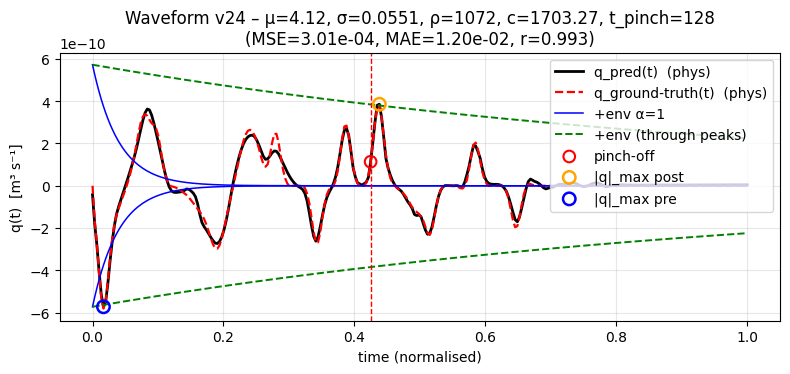

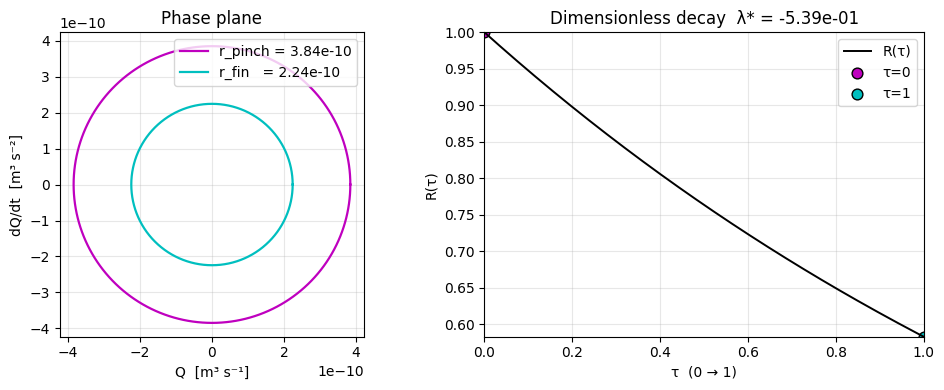

In [9]:
# ======================================================================
# 0) Imports & DEVICE ---------------------------------------------------
# ======================================================================
import math, os, numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ======================================================================
# 7) expo_decay (시각화용)  ← 스칼라 5개 체계로 수정 -------------------
# ======================================================================
def expo_decay(q_pred, scal_row, t_pinch_idx):
    """
    q_pred      : (300,) numpy  – 모델 예측(무차원 q)
    scal_row    : (5,)          – (μ, σ, ρ, c, t_pinch)
    t_pinch_idx : int           – 0-based pinch index (t_pinch-1)
    반환: dict (모든 좌표·envelope)
    """
    t_norm = np.linspace(0, 1, 300)
    q_arr  = q_pred.copy()

    idx_pin   = t_pinch_idx
    t_star    = t_norm[idx_pin]
    q_star    = q_arr[idx_pin]

    # post-pinch
    idx_amp = t_amp = q_amp = None
    if idx_pin+1 < len(q_arr):
        post_q    = q_arr[idx_pin+1:]
        idx_rel   = np.argmax(np.abs(post_q))
        idx_amp   = idx_pin+1+idx_rel
        t_amp, q_amp = t_norm[idx_amp], q_arr[idx_amp]

    # pre-pinch
    idx_pre = t_pre = q_pre = None
    if idx_pin > 0:
        pre_q   = q_arr[:idx_pin]
        idx_pre = np.argmax(np.abs(pre_q))
        t_pre, q_pre = t_norm[idx_pre], q_arr[idx_pre]

    # ------------------------------  물성 파생 파라미터 (예: 감쇠)  ------------------------------
    mu, sigma, rho, c, t_pinch = scal_row
    l1,l2,l3,l4 = 0.012, 0.0084, 0.00542303, 0.00057697
    L_tot, r_ch = l1+l2+l3+l4, 235e-6
    T_visc = 2*L_tot / c
    delta_v= math.sqrt(mu*T_visc/math.pi/rho)
    R = 2*mu*L_tot/(math.pi*delta_v*r_ch**3)
    L = rho*L_tot/(math.pi*r_ch**2)
    C = math.pi*r_ch**2*L_tot/(c**2*rho)

    zeta    = R / (2*math.sqrt(L/C))
    omega_n = 1.0 / math.sqrt(L*C)

    # ------------------------------  envelope & 물리 스케일 변환  ------------------------------
    scale = 1e-9
    q_phys = q_arr*scale
    t_s    = t_norm*300e-6
    A_env  = np.max(np.abs(q_phys))
    env_a1 =  A_env*np.exp(-1.0*zeta*omega_n*t_s)

    env_cust = None
    if (idx_pre is not None) and (idx_amp is not None):
        t_pre_s = t_pre*300e-6
        t_amp_s = t_amp*300e-6
        denom = (zeta*omega_n*(t_amp_s - t_pre_s))
        if denom != 0 and (abs(q_pre) > 0) and (abs(q_amp) > 0):
            alpha_c = (np.log(abs(q_pre*scale)/abs(q_amp*scale)) / denom)
            env_cust = A_env*np.exp(-alpha_c*zeta*omega_n*t_s)

    return dict(t=t_norm, q=q_phys,
                idx_pin=idx_pin, t_star=t_star, q_star=q_star*scale,
                idx_amp=idx_amp, t_amp=t_amp, q_amp=q_amp*scale if q_amp is not None else None,
                idx_pre=idx_pre, t_pre=t_pre, q_pre=q_pre*scale if q_pre is not None else None,
                env_a1=env_a1, env_cust=env_cust)

def decay_rate(env: dict):
    """
    env : expo_decay()가 돌려준 dict
    반환 : None  (env_cust가 없으면)  또는
           {lam_star, r_pinch, r_fin, tau, R_tau}
    """
    env_c = env["env_cust"]
    if env_c is None:
        return None

    idx_p   = env["idx_pin"]
    r_pinch = abs(env_c[idx_p])             # |q| at pinch (envelope 값)
    r_fin   = abs(env_c[-1])                # |q| at t_norm = 1

    t       = env["t"]
    tau     = (t - t[idx_p]) / (t[-1] - t[idx_p])     # 0 → 1
    R_tau   = env_c / r_pinch
    mask    = (tau >= 0) & (tau <= 1)
    tau_seg = tau[mask]
    R_seg   = R_tau[mask]

    lam_star = math.log(r_fin / r_pinch) if r_pinch > 0 and r_fin > 0 else float('nan')

    return dict(lam_star=lam_star,
                r_pinch=r_pinch, r_fin=r_fin,
                tau=tau_seg, R_tau=R_seg)

# ======================================================================
# 8) Exponential decay & visualization  +  GT(원 데이터) 비교 ----------
# ======================================================================
# 전처리 블록에서 생성한 사전들을 그대로 사용:
#   - WAVE_DB : waveform_id → v1..v300 (np.float32)
#   - GT_DB   : waveform_id → q1..q300 (np.float32)

# 예측 입력 구성 (★ x1/x2 분리 인덱스 5로 수정)
single = (4.12, 0.0551, 1072, 1703.27, 128, "v24")   # 5 scalars + id
mu, sigma, rho, c_val, t_pinch, wid = single

v_wave = WAVE_DB[wid]  # (300,)

x_np  = np.concatenate([[mu, sigma, rho, c_val, t_pinch], v_wave]).astype(np.float32)
x1_np, x2_np = x_np[:5], x_np[5:]

model.eval()
with torch.no_grad():
    q_out = model(torch.from_numpy(x1_np).unsqueeze(0).to(DEVICE),
                  torch.from_numpy(x2_np).unsqueeze(0).to(DEVICE)
                 ).squeeze(0).cpu().numpy()   # (300,)  — 예측(무차원)

# 정답(무차원) 불러오기
if wid not in GT_DB:
    raise KeyError(f"waveform_id {wid} not found in GT_DB.")
q_gt = GT_DB[wid].astype(np.float32)          # (300,) — 원래 Y (무차원)

# expo_decay는 내부에서 예측을 물리단위(×1e-9)로 변환하여 반환
ed = expo_decay(q_out, np.array([mu, sigma, rho, c_val, t_pinch], dtype=np.float64), t_pinch-1)

# 원 데이터도 같은 스케일(물리 단위)로 일관 변환
scale = 1e-9
q_gt_phys = q_gt * scale

# ------------------  정량 지표 ------------------
mse = float(np.mean((q_out - q_gt)**2))
mae = float(np.mean(np.abs(q_out - q_gt)))
# Pearson r: 분산 0 방지
if (np.std(q_out) > 0) and (np.std(q_gt) > 0):
    r = float(np.corrcoef(q_out, q_gt)[0,1])
else:
    r = np.nan

print(f"[Metrics @ {wid}]  MSE={mse:.6e}  MAE={mae:.6e}  Pearson r={r:.4f}")

# ------------------  시각화 (예측 vs 원데이터) ------------------
plt.figure(figsize=(8,4))
plt.plot(ed['t'], ed['q'], 'k', lw=2, label='q_pred(t)  (phys)')
plt.plot(ed['t'], q_gt_phys, 'r--', lw=1.6, label='q_ground-truth(t)  (phys)')
plt.plot(ed['t'],  ed['env_a1'], 'b-', lw=1.1, label='+env α=1')
plt.plot(ed['t'], -ed['env_a1'], 'b-', lw=1.1)

if ed['env_cust'] is not None:
    plt.plot(ed['t'],  ed['env_cust'], 'g--', lw=1.4, label='+env (through peaks)')
    plt.plot(ed['t'], -ed['env_cust'], 'g--', lw=1.4)

plt.axvline(ed['t_star'], color='red', ls='--', lw=1)
plt.scatter(ed['t_star'], ed['q_star'], s=70, facecolors='none',
            edgecolors='red', linewidths=1.5, zorder=3, label='pinch-off')

if ed['idx_amp'] is not None:
    plt.scatter(ed['t_amp'], ed['q_amp'], s=80, facecolors='none',
                edgecolors='orange', linewidths=1.8, zorder=3,
                label='|q|_max post')
if ed['idx_pre'] is not None:
    plt.scatter(ed['t_pre'], ed['q_pre'], s=80, facecolors='none',
                edgecolors='blue', linewidths=1.8, zorder=3,
                label='|q|_max pre')

plt.xlabel('time (normalised)')
plt.ylabel('q(t)  [m³ s⁻¹]')
plt.title(f"Waveform {wid} – μ={mu}, σ={sigma}, ρ={rho}, c={c_val}, t_pinch={t_pinch}\n"
          f"(MSE={mse:.2e}, MAE={mae:.2e}, r={r:.3f})")
plt.grid(alpha=.3); plt.legend(loc='upper right'); plt.tight_layout(); plt.show()

# ======================================================================
# 9) Decay-rate ‧ phase-plane 시각화 -----------------------------------
# ======================================================================
dr = decay_rate(ed)
if dr is None:
    print("[skip] env_cust 없음 → λ* subplot 생략")
else:
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4))

    # (좌) phase plane : r_pinch, r_fin 원
    theta = np.linspace(0, 2*np.pi, 361)
    axL.plot(dr['r_pinch']*np.cos(theta), dr['r_pinch']*np.sin(theta),
             'm-', lw=1.6, label=f"r_pinch = {dr['r_pinch']:.2e}")
    axL.plot(dr['r_fin']  *np.cos(theta), dr['r_fin']  *np.sin(theta),
             'c-', lw=1.6, label=f"r_fin   = {dr['r_fin']:.2e}")
    axL.set_aspect("equal");   axL.grid(alpha=.3)
    axL.set_xlabel("Q  [m³ s⁻¹]")
    axL.set_ylabel("dQ/dt  [m³ s⁻²]")
    axL.set_title("Phase plane");   axL.legend(loc="upper right")

    # (우) R(τ) 곡선
    axR.plot(dr['tau'], dr['R_tau'], 'k-', lw=1.4, label="R(τ)")
    axR.scatter(0, 1,                          c='m', edgecolors='k', s=60, label="τ=0")
    axR.scatter(1, dr['r_fin']/dr['r_pinch'],  c='c', edgecolors='k', s=60, label="τ=1")
    axR.set_xlim(0, 1)
    axR.set_ylim(min(dr['R_tau'].min(), 1.0), max(dr['R_tau'].max(), 1.0))
    axR.set_xlabel("τ  (0 → 1)")
    axR.set_ylabel("R(τ)")
    axR.set_title(fr"Dimensionless decay  λ* = {dr['lam_star']:.2e}")
    axR.grid(alpha=.3);   axR.legend(loc="upper right")

    plt.tight_layout();   plt.show()


---
---

Validation

In the actual system, the driving voltage waveform applied by the actuator, $U_A(t)$, is treated as the external input. To reproduce the system behavior governed by the governing equations, the volumetric flow rate $q(t)$ is modeled as the dynamic response, which can be written as:

$$
L\ddot{q} + R\dot{q} + \frac{1}{C}q = F\frac{dU_A}{dt}
\tag{1}
$$


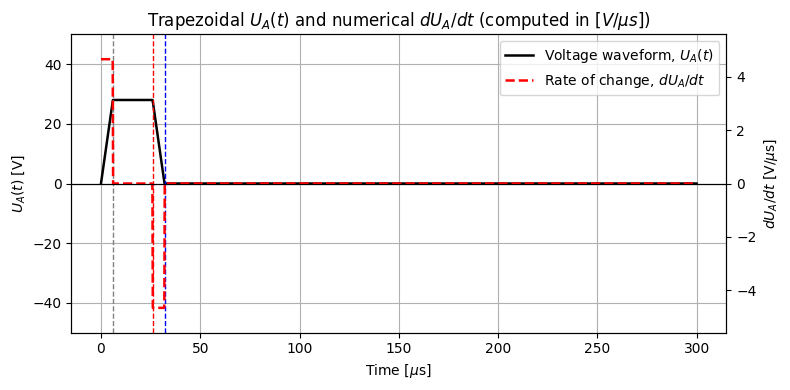

In [21]:
import torch
import matplotlib.pyplot as plt

# --------------------------
# 1. Pulse params (physical unit)
# --------------------------
t1, t2, t3, V_max = 6e-6, 26e-6, 32e-6, 28  # [s, V]
T_end = 300e-6                               # 300 µs [s]
N = 3000                                     # timestep count

# --------------------------
# 2. Voltage waveform U_A(t): trapezoidal (physical time input)
# --------------------------
def U_A_trapezoid(t: torch.Tensor) -> torch.Tensor:
    """
    t: physical time [s]
    returns U_A(t) [V]
    """
    up   = (t <= t1)
    hold = (t > t1) & (t <= t2)
    down = (t > t2) & (t <= t3)

    u_up = V_max * (t / t1)
    u_hold = V_max * torch.ones_like(t)
    u_down = V_max * (1.0 - (t - t2) / (t3 - t2))

    u = torch.zeros_like(t)
    u = torch.where(up, u_up, u)
    u = torch.where(hold, u_hold, u)
    u = torch.where(down, u_down, u)
    return u

# --------------------------
# 3. Numerical derivative dU/dt in [V/µs] using finite difference
# --------------------------
def numerical_dU_dt_V_per_us(U: torch.Tensor, t_us: torch.Tensor) -> torch.Tensor:
    """
    U: [V], t_us: [µs]
    returns dU/dt in [V/µs]
    """
    dUdt = torch.zeros_like(U)

    # center difference for interior points
    dUdt[1:-1] = (U[2:] - U[:-2]) / (t_us[2:] - t_us[:-2])

    # forward/backward difference for endpoints
    dUdt[0] = (U[1] - U[0]) / (t_us[1] - t_us[0])
    dUdt[-1] = (U[-1] - U[-2]) / (t_us[-1] - t_us[-2])

    return dUdt

# --------------------------
# 4. Time axis (0 ~ 300 µs) and compute
# --------------------------
t_s = torch.linspace(0.0, T_end, N)   # physical time [s]
t_us_torch = t_s * 1e6               # [µs] as torch
t_us = t_us_torch.detach().numpy()   # [µs] for plotting

U_torch = U_A_trapezoid(t_s)         # [V]
U_vals = U_torch.detach().numpy()

dUdt_torch = numerical_dU_dt_V_per_us(U_torch, t_us_torch)  # [V/µs]
dUdt_vals = dUdt_torch.detach().numpy()

# --------------------------
# 5. Plot with dual y-axes
# --------------------------
fig, ax1 = plt.subplots(figsize=(8, 4))

# Left axis: Voltage waveform (black solid)
line1, = ax1.plot(
    t_us, U_vals,
    color='black', linestyle='-', linewidth=1.8,
    label=r'Voltage waveform, $U_A(t)$'
)
ax1.set_xlabel(r"Time [$\mu$s]")
ax1.set_ylabel(r"$U_A(t)$ [V]")
ax1.grid(True)

# y1 scale: 50 ~ 0 ~ -50
ax1.set_ylim(-50, 50)

# Right axis: Rate of change (red dashed) in [V/µs]
ax2 = ax1.twinx()
line2, = ax2.plot(
    t_us, dUdt_vals,
    color='red', linestyle='--', linewidth=1.8,
    label=r'Rate of change, $dU_A/dt$'
)
ax2.set_ylabel(r"$dU_A/dt$ [V/$\mu$s]")

# y2 scale: auto-symmetric around 0 (recommended for correct visibility)
max_abs = float(torch.max(torch.abs(dUdt_torch)).item())
if max_abs == 0.0:
    ax2.set_ylim(-1.0, 1.0)
else:
    ax2.set_ylim(-1.2 * max_abs, 1.2 * max_abs)

# Mark t1, t2, t3
ax1.axvline(t1 * 1e6, color='gray', linestyle='--', linewidth=1.0)
ax1.axvline(t2 * 1e6, color='red', linestyle='--', linewidth=1.0)
ax1.axvline(t3 * 1e6, color='blue', linestyle='--', linewidth=1.0)

# zero lines
ax1.axhline(0.0, color='black', linewidth=0.8)
ax2.axhline(0.0, color='black', linewidth=0.8)

# Legend fixed at upper right
ax1.legend([line1, line2],
           [line1.get_label(), line2.get_label()],
           loc="upper right")

plt.title(r"Trapezoidal $U_A(t)$ and numerical $dU_A/dt$ (computed in $[V/\mu s]$)")
plt.tight_layout()
plt.show()


### Appendix B.X Lumped-Element Parameters (Dimensional Form)

In the present formulation, only the actuator-driven voltage waveform $U_A(t)$ is treated as the external input. The volumetric flowrate $q(t)$ is modeled by the following lumped-parameter ODE:
$$
L\,\ddot{q}(t) + R\,\dot{q}(t) + \frac{1}{C}\,q(t) = F\,\frac{dU_A(t)}{dt}.
\tag{B.1}
$$

#### (1) Characteristic time scale and viscous penetration depth
The total channel length is
$$
l_{\mathrm{tot}} = l_1 + l_2 + l_3 + l_4.
\tag{B.2}
$$
The characteristic time scale is defined as
$$
T_{\mathrm{visc}} = \frac{2\,l_{\mathrm{tot}}}{c}.
\tag{B.3}
$$
The viscous penetration depth is evaluated by
$$
\delta_v = \sqrt{\frac{\mu\,T_{\mathrm{visc}}}{\pi\,\rho}}.
\tag{B.4}
$$

#### (2) Compliance (capacitance) terms
The channel compliance is
$$
C_{\mathrm{channel}} = \frac{\pi r^2\,l_{\mathrm{tot}}}{\rho\,c^2}.
\tag{B.5}
$$
The nozzle compliance is modeled as
$$
C_{\mathrm{nozzle}} = \frac{\pi r_{\mathrm{nozz}}^4}{3\sigma}.
\tag{B.6}
$$
Thus, the total compliance is
$$
C_{\mathrm{total}} = C_{\mathrm{channel}} + C_{\mathrm{nozzle}}.
\tag{B.7}
$$

#### (3) Inductance and resistance
The hydraulic inductance is
$$
L_{\mathrm{total}} = \frac{\rho\,l_{\mathrm{tot}}}{\pi r^2}.
\tag{B.8}
$$
The viscous resistance using $\delta_v$ is
$$
R_{\mathrm{total}} = \frac{2\mu\,l_{\mathrm{tot}}}{\pi\,\delta_v\,r^3}.
\tag{B.9}
$$

#### (4) Electromechanical forcing coefficient
The forcing coefficient is given by
$$
F = \frac{2\rho c^2 \alpha V_t}{r}.
\tag{B.10}
$$

#### (5) Time scaling using microseconds (for numerical implementation)
Let $\tau = t/(1\,\mu s)$. Then
$$
\frac{d}{dt} = 10^6\frac{d}{d\tau}, \qquad
\frac{d^2}{dt^2} = 10^{12}\frac{d^2}{d\tau^2}.
\tag{B.11}
$$
Accordingly, Eq. (B.1) can be rewritten as
$$
(10^{12}L)\,\frac{d^2 q}{d\tau^2}
+
(10^{6}R)\,\frac{dq}{d\tau}
+
\frac{1}{C}\,q
=
(10^{6}F)\,\frac{dU_A}{d\tau}.
\tag{B.12}
$$
Note that $C$ (and thus $1/C$) remains unchanged under the time rescaling because it is not associated with a time derivative term.


In [25]:
import torch
import math

torch.set_default_dtype(torch.float64)

# ----------------------------
# Physical parameters (SI)
# ----------------------------
sigma = 0.047        # [N/m]
mu    = 0.0157       # [Pa·s]
rho   = 1111.4       # [kg/m^3]
alpha = 0.29e-9      # [C/N]
c     = 1600         # [m/s]

r      = 235e-6      # [m]
r_nozz = 25e-6       # [m]
l1, l2, l3, l4 = 0.012, 0.0084, 0.00542303, 0.00057697  # [m]

Vt = 1.0  # [V]

# ---------------------------------------------
# 1) Time/length scales (SI)
# ---------------------------------------------
l_tot = l1 + l2 + l3 + l4                      # [m]
T_visc = 2.0 * l_tot / c                       # [s]
delta_v = torch.sqrt(mu * T_visc / (torch.tensor(math.pi) * rho))  # [m]

print("===== Time/length scales (SI) =====")
print(f"l_tot       = {l_tot:.6e}  [m]  = {l_tot*1e6:.6f}  [µm]")
print(f"T_visc      = {T_visc:.6e}  [s]  = {T_visc*1e6:.6f}  [µs]")
print(f"delta_v     = {delta_v.item():.6e}  [m]  = {delta_v.item()*1e6:.6f}  [µm]")

# ---------------------------------------------
# 2) Compliance (SI)
# ---------------------------------------------
C_channel = math.pi * (r ** 2) * l_tot / (rho * c ** 2)            # [m^3/Pa]
C_nozzle  = math.pi * (r_nozz ** 4) / (3.0 * sigma)                # [m^3/Pa]
C_total   = C_channel + C_nozzle                                   # [m^3/Pa]
invC_total = 1.0 / C_total                                         # [Pa/m^3]

print("\n===== Compliance (SI) =====")
print(f"C_channel   = {C_channel:.6e}  [m^3/Pa]")
print(f"C_nozzle    = {C_nozzle:.6e}  [m^3/Pa]")
print(f"C_total     = {C_total:.6e}  [m^3/Pa]")
print(f"1/C_total   = {invC_total:.6e}  [Pa/m^3]")

# ---------------------------------------------
# 3) Lumped parameters (SI): R, L, C, F
# ---------------------------------------------
L_total = rho * l_tot / (math.pi * r ** 2)                          # [kg/m^4]
R_total = 2.0 * mu * l_tot / (math.pi * delta_v.item() * r ** 3)    # [Pa·s/m^3]
F_total = (2.0 * rho * (c ** 2) * alpha * Vt) / r                   # [Pa]

print("\n===== Lumped parameters (SI) =====")
print(f"R_total     = {R_total:.6e}  [Pa·s/m^3]")
print(f"L_total     = {L_total:.6e}  [kg/m^4]")
print(f"C_total     = {C_total:.6e}  [m^3/Pa]")
print(f"F           = {F_total:.6e}  [Pa]")

# ==========================================================
# AFTER THIS POINT: requested three conversion print blocks
# ==========================================================

# ----------------------------
# Unit conversion factors
# ----------------------------
s_to_us = 1e6               # 1 s = 1e6 us
m3_to_um3 = 1e18            # 1 m^3 = 1e18 um^3
inv_m3_to_inv_um3 = 1e-18   # 1/m^3 = 1e-18 /um^3
m4_to_um4 = 1e24            # 1 m^4 = 1e24 um^4
inv_m4_to_inv_um4 = 1e-24   # 1/m^4 = 1e-24 /um^4

# ---------------------------------------------
# A) s > us, m > m
# ---------------------------------------------
# R: [Pa·s/m^3] -> [Pa·us/m^3] multiply by 1e6
# L: [kg/m^4]   -> [kg·us^2/m^4] multiply by 1e12
# C: [m^3/Pa]   -> unchanged
# F: [Pa]       -> [Pa·us] multiply by 1e6 (as coefficient with dU/dtau)
R_us_m = R_total * s_to_us
L_us_m = L_total * (s_to_us ** 2)
C_us_m = C_total
F_us_m = F_total * s_to_us

print("\n===== Converted: s > us, m > m =====")
print(f"R           = {R_us_m:.6e}  [Pa·us/m^3]")
print(f"L           = {L_us_m:.6e}  [kg·us^2/m^4]")
print(f"C           = {C_us_m:.6e}  [m^3/Pa]")
print(f"F           = {F_us_m:.6e}  [Pa·us]")

# ---------------------------------------------
# B) s > s, m > um
# ---------------------------------------------
# R: [Pa·s/m^3] -> [Pa·s/um^3] multiply by 1e-18
# L: [kg/m^4]   -> [kg/um^4]   multiply by 1e-24
# C: [m^3/Pa]   -> [um^3/Pa]   multiply by 1e18
# F: [Pa]       -> unchanged
R_s_um = R_total * inv_m3_to_inv_um3
L_s_um = L_total * inv_m4_to_inv_um4
C_s_um = C_total * m3_to_um3
F_s_um = F_total

print("\n===== Converted: s > s, m > um =====")
print(f"R           = {R_s_um:.6e}  [Pa·s/um^3]")
print(f"L           = {L_s_um:.6e}  [kg/um^4]")
print(f"C           = {C_s_um:.6e}  [um^3/Pa]")
print(f"F           = {F_s_um:.6e}  [Pa]")

# ---------------------------------------------
# C) s > us, m > um
# ---------------------------------------------
# Combine A and B:
# R: [Pa·s/m^3] -> [Pa·us/um^3] multiply by (1e6)*(1e-18)=1e-12
# L: [kg/m^4]   -> [kg·us^2/um^4] multiply by (1e12)*(1e-24)=1e-12
# C: [m^3/Pa]   -> [um^3/Pa] multiply by 1e18 (time has no effect)
# F: [Pa]       -> [Pa·us] multiply by 1e6 (length has no effect)
R_us_um = R_total * (s_to_us * inv_m3_to_inv_um3)
L_us_um = L_total * ((s_to_us ** 2) * inv_m4_to_inv_um4)
C_us_um = C_total * m3_to_um3
F_us_um = F_total * s_to_us

print("\n===== Converted: s > us, m > um =====")
print(f"R           = {R_us_um:.6e}  [Pa·us/um^3]")
print(f"L           = {L_us_um:.6e}  [kg·us^2/um^4]")
print(f"C           = {C_us_um:.6e}  [um^3/Pa]")
print(f"F           = {F_us_um:.6e}  [Pa·us]")


===== Time/length scales (SI) =====
l_tot       = 2.640000e-02  [m]  = 26400.000000  [µm]
T_visc      = 3.300000e-05  [s]  = 33.000000  [µs]
delta_v     = 1.218138e-05  [m]  = 12.181385  [µm]

===== Compliance (SI) =====
C_channel   = 1.609827e-18  [m^3/Pa]
C_nozzle    = 8.703437e-18  [m^3/Pa]
C_total     = 1.031326e-17  [m^3/Pa]
1/C_total   = 9.696251e+16  [Pa/m^3]

===== Lumped parameters (SI) =====
R_total     = 1.669104e+12  [Pa·s/m^3]
L_total     = 1.691176e+08  [kg/m^4]
C_total     = 1.031326e-17  [m^3/Pa]
F           = 7.022156e+03  [Pa]

===== Converted: s > us, m > m =====
R           = 1.669104e+18  [Pa·us/m^3]
L           = 1.691176e+20  [kg·us^2/m^4]
C           = 1.031326e-17  [m^3/Pa]
F           = 7.022156e+09  [Pa·us]

===== Converted: s > s, m > um =====
R           = 1.669104e-06  [Pa·s/um^3]
L           = 1.691176e-16  [kg/um^4]
C           = 1.031326e+01  [um^3/Pa]
F           = 7.022156e+03  [Pa]

===== Converted: s > us, m > um =====
R           = 1.669104e+00  [P

In [39]:
import torch
import math

torch.set_default_dtype(torch.float64)

# ----------------------------
# Physical parameters (SI)
# ----------------------------
sigma = 0.047        # [N/m]
mu    = 0.0157       # [Pa·s]
rho   = 1111.4       # [kg/m^3]
alpha = 0.29e-9      # [C/N]
c     = 1600         # [m/s]

r      = 235e-6      # [m]
r_nozz = 25e-6       # [m]
l1, l2, l3, l4 = 0.012, 0.0084, 0.00542303, 0.00057697  # [m]

Vt = 1.0  # [V]

# ---------------------------------------------
# 1) Time/length scales (SI)
# ---------------------------------------------
l_tot = l1 + l2 + l3 + l4                      # [m]
T_visc = 2.0 * l_tot / c                       # [s]
delta_v = torch.sqrt(mu * T_visc / (torch.tensor(math.pi) * rho))  # [m]

print("===== Time/length scales (SI) =====")
print(f"l_tot       = {l_tot:.6e}  [m]  = {l_tot*1e6:.6f}  [µm]")
print(f"T_visc      = {T_visc:.6e}  [s]  = {T_visc*1e6:.6f}  [µs]")
print(f"delta_v     = {delta_v.item():.6e}  [m]  = {delta_v.item()*1e6:.6f}  [µm]")

# ---------------------------------------------
# 2) Compliance (SI)
# ---------------------------------------------
C_channel = math.pi * (r ** 2) * l_tot / (rho * c ** 2)            # [m^3/Pa]
C_nozzle  = math.pi * (r_nozz ** 4) / (3.0 * sigma)                # [m^3/Pa]
C_total   = C_channel + C_nozzle                                   # [m^3/Pa]
invC_total = 1.0 / C_total                                         # [Pa/m^3]

print("\n===== Compliance (SI) =====")
print(f"C_channel   = {C_channel:.6e}  [m^3/Pa]")
print(f"C_nozzle    = {C_nozzle:.6e}  [m^3/Pa]")
print(f"C_total     = {C_total:.6e}  [m^3/Pa]")
print(f"1/C_total   = {invC_total:.6e}  [Pa/m^3]")

# ---------------------------------------------
# 3) Lumped parameters (SI): R, L, C, F
# ---------------------------------------------
L_total = rho * l_tot / (math.pi * r ** 2)                          # [kg/m^4]
R_total = 2.0 * mu * l_tot / (math.pi * delta_v.item() * r ** 3)    # [Pa·s/m^3]
F_total = (2.0 * rho * (c ** 2) * alpha * Vt) / r                   # [Pa]

print("\n===== Lumped parameters (SI) =====")
print(f"R_total     = {R_total:.6e}  [Pa·s/m^3]")
print(f"L_total     = {L_total:.6e}  [kg/m^4]")
print(f"C_total     = {C_total:.6e}  [m^3/Pa]")
print(f"F_total     = {F_total:.6e}  [Pa]")

# ==========================================================
# AFTER THIS POINT: requested three conversion print blocks
# ==========================================================

# ----------------------------
# Unit conversion factors
# ----------------------------
s_to_us = 1e6               # 1 s = 1e6 us
m3_to_um3 = 1e18            # 1 m^3 = 1e18 um^3
inv_m3_to_inv_um3 = 1e-18   # 1/m^3 = 1e-18 /um^3
inv_m4_to_inv_um4 = 1e-24   # 1/m^4 = 1e-24 /um^4

# ---------------------------------------------
# A) s > us, m > m
# ---------------------------------------------
R_us_m = R_total * s_to_us
L_us_m = L_total * (s_to_us ** 2)
C_us_m = C_total
F_us_m = F_total * s_to_us

print("\n===== Converted: s > us, m > m =====")
print(f"R           = {R_us_m:.6e}  [Pa·us/m^3]")
print(f"L           = {L_us_m:.6e}  [kg·us^2/m^4]")
print(f"C           = {C_us_m:.6e}  [m^3/Pa]")
print(f"F           = {F_us_m:.6e}  [Pa·us]")

# ---------------------------------------------
# B) s > s, m > um
# ---------------------------------------------
R_s_um = R_total * inv_m3_to_inv_um3
L_s_um = L_total * inv_m4_to_inv_um4
C_s_um = C_total * m3_to_um3
F_s_um = F_total

print("\n===== Converted: s > s, m > um =====")
print(f"R           = {R_s_um:.6e}  [Pa·s/um^3]")
print(f"L           = {L_s_um:.6e}  [kg/um^4]")
print(f"C           = {C_s_um:.6e}  [um^3/Pa]")
print(f"F           = {F_s_um:.6e}  [Pa]")

# ---------------------------------------------
# C) s > us, m > um
# ---------------------------------------------
R_us_um = R_total * (s_to_us * inv_m3_to_inv_um3)
L_us_um = L_total * ((s_to_us ** 2) * inv_m4_to_inv_um4)
C_us_um = C_total * m3_to_um3
F_us_um = F_total * s_to_us

print("\n===== Converted: s > us, m > um =====")
print(f"R           = {R_us_um:.6e}  [Pa·us/um^3]")
print(f"L           = {L_us_um:.6e}  [kg·us^2/um^4]")
print(f"C           = {C_us_um:.6e}  [um^3/Pa]")
print(f"F           = {F_us_um:.6e}  [Pa·us]")

# ==========================================================
# 4) Damping condition check for:
#    - Lumped parameters (SI)
#    - Converted A (s>us, m>m)
#    - Converted B (s>s,  m>um)
#    - Converted C (s>us, m>um)
# ==========================================================
def classify_damping(R_val: float, L_val: float, C_val: float, label: str) -> None:
    """
    Classify damping based on:
      R/(2L) < 1/sqrt(LC)  (underdamped)
      R/(2L) = 1/sqrt(LC)  (critical)
      R/(2L) > 1/sqrt(LC)  (overdamped)
    This test is unit-invariant if R, L, C are converted consistently.
    """
    a = R_val / (2.0 * L_val)
    w0 = 1.0 / math.sqrt(L_val * C_val)
    disc = w0**2 - a**2

    tol = 1e-14 * max(w0**2, a**2, 1.0)

    print(f"\n===== Damping classification: {label} =====")
    print(f"R/(2L)      = {a:.12e}")
    print(f"1/sqrt(LC)  = {w0:.12e}")
    print(f"disc=w0^2-a^2 = {disc:.12e}")

    if disc > tol:
        wd = math.sqrt(disc)
        print("Condition: R/(2L) < 1/sqrt(LC)  -> UNDERDAMPED")
        print(f"omega_d = sqrt(disc) = {wd:.12e}")
    elif abs(disc) <= tol:
        print("Condition: R/(2L) = 1/sqrt(LC)  -> CRITICALLY DAMPED")
    else:
        print("Condition: R/(2L) > 1/sqrt(LC)  -> OVERDAMPED")

# (1) Lumped parameters (SI)
classify_damping(R_total, L_total, C_total, "Lumped (SI)")

# (2) Converted A: s>us, m>m
classify_damping(R_us_m, L_us_m, C_us_m, "Converted A (s>us, m>m)")

# (3) Converted B: s>s, m>um
classify_damping(R_s_um, L_s_um, C_s_um, "Converted B (s>s, m>um)")

# (4) Converted C: s>us, m>um
classify_damping(R_us_um, L_us_um, C_us_um, "Converted C (s>us, m>um)")


===== Time/length scales (SI) =====
l_tot       = 2.640000e-02  [m]  = 26400.000000  [µm]
T_visc      = 3.300000e-05  [s]  = 33.000000  [µs]
delta_v     = 1.218138e-05  [m]  = 12.181385  [µm]

===== Compliance (SI) =====
C_channel   = 1.609827e-18  [m^3/Pa]
C_nozzle    = 8.703437e-18  [m^3/Pa]
C_total     = 1.031326e-17  [m^3/Pa]
1/C_total   = 9.696251e+16  [Pa/m^3]

===== Lumped parameters (SI) =====
R_total     = 1.669104e+12  [Pa·s/m^3]
L_total     = 1.691176e+08  [kg/m^4]
C_total     = 1.031326e-17  [m^3/Pa]
F_total     = 7.022156e+03  [Pa]

===== Converted: s > us, m > m =====
R           = 1.669104e+18  [Pa·us/m^3]
L           = 1.691176e+20  [kg·us^2/m^4]
C           = 1.031326e-17  [m^3/Pa]
F           = 7.022156e+09  [Pa·us]

===== Converted: s > s, m > um =====
R           = 1.669104e-06  [Pa·s/um^3]
L           = 1.691176e-16  [kg/um^4]
C           = 1.031326e+01  [um^3/Pa]
F           = 7.022156e+03  [Pa]

===== Converted: s > us, m > um =====
R           = 1.669104e+00  [P

In [134]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import math

# --------------------------------
# 0) Basic constants and settings
# --------------------------------
torch.set_default_dtype(torch.float64)

# ----------------------------
# Normalization factors
# ----------------------------
partition1, partition2, partition3, partition4 = 1, 1, 1, 1
partition_tot = partition1 + partition2 + partition3 + partition4  # 80

sigma = 0.047
mu    = 0.0157
rho   = 1111.4
alpha = 0.29e-9
c     = 1600

r      = 235e-6
r_nozz = 25e-6
l1 = 0.012
l2 = 0.0084
l3 = 0.00542303
l4 = 0.00057697

# Characteristic time considering viscous effects
T_visc  = 2.0 * (l1 + l2 + l3 + l4) / c
delta_v = torch.sqrt(torch.tensor(mu * T_visc / math.pi / rho))

# 1) Dividing radius and length by segment
ri = torch.tensor([r + (r_nozz - r)/partition4 * i for i in range(1, partition4+1)])
ri = torch.cat([r*torch.ones(partition_tot - partition4), ri])
li = torch.cat([
    l1/partition1*torch.ones(partition1),
    l2/partition2*torch.ones(partition2),
    l3/partition3*torch.ones(partition3),
    l4/partition4*torch.ones(partition4)
])


# 2) State-space elements (cap, ind, res)
# (1) "Distributed" capacitance before overwrite
cap_dist = (torch.pi * (ri**2) * li / (c**2) / rho)  # distributed C from compressibility
C_channel = cap_dist[-1].clone()

# (2) Actual capacitance used in the model (overwrite last index with nozzle capacitance)
cap = cap_dist.clone()
cap[-1] = (torch.pi * (r_nozz**4) / 3.0 / sigma)  # C_nozzle overwrite at last index

ind = (rho * li / torch.pi / (ri**2))                  # L
res = (2.0 * mu * li / torch.pi / delta_v / (ri**3))   # R

# 4) External force f(t) = f_2nd_bot
B_q_bot = torch.cat([
    torch.ones(partition1, 1),
    torch.ones(partition2, 1),
    torch.ones(partition3 + partition4, 1)
], dim=0)

# Make dVdp a tensor so reshape works
dVdp = torch.tensor([1.0], dtype=torch.get_default_dtype())  # shape (1,)
F_mat = -(-B_q_bot * (c**2) * rho * 2.0 * alpha * dVdp.reshape(1, -1) / r)  # shape (N,1)

# --------------------------------
# Print values at the last partition location
# --------------------------------
idx_last = -1

R_last = res[idx_last]              # last R
L_last = ind[idx_last]              # last L
C_last = cap[idx_last]              # last C (after overwrite -> nozzle C)
C_nozzle = torch.tensor(math.pi, dtype=torch.get_default_dtype()) * (r_nozz**4) / (3.0 * sigma)

F_last = F_mat[idx_last, 0]         # last scalar value of F_mat

print("----- Last partition (state-space elements) -----")
print(f"R_last      = {R_last.item():.16e}")
print(f"L_last      = {L_last.item():.16e}")
print(f"C_channel      = {C_channel.item():.16e}")
print(f"C_nozzle    = {C_nozzle.item():.16e}")
print(f"F_last      = {F_last.item():.16e}")


----- Last partition (state-space elements) -----
R_last      = 3.0298164419851066e+13
L_last      = 3.2658312070714623e+08
C_channel      = 3.9817387762568791e-22
C_nozzle    = 8.7034370943866171e-18
F_last      = 7.0221562553191488e+03


In [178]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import math

# --------------------------------
# 0) Basic constants and settings
# --------------------------------
torch.set_default_dtype(torch.float64)

# ----------------------------
# Normalization factors
# ----------------------------
# li partition 제거: 길이는 4개 구간(l1~l4) 그대로 사용
# ri만 partition: 채널 전체 길이를 N개로 균등 분할하고 r -> r_nozz로 테이퍼
N_ri = 1000  # ri partition 개수 (원하면 조절)

sigma = 0.047
mu    = 0.0157
rho   = 1111.4
alpha = 0.29e-9
c     = 1600

r      = 235e-6
r_nozz = 25e-6
l1 = 0.012
l2 = 0.0084
l3 = 0.00542303
l4 = 0.00057697

# Characteristic time considering viscous effects
l_tot  = l1 + l2 + l3 + l4
T_visc  = 2.0 * l_tot / c
delta_v = torch.sqrt(torch.tensor(mu * T_visc / math.pi / rho))

# 1) Dividing radius and length by segment
#    - ri만 partition: r -> r_nozz 선형 테이퍼
#    - li는 partition하지 않음: 전체 길이를 ri 개수에 맞춰 "균등 길이"로만 대응 (합이 l_tot)
ri = torch.linspace(r, r_nozz, N_ri, dtype=torch.get_default_dtype())      # (N_ri,)
li = (l_tot / N_ri) * torch.ones(N_ri, dtype=torch.get_default_dtype())    # (N_ri,)

# 2) State-space elements (cap, ind, res)
cap_chan = (torch.pi * (ri**2) * li / (c**2) / rho)                 # channel compressibility compliance per segment
cap_nozz = (torch.pi * (r_nozz**4) / 3.0 / sigma)                   # nozzle compliance (scalar)

ind = (rho * li / torch.pi / (ri**2))                               # L per segment
res = (2.0 * mu * li / torch.pi / delta_v / (ri**3))                # R per segment

# Make dVdp a tensor so reshape works
dVdp = torch.tensor([1.0], dtype=torch.get_default_dtype())          # shape (1,)
F_mat = -((c**2) * rho * 2.0 * alpha * dVdp.reshape(1, -1) / r)      # shape (1,1) (constant in this definition)

# --------------------------------
# Print values at the last segments
# --------------------------------
idx_last = -1

R_last       = res[idx_last]                 # last segment R
L_last       = ind[idx_last]                 # last segment L
C_chan_last  = cap_chan[idx_last]            # last segment channel C
C_nozz_last  = cap_nozz                      # nozzle C (scalar)
F_last       = F_mat[0, 0]                   # scalar (same everywhere)

# --------------------------------
# Additional prints you asked for: sums (totals)
# --------------------------------
sum_res = res.sum()
sum_ind = ind.sum()
sum_cap_chan = cap_chan.sum()
sum_cap_nozz = cap_nozz  # scalar

print("----- Last segment values -----")
print(f"R_last        = {R_last.item():.16e}")
print(f"L_last        = {L_last.item():.16e}")
print(f"C_chan_last   = {C_chan_last.item():.16e}")
print(f"C_nozz_last   = {float(C_nozz_last):.16e}")
print(f"F_last        = {F_last.item():.16e}")

print("\n----- Summed (total) values over ri partitions -----")
print(f"sum_R         = {sum_res.item():.16e}")
print(f"sum_L         = {sum_ind.item():.16e}")
print(f"sum_C_channel = {sum_cap_chan.item():.16e}")
print(f"C_nozzle      = {float(sum_cap_nozz):.16e}")
print(f"sum_F        = {F_last.item():.16e}")


----- Last segment values -----
R_last        = 1.3863312489108088e+12
L_last        = 1.4943228220997049e+07
C_chan_last   = 1.8218954831825140e-23
C_nozz_last   = 8.7034370943866186e-18
F_last        = -7.0221562553191488e+03

----- Summed (total) values over ri partitions -----
sum_R         = 8.2201141783321062e+13
sum_L         = 1.5956925136093490e+09
sum_C_channel = 5.9998246244188410e-19
C_nozzle      = 8.7034370943866186e-18
sum_F        = -7.0221562553191488e+03


===== Damping check =====
R_total = 8.220114e+13  [Pa·s/m^3]
L_total = 1.595693e+09  [kg/m^4]
C_total = 5.999825e-19  [m^3/Pa]
F_total = 7.022156e+03  [Pa]
alpha   = R/(2L)       = 2.575720e+04  [1/s]
omega0  = 1/sqrt(LC)   = 3.231887e+04  [rad/s]
disc    = omega0^2-a^2 = 3.810758e+08  [rad^2/s^2]
omega_d = 1.952116e+04  [rad/s]
tau     = 1/alpha = 3.882410e-05 [s]

===== Envelope info =====
t3 = 3.200000e-05 [s] (32.000 [µs])
A0 (from q(t) after t3) = 1.266597e-09
alpha = 2.575720e+04 [1/s], tau = 3.882410e-05 [s]


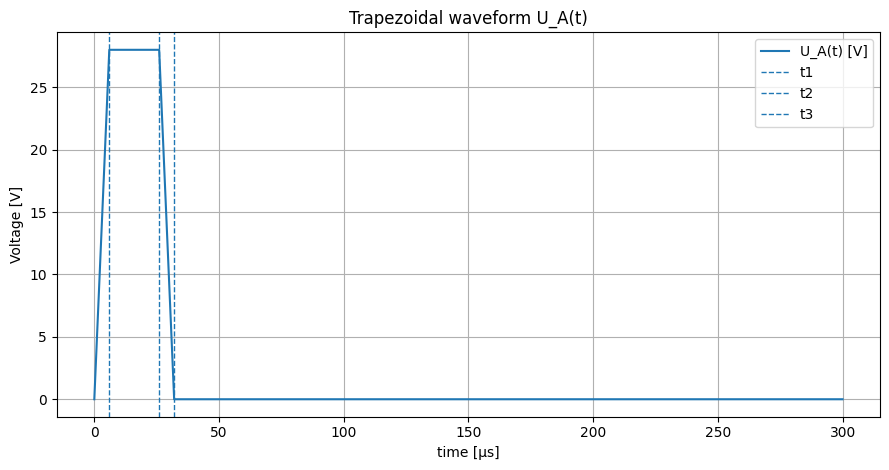

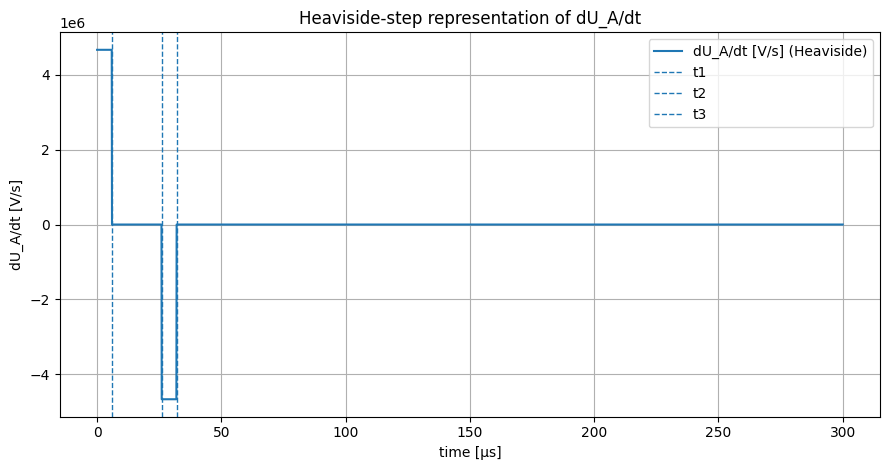

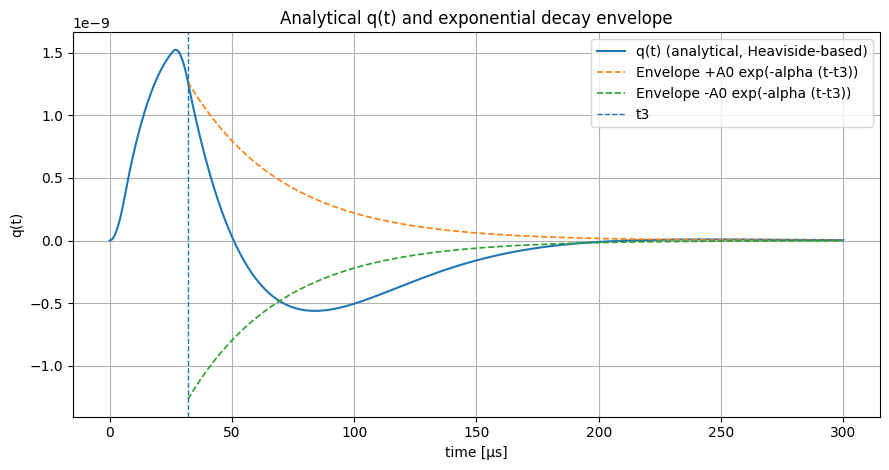

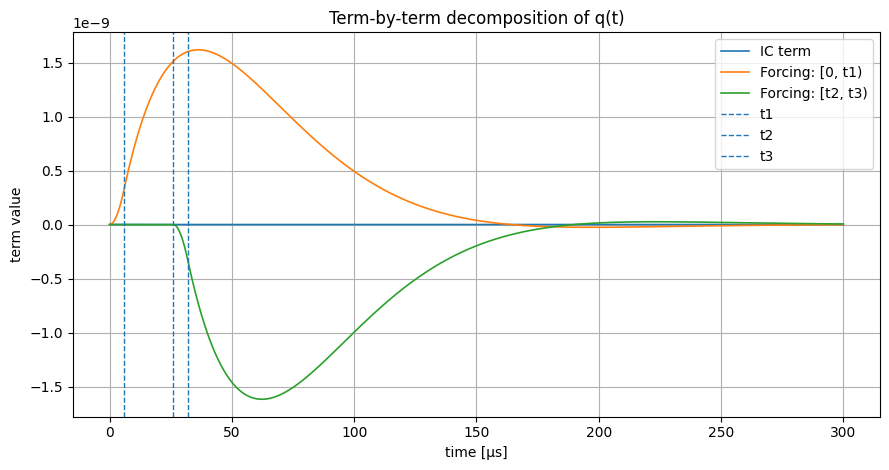

In [185]:
import torch
import math
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

# --------------------------
# 0) Given pulse params (physical unit)
# --------------------------
t1, t2, t3, V_max = 6e-6, 26e-6, 32e-6, 28.0  # [s, V]
T_end = 3e-4                                  # [s]
N = 3000                                         # timestep count (원하면 3000으로 증가)

# --------------------------
# 1) Lumped parameters (SI)  (use your computed values)
# --------------------------
sum_R         = 8.2201141783321062e+13
sum_L         = 1.5956925136093490e+09
sum_C_channel = 5.9998246244188410e-19
C_nozzle      = 8.7034370943866186e-18
sum_F        = -7.0221562553191488e+03

R_total = sum_R   # [Pa·s/m^3]
L_total = sum_L   # [kg/m^4]
C_total = sum_C_channel  # [m^3/Pa]
F_total = -sum_F   # [Pa]

# --------------------------
# 2) Initial condition: V0 (pre-charge)
#    q(0)=0,  L dq/dt|0 = V0
# --------------------------
V0 = 0.0  # [V] set your pre-charge voltage here

# --------------------------
# 3) Trapezoidal voltage function
# --------------------------
def Trapezodial_function(t: torch.Tensor) -> torch.Tensor:
    """
    t: [s]
    returns U_A(t): [V]
    Piecewise (left-inclusive, right-exclusive):
      [0, t1)  : ramp up
      [t1,t2)  : hold
      [t2,t3)  : ramp down
      [t3,  )  : 0
    """
    u = torch.zeros_like(t)

    up   = (t >= 0.0) & (t < t1)
    hold = (t >= t1) & (t < t2)
    down = (t >= t2) & (t < t3)

    u_up   = V_max * (t / t1)
    u_hold = V_max * torch.ones_like(t)
    u_down = V_max * (1.0 - (t - t2) / (t3 - t2))

    u = torch.where(up,   u_up,   u)
    u = torch.where(hold, u_hold, u)
    u = torch.where(down, u_down, u)

    return u

# --------------------------
# 4) Heaviside-step derivative dU/dt in [V/s]
#    dU/dt = +Vmax/t1          on [0, t1)
#          = 0                on [t1, t2)
#          = -Vmax/(t3-t2)    on [t2, t3)
#          = 0                on [t3, ∞)
# --------------------------
def Heaviside_step_function(t_s: torch.Tensor) -> torch.Tensor:
    """
    t_s: [s]
    returns dU_A/dt: [V/s]
    """
    dUdt = torch.zeros_like(t_s)

    up   = (t_s >= 0.0) & (t_s < t1)
    hold = (t_s >= t1) & (t_s < t2)
    down = (t_s >= t2) & (t_s < t3)

    dUdt = torch.where(up,   (V_max / t1) * torch.ones_like(t_s), dUdt)
    dUdt = torch.where(hold, 0.0 * torch.ones_like(t_s),          dUdt)
    dUdt = torch.where(down, (-V_max / (t3 - t2)) * torch.ones_like(t_s), dUdt)

    return dUdt

# --------------------------
# 5) Underdamped check and omega_d
#    alpha = R/(2L), omega0 = 1/sqrt(LC), omega_d = sqrt(omega0^2 - alpha^2)
# --------------------------
alpha_damp = R_total / (2.0 * L_total)                 # [1/s]
omega0 = 1.0 / math.sqrt(L_total * C_total)            # [rad/s]
disc = omega0**2 - alpha_damp**2

print("===== Damping check =====")
print(f"R_total = {R_total:.6e}  [Pa·s/m^3]")
print(f"L_total = {L_total:.6e}  [kg/m^4]")
print(f"C_total = {C_total:.6e}  [m^3/Pa]")
print(f"F_total = {F_total:.6e}  [Pa]")
print(f"alpha   = R/(2L)       = {alpha_damp:.6e}  [1/s]")
print(f"omega0  = 1/sqrt(LC)   = {omega0:.6e}  [rad/s]")
print(f"disc    = omega0^2-a^2 = {disc:.6e}  [rad^2/s^2]")

omega_d = math.sqrt(disc)  # [rad/s]
tau = 1.0 / alpha_damp     # [s]
print(f"omega_d = {omega_d:.6e}  [rad/s]")
print(f"tau     = 1/alpha = {tau:.6e} [s]")


# --------------------------
# 6) Build analytic q(t) for trapezoidal dU_A/dt using ON–OFF step superposition
#
#    Governing equation (underdamped):
#      L q¨ + R q˙ + (1/C) q = F (dU_A/dt)
#
#    For trapezoid U_A(t), dU_A/dt is piecewise constant:
#      dU_A/dt = +V_max/t1            for t in [0, t1)
#      dU_A/dt = 0                    for t in [t1, t2)
#      dU_A/dt = -V_max/(t3 - t2)     for t in [t2, t3)
#      dU_A/dt = 0                    for t >= t3
#
#    Represent each constant-forcing interval [ta, tb) by ON–OFF superposition:
#      k [S(t-ta) - S(t-tb)]
#
#    where S(Δt) is the step-response primitive for a constant forcing switched on at Δt=0:
#      S(Δt) = C { 1 - exp(-alpha Δt)[cos(omega_d Δt) + (alpha/omega_d) sin(omega_d Δt)] } H(Δt)
#
#    Then the forcing-driven response becomes:
#      q_forcing(t) = k_up [S(t) - S(t-t1)] + k_dn [S(t-t2) - S(t-t3)]
#      with k_up = F*(V_max/t1),  k_dn = -F*(V_max/(t3-t2)).
#
#    The total analytical response is:
#      q(t) = q_IC(t) + q_forcing(t),
#      q_IC(t) = (V0/(L*omega_d)) exp(-alpha t) sin(omega_d t).
# --------------------------
def H(x: torch.Tensor) -> torch.Tensor:
    """Heaviside step: H(x)=1 for x>=0, else 0."""
    return (x >= 0.0).to(dtype=torch.get_default_dtype())

def S(dt: torch.Tensor) -> torch.Tensor:
    """
    Step-response primitive for a step forcing of amplitude F_total:
      S(Δt) = F_total * C_total *
              {1 - exp(-alpha Δt)[cos(omega_d Δt) + (alpha/omega_d) sin(omega_d Δt)]} * H(Δt)

    Evaluate with Δt>=0 only (numerical safety), then multiply by H(Δt).
    """
    dtp = torch.clamp(dt, min=0.0)
    core = 1.0 - torch.exp(-alpha_damp * dtp) * (
        torch.cos(omega_d * dtp) + (alpha_damp / omega_d) * torch.sin(omega_d * dtp)
    )
    return C_total * core * H(dt)

# time axis
t_s = torch.linspace(0.0, T_end, N)  # [s]
t_us = (t_s * 1e6).detach().cpu().numpy()

# IC term
term_ic = (V0 / (L_total * omega_d)) * torch.exp(-alpha_damp * t_s) * torch.sin(omega_d * t_s)

# forcing amplitudes for each constant-slope interval
k_up = F_total * (V_max / t1)               # forcing during [0, t1)
k_dn = F_total * (-V_max / (t3 - t2))       # forcing during [t2, t3)


# forcing response via ON–OFF superposition
term_up = k_up * (S(t_s - 0.0) - S(t_s - t1))
term_dn = k_dn * (S(t_s - t2) - S(t_s - t3))

q_t = term_ic + term_up + term_dn
q_np = q_t.detach().cpu().numpy()


# --------------------------
# 7) Exponential decay envelope (ring-down after t3)
#    env(t) = A0 * exp(-alpha (t - t3)), for t >= t3
#    A0 is taken from the data after t3 (no arbitrary amplitude).
# --------------------------
t_np = t_s.detach().cpu().numpy()
idx_t3 = int((t_np >= t3).argmax())

T_period = 2.0 * math.pi / omega_d
t_window_end = min(T_end, t3 + 5.0 * T_period)
idx_window_end = int((t_np >= t_window_end).argmax()) if t_window_end < T_end else len(t_np)

if idx_window_end <= idx_t3 + 5:
    idx_window_end = min(len(t_np), idx_t3 + 200)

A0 = float(max(abs(q_np[idx_t3:idx_window_end]))) if idx_t3 < len(q_np) else float(max(abs(q_np)))

env_np = [math.nan] * len(q_np)
for i in range(len(q_np)):
    if t_np[i] >= t3:
        env_np[i] = A0 * math.exp(-alpha_damp * (t_np[i] - t3))
env_np = torch.tensor(env_np, dtype=torch.get_default_dtype()).detach().cpu().numpy()

print("\n===== Envelope info =====")
print(f"t3 = {t3:.6e} [s] ({t3*1e6:.3f} [µs])")
print(f"A0 (from q(t) after t3) = {A0:.6e}")
print(f"alpha = {alpha_damp:.6e} [1/s], tau = {tau:.6e} [s]")

# --------------------------
# 8) Also compute U(t) and dU/dt for reference plots
# --------------------------
U = Trapezodial_function(t_s).detach().cpu().numpy()
dUdt = Heaviside_step_function(t_s).detach().cpu().numpy()

# --------------------------
# 9) Visualization
# --------------------------
plt.figure(figsize=(9, 4.8))
plt.plot(t_us, U, linewidth=1.5, label="U_A(t) [V]")
plt.axvline(t1 * 1e6, linestyle="--", linewidth=1.0, label="t1")
plt.axvline(t2 * 1e6, linestyle="--", linewidth=1.0, label="t2")
plt.axvline(t3 * 1e6, linestyle="--", linewidth=1.0, label="t3")
plt.xlabel("time [µs]")
plt.ylabel("Voltage [V]")
plt.title("Trapezoidal waveform U_A(t)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.8))
plt.plot(t_us, dUdt, linewidth=1.5, label="dU_A/dt [V/s] (Heaviside)")
plt.axvline(t1 * 1e6, linestyle="--", linewidth=1.0, label="t1")
plt.axvline(t2 * 1e6, linestyle="--", linewidth=1.0, label="t2")
plt.axvline(t3 * 1e6, linestyle="--", linewidth=1.0, label="t3")
plt.xlabel("time [µs]")
plt.ylabel("dU_A/dt [V/s]")
plt.title("Heaviside-step representation of dU_A/dt")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.8))
plt.plot(t_us, q_np, linewidth=1.5, label="q(t) (analytical, Heaviside-based)")
plt.plot(t_us,  env_np, linestyle="--", linewidth=1.2, label="Envelope +A0 exp(-alpha (t-t3))")
plt.plot(t_us, -env_np, linestyle="--", linewidth=1.2, label="Envelope -A0 exp(-alpha (t-t3))")
plt.axvline(t3 * 1e6, linestyle="--", linewidth=1.0, label="t3")
plt.xlabel("time [µs]")
plt.ylabel("q(t)")
plt.title("Analytical q(t) and exponential decay envelope")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.8))
plt.plot(t_us, term_ic.detach().cpu().numpy(), linewidth=1.2, label="IC term")
plt.plot(t_us, term_up.detach().cpu().numpy(), linewidth=1.2, label="Forcing: [0, t1)")
plt.plot(t_us, term_dn.detach().cpu().numpy(), linewidth=1.2, label="Forcing: [t2, t3)")
plt.axvline(t1 * 1e6, linestyle="--", linewidth=1.0, label="t1")
plt.axvline(t2 * 1e6, linestyle="--", linewidth=1.0, label="t2")
plt.axvline(t3 * 1e6, linestyle="--", linewidth=1.0, label="t3")
plt.xlabel("time [µs]")
plt.ylabel("term value")
plt.title("Term-by-term decomposition of q(t)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




===== Damping check =====
R_total = 8.220114e+13  [Pa·s/m^3]
L_total = 1.595693e+09  [kg/m^4]
C_total = 5.999825e-20  [m^3/Pa]
F_total = 7.022156e+03  [Pa]
alpha   = R/(2L)       = 2.575720e+04  [1/s]
omega0  = 1/sqrt(LC)   = 1.022012e+05  [rad/s]
disc    = omega0^2-a^2 = 9.781658e+09  [rad^2/s^2]
omega_d = 9.890226e+04  [rad/s]
tau     = 1/alpha = 3.882410e-05 [s]


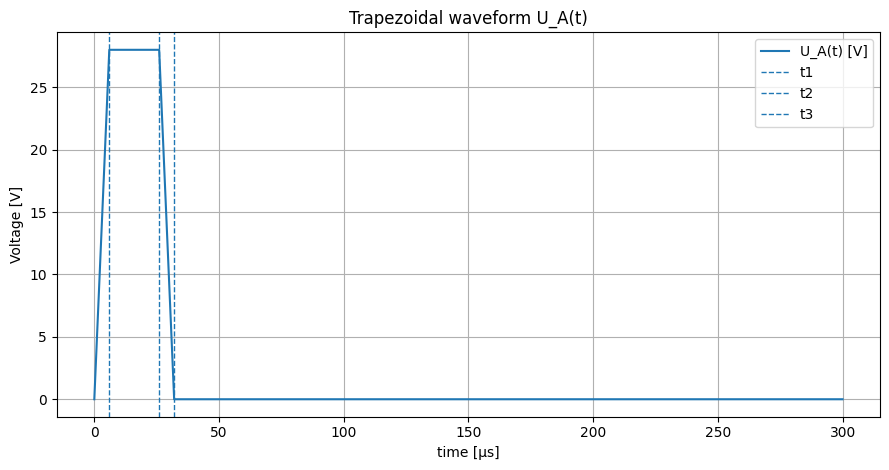

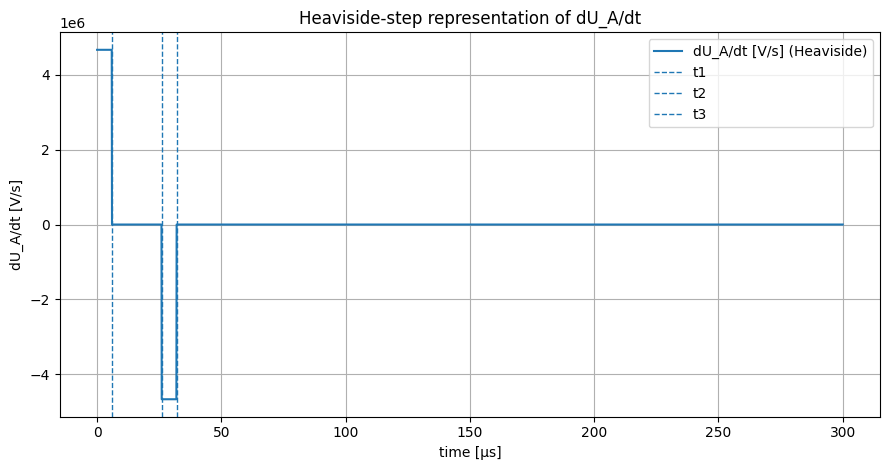

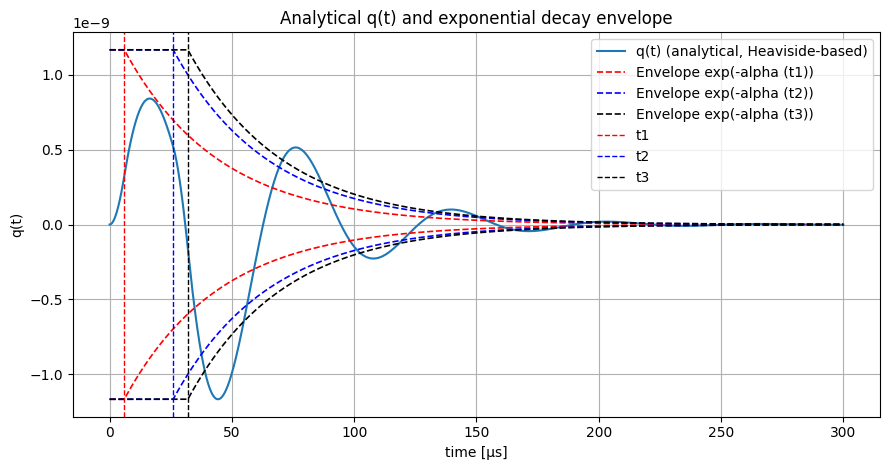

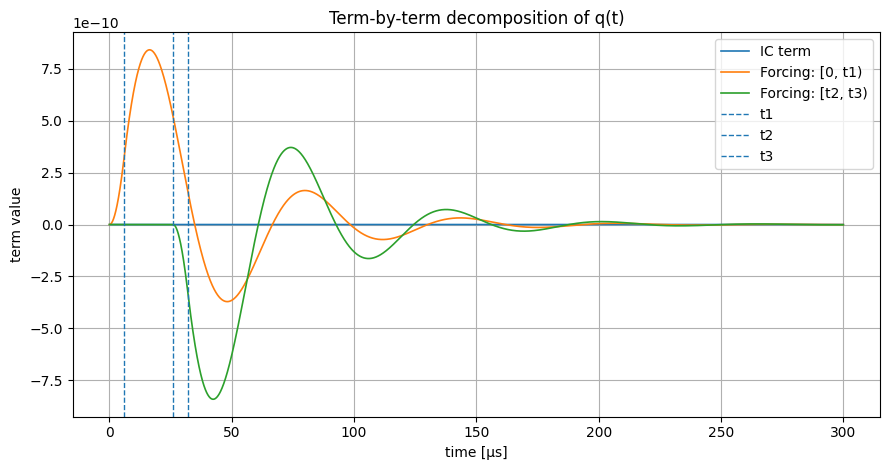

In [197]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

# --------------------------
# 0) Given pulse params (physical unit)
# --------------------------
t1, t2, t3, V_max = 6e-6, 26e-6, 32e-6, 28.0  # [s, V]
T_end = 3e-4                                  # [s]
N = 3000                                      # timestep count (원하면 3000으로 증가)

# --------------------------
# 1) Lumped parameters (SI)  (use your computed values)
# --------------------------
sum_R         = 8.2201141783321062e+13
sum_L         = 1.5956925136093490e+09
sum_C_channel = 5.9998246244188410e-20
C_nozzle      = 8.7034370943866186e-18
sum_F        = -7.0221562553191488e+03

R_total = sum_R                # [Pa·s/m^3]
L_total = sum_L                # [kg/m^4]
C_total = sum_C_channel        # [m^3/Pa]
F_total = -sum_F               # [Pa]

# --------------------------
# 2) Initial condition: V0 (pre-charge)
#    q(0)=0,  L dq/dt|0 = V0
# --------------------------
V0 = 0.0  # [V] set your pre-charge voltage here

# --------------------------
# 3) Trapezoidal voltage function
# --------------------------
def Trapezodial_function(t: torch.Tensor) -> torch.Tensor:
    """
    t: [s]
    returns U_A(t): [V]
    Piecewise (left-inclusive, right-exclusive):
      [0, t1)  : ramp up
      [t1,t2)  : hold
      [t2,t3)  : ramp down
      [t3,  )  : 0
    """
    u = torch.zeros_like(t)

    up   = (t >= 0.0) & (t < t1)
    hold = (t >= t1) & (t < t2)
    down = (t >= t2) & (t < t3)

    u_up   = V_max * (t / t1)
    u_hold = V_max * torch.ones_like(t)
    u_down = V_max * (1.0 - (t - t2) / (t3 - t2))

    u = torch.where(up,   u_up,   u)
    u = torch.where(hold, u_hold, u)
    u = torch.where(down, u_down, u)

    return u

# --------------------------
# 4) Heaviside-step derivative dU/dt in [V/s]
# --------------------------
def Heaviside_step_function(t_s: torch.Tensor) -> torch.Tensor:
    """
    t_s: [s]
    returns dU_A/dt: [V/s]
    """
    dUdt = torch.zeros_like(t_s)

    up   = (t_s >= 0.0) & (t_s < t1)
    hold = (t_s >= t1) & (t_s < t2)
    down = (t_s >= t2) & (t_s < t3)

    dUdt = torch.where(up,   (V_max / t1) * torch.ones_like(t_s), dUdt)
    dUdt = torch.where(hold, 0.0 * torch.ones_like(t_s),          dUdt)
    dUdt = torch.where(down, (-V_max / (t3 - t2)) * torch.ones_like(t_s), dUdt)

    return dUdt

# --------------------------
# 5) Underdamped check and omega_d
# --------------------------
alpha_damp = R_total / (2.0 * L_total)                 # [1/s]
omega0 = 1.0 / math.sqrt(L_total * C_total)            # [rad/s]
disc = omega0**2 - alpha_damp**2

print("===== Damping check =====")
print(f"R_total = {R_total:.6e}  [Pa·s/m^3]")
print(f"L_total = {L_total:.6e}  [kg/m^4]")
print(f"C_total = {C_total:.6e}  [m^3/Pa]")
print(f"F_total = {F_total:.6e}  [Pa]")
print(f"alpha   = R/(2L)       = {alpha_damp:.6e}  [1/s]")
print(f"omega0  = 1/sqrt(LC)   = {omega0:.6e}  [rad/s]")
print(f"disc    = omega0^2-a^2 = {disc:.6e}  [rad^2/s^2]")

# (원 코드 유지) disc<0이면 sqrt 에러가 나므로, 필요 시 아래 체크를 켜세요.
# if disc <= 0.0:
#     raise ValueError(f"Overdamped/critical: disc={disc:.6e}. omega_d is not real.")

omega_d = math.sqrt(disc)  # [rad/s]
tau = 1.0 / alpha_damp     # [s]
print(f"omega_d = {omega_d:.6e}  [rad/s]")
print(f"tau     = 1/alpha = {tau:.6e} [s]")

# --------------------------
# 6) Build analytic q(t) for trapezoidal dU_A/dt using ON–OFF step superposition
# --------------------------
def H(x: torch.Tensor) -> torch.Tensor:
    """Heaviside step: H(x)=1 for x>=0, else 0."""
    return (x >= 0.0).to(dtype=torch.get_default_dtype())

def S(dt: torch.Tensor) -> torch.Tensor:
    """
    Step-response primitive for a step forcing of amplitude F_total:
      S(Δt) = C_total *
              {1 - exp(-alpha Δt)[cos(omega_d Δt) + (alpha/omega_d) sin(omega_d Δt)]} * H(Δt)

    Evaluate with Δt>=0 only (numerical safety), then multiply by H(Δt).
    """
    dtp = torch.clamp(dt, min=0.0)
    core = 1.0 - torch.exp(-alpha_damp * dtp) * (
        torch.cos(omega_d * dtp) + (alpha_damp / omega_d) * torch.sin(omega_d * dtp)
    )
    return C_total * core * H(dt)

# time axis
t_s = torch.linspace(0.0, T_end, N)  # [s]
t_us = (t_s * 1e6).detach().cpu().numpy()

# IC term
term_ic = (V0 / (L_total * omega_d)) * torch.exp(-alpha_damp * t_s) * torch.sin(omega_d * t_s)

# forcing amplitudes for each constant-slope interval
k_up = F_total * (V_max / t1)               # forcing during [0, t1)
k_dn = F_total * (-V_max / (t3 - t2))       # forcing during [t2, t3)

# forcing response via ON–OFF superposition
term_up = k_up * (S(t_s - 0.0) - S(t_s - t1))
term_dn = k_dn * (S(t_s - t2) - S(t_s - t3))

q_t = term_ic + term_up + term_dn
q_np = q_t.detach().cpu().numpy()

# --------------------------
# 7) Exponential decay envelope
# --------------------------
t_np = t_s.detach().cpu().numpy()

# 1) indices for t1, t2, t3 (first index where t >= tk)
idx_t1 = int((t_np >= t1).argmax())
idx_t2 = int((t_np >= t2).argmax())
idx_t3 = int((t_np >= t3).argmax())

# 2) damped period (optional; kept for reference)
T_period = 2.0 * math.pi / omega_d

# 3) window end (use full horizon)
t_window_end = T_end
idx_window_end = len(t_np)

# 4) A0 for each anchor (max |q| from tk to window end)
A0_t1 = float(np.max(np.abs(q_np[idx_t1:idx_window_end]))) if idx_t1 < len(q_np) else float(np.max(np.abs(q_np)))
A0_t2 = float(np.max(np.abs(q_np[idx_t2:idx_window_end]))) if idx_t2 < len(q_np) else float(np.max(np.abs(q_np)))
A0_t3 = float(np.max(np.abs(q_np[idx_t3:idx_window_end]))) if idx_t3 < len(q_np) else float(np.max(np.abs(q_np)))

# 5) envelopes: env(tk)=A0_k, and for t>=tk exponential decay (Heaviside-style via max(.,0))
env_t1 = A0_t1 * np.exp(-alpha_damp * np.maximum(t_np - t1, 0.0))
env_t2 = A0_t2 * np.exp(-alpha_damp * np.maximum(t_np - t2, 0.0))
env_t3 = A0_t3 * np.exp(-alpha_damp * np.maximum(t_np - t3, 0.0))

# --------------------------
# 8) Also compute U(t) and dU/dt for reference plots
# --------------------------
U = Trapezodial_function(t_s).detach().cpu().numpy()
dUdt = Heaviside_step_function(t_s).detach().cpu().numpy()

# --------------------------
# 9) Visualization
# --------------------------
plt.figure(figsize=(9, 4.8))
plt.plot(t_us, U, linewidth=1.5, label="U_A(t) [V]")
plt.axvline(t1 * 1e6, linestyle="--", linewidth=1.0, label="t1")
plt.axvline(t2 * 1e6, linestyle="--", linewidth=1.0, label="t2")
plt.axvline(t3 * 1e6, linestyle="--", linewidth=1.0, label="t3")
plt.xlabel("time [µs]")
plt.ylabel("Voltage [V]")
plt.title("Trapezoidal waveform U_A(t)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.8))
plt.plot(t_us, dUdt, linewidth=1.5, label="dU_A/dt [V/s] (Heaviside)")
plt.axvline(t1 * 1e6, linestyle="--", linewidth=1.0, label="t1")
plt.axvline(t2 * 1e6, linestyle="--", linewidth=1.0, label="t2")
plt.axvline(t3 * 1e6, linestyle="--", linewidth=1.0, label="t3")
plt.xlabel("time [µs]")
plt.ylabel("dU_A/dt [V/s]")
plt.title("Heaviside-step representation of dU_A/dt")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.8))
plt.plot(t_us, q_np, linewidth=1.5, label="q(t) (analytical, Heaviside-based)")

# envelopes: t1=red, t2=blue, t3=black
plt.plot(t_us,  env_t1, linestyle="--", linewidth=1.2, color="red",   label="Envelope exp(-alpha (t1))")
plt.plot(t_us, -env_t1, linestyle="--", linewidth=1.2, color="red")

plt.plot(t_us,  env_t2, linestyle="--", linewidth=1.2, color="blue",  label="Envelope exp(-alpha (t2))")
plt.plot(t_us, -env_t2, linestyle="--", linewidth=1.2, color="blue")

plt.plot(t_us,  env_t3, linestyle="--", linewidth=1.2, color="black", label="Envelope exp(-alpha (t3))")
plt.plot(t_us, -env_t3, linestyle="--", linewidth=1.2, color="black")

# vertical lines: match the same colors
plt.axvline(t1 * 1e6, linestyle="--", linewidth=1.0, color="red",   label="t1")
plt.axvline(t2 * 1e6, linestyle="--", linewidth=1.0, color="blue",  label="t2")
plt.axvline(t3 * 1e6, linestyle="--", linewidth=1.0, color="black", label="t3")


plt.xlabel("time [µs]")
plt.ylabel("q(t)")
plt.title("Analytical q(t) and exponential decay envelope")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.8))
plt.plot(t_us, term_ic.detach().cpu().numpy(), linewidth=1.2, label="IC term")
plt.plot(t_us, term_up.detach().cpu().numpy(), linewidth=1.2, label="Forcing: [0, t1)")
plt.plot(t_us, term_dn.detach().cpu().numpy(), linewidth=1.2, label="Forcing: [t2, t3)")
plt.axvline(t1 * 1e6, linestyle="--", linewidth=1.0, label="t1")
plt.axvline(t2 * 1e6, linestyle="--", linewidth=1.0, label="t2")
plt.axvline(t3 * 1e6, linestyle="--", linewidth=1.0, label="t3")
plt.xlabel("time [µs]")
plt.ylabel("term value")
plt.title("Term-by-term decomposition of q(t)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


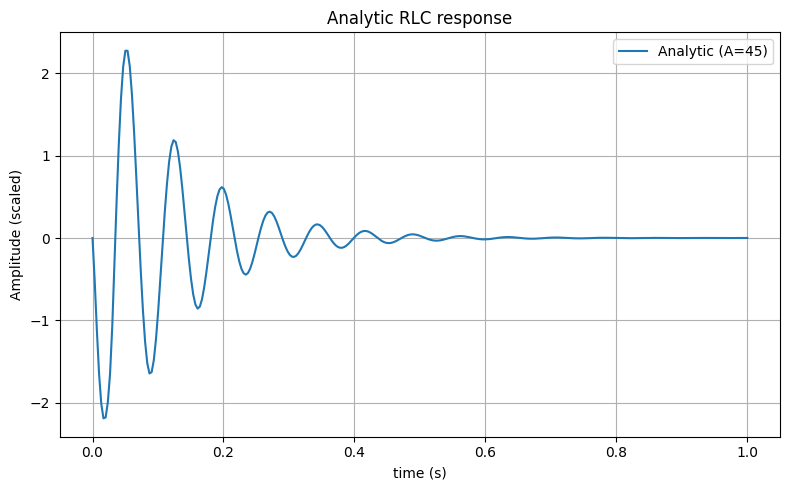

In [35]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ───── 1. 스케일 계수 A 하나만 지정 ─────────────────────────
A = 45  # 원하는 값으로 수정

# 파생 파라미터
L = 1.606e-03 * A
R = 2.896e-02 * A
C = 8.280e-02 * (1 / A)
F = -2.439e-01

# ───── 2. 공통 상수 ──────────────────────────────────────────
Vmax, t1, t2, t3 = 26.0, 6e-3, 26e-3, 32e-3   # [V], [s]
V0_ic            = -10.0                       # 초기 전압

# ───── 3. 해석 함수 정의 ────────────────────────────────────
def rlc_response(t, L, R, C, F):
    alpha   = R / (2 * L)
    omega0  = 1.0 / math.sqrt(L * C)
    omega_d = math.sqrt(max(omega0**2 - alpha**2, 0.0))

    # omega_d = 0 (critical/overdamped)인 경우 0으로 나눔 방지
    if omega_d == 0.0:
        # 이 코드의 원래 형태(underdamped 기반)에서는 omega_d=0에서
        # cos/sin 및 Bnat 항의 정의가 성립하지 않으므로,
        # 최소한의 안전 장치로 자연응답을 0 처리하고,
        # J0는 alpha^2 기준으로만 계산합니다.
        J0 = 1.0 / (L * (alpha**2))
        Bnat = 0.0

        exp_term = np.exp(-alpha * t)
        J_t = J0 * (1 - exp_term)  # omega_d→0 근사 형태(간단화)

        def J_shift(τ):
            exp_s = np.exp(-alpha * (t - τ))
            return J0 * (1 - exp_s)

    else:
        J0   = 1.0 / (L * (alpha**2 + omega_d**2))
        Bnat = V0_ic / (L * omega_d)

        exp_term = np.exp(-alpha * t)
        cos_sin  = np.cos(omega_d * t) + (alpha / omega_d) * np.sin(omega_d * t)
        J_t      = J0 * (1 - exp_term * cos_sin)

        def J_shift(τ):  # J(t-τ)
            exp_s = np.exp(-alpha * (t - τ))
            cos_s = np.cos(omega_d * (t - τ)) + (alpha / omega_d) * np.sin(omega_d * (t - τ))
            return J0 * (1 - exp_s * cos_s)

    # 자연응답
    i_nat = Bnat * np.exp(-alpha * t) * (np.sin(omega_d * t) if omega_d != 0.0 else 0.0)

    # 강제응답 계수
    K1 =  F * Vmax / t1
    K3 = -F * Vmax / (t3 - t2)

    term1 = K1 * (J_t - np.where(t >= t1, J_shift(t1), 0.0))
    term3 = np.where(
        t >= t2,
        K3 * (J_shift(t2) - np.where(t >= t3, J_shift(t3), 0.0)),
        0.0
    )

    return i_nat + term1 + term3

# ───── 4. 시각화 (CSV 관련 플롯 제거) ─────────────────────────
t_analytic = np.linspace(0.0, 1.0, 300)
i_tot = rlc_response(t_analytic, L, R, C, F)

plt.figure(figsize=(8, 5))
plt.plot(t_analytic, i_tot, linewidth=1.5, label=f"Analytic (A={A})")
plt.xlabel("time (s)")
plt.ylabel("Amplitude (scaled)")
plt.title("Analytic RLC response")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Appendix A. Physical meaning and derivation of the second-order ODE for the free response

In this study, the time response of the system is governed by a linear second-order ordinary differential equation (ODE), which is mathematically equivalent to the governing equation of a mass–spring–damper system. This equivalence indicates that an RLC circuit can be interpreted as an electrical analogue of a mechanical second-order dynamical system.

In the absence of an external driving voltage, the free response of the RLC system is described by:

$$
L \frac{d^{2} q}{dt^{2}} + R \frac{dq}{dt} + \frac{1}{C} q = 0
\tag{A.1}
$$

Where $q$ denotes the volumetric flow rate and corresponds to the electrical current $i$ under the electro–fluid analogy. Likewise, the voltage $V$ corresponds to the pressure $p$.

Depending on the component values, the RLC circuit can exhibit three distinct response types: underdamped, critically damped, and overdamped. All three responses assume that the capacitor is pre-charged to a voltage $V_{0}$ prior to switch closure, where $V_{0}=p_{0}$ under the electro–fluid analogy, and are based on the following initial conditions as:

$$
\left.q\right|_{t=0}=0
\tag{A.2}
$$
$$
L\left.\frac{dq}{dt}\right|_{t=0}=p_{0}
\tag{A.3}
$$

An underdamped response occurs when the values of $R$, $L$, and $C$ satisfy the following condition:

$$\frac{R}{2L}<\frac{1}{\sqrt{LC}}
\tag{A.4}
$$

The analytical solution under the underdamped condition is:

$$
q(t)=e^{-\frac{R}{2L}t}\left[\frac{p_{0}}{L\omega_{d}}\sin\!\left(\omega_{d}t\right)\right],
\tag{A.5}
$$

where $\omega_{d}$ is the damped natural angular frequency, defined as $\omega_{d}=\sqrt{\frac{1}{LC}-\left(\frac{R}{2L}\right)^{2}}$.


In [38]:
import torch
import math

torch.set_default_dtype(torch.float64)

# ----------------------------
# Physical parameters (SI)
# ----------------------------
sigma = 0.047        # [N/m]
mu    = 0.0157       # [Pa·s]
rho   = 1111.4       # [kg/m^3]
alpha = 0.29e-9      # [C/N]
c     = 1600         # [m/s]

r      = 235e-6      # [m]
r_nozz = 25e-6       # [m]
l1, l2, l3, l4 = 0.012, 0.0084, 0.00542303, 0.00057697  # [m]

Vt = 1.0  # [V]

# ---------------------------------------------
# 1) Time/length scales (SI)
# ---------------------------------------------
l_tot = l1 + l2 + l3 + l4                      # [m]
T_visc = 2.0 * l_tot / c                       # [s]
delta_v = torch.sqrt(mu * T_visc / (torch.tensor(math.pi) * rho))  # [m]

print("===== Time/length scales (SI) =====")
print(f"l_tot       = {l_tot:.6e}  [m]  = {l_tot*1e6:.6f}  [µm]")
print(f"T_visc      = {T_visc:.6e}  [s]  = {T_visc*1e6:.6f}  [µs]")
print(f"delta_v     = {delta_v.item():.6e}  [m]  = {delta_v.item()*1e6:.6f}  [µm]")

# ---------------------------------------------
# 2) Compliance (SI)
# ---------------------------------------------
C_channel = math.pi * (r ** 2) * l_tot / (rho * c ** 2)             # [m^3/Pa]
C_nozzle  = math.pi * (r_nozz ** 4) / (3.0 * sigma)                 # [m^3/Pa]
C_total   = C_channel + C_nozzle                                    # [m^3/Pa]
invC_total = 1.0 / C_total                                          # [Pa/m^3]

print("\n===== Compliance (SI) =====")
print(f"C_channel   = {C_channel:.6e}  [m^3/Pa]")
print(f"C_nozzle    = {C_nozzle:.6e}  [m^3/Pa]")
print(f"C_total     = {C_total:.6e}  [m^3/Pa]")
print(f"1/C_total   = {invC_total:.6e}  [Pa/m^3]")

# ---------------------------------------------
# 3) Lumped parameters (SI): R, L, C, F
# ---------------------------------------------
L_total = rho * l_tot / (math.pi * r ** 2)                          # [kg/m^4]
R_total = 2.0 * mu * l_tot / (math.pi * delta_v.item() * r ** 3)    # [Pa·s/m^3]
F_total = (2.0 * rho * (c ** 2) * alpha * Vt) / r                   # [Pa]

print("\n===== Lumped parameters (SI) =====")
print(f"R_total     = {R_total:.6e}  [Pa·s/m^3]")
print(f"L_total     = {L_total:.6e}  [kg/m^4]")
print(f"C_total     = {C_total:.6e}  [m^3/Pa]")
print(f"F_total     = {F_total:.6e}  [Pa]")

# ---------------------------------------------
# 4) Underdamped check
#    underdamped <=> (R/(2L)) < 1/sqrt(L C)
#    equivalently disc = omega0^2 - alpha_damp^2 > 0
# ---------------------------------------------
alpha_damp = R_total / (2.0 * L_total)                 # [1/s]
omega0 = 1.0 / math.sqrt(L_total * C_total)            # [rad/s]
disc = omega0**2 - alpha_damp**2                       # [rad^2/s^2]

print("\n===== Damping classification =====")
print(f"alpha_damp = R/(2L)        = {alpha_damp:.6e}  [1/s]")
print(f"omega0     = 1/sqrt(LC)    = {omega0:.6e}  [rad/s]")
print(f"disc       = omega0^2-a^2  = {disc:.6e}  [rad^2/s^2]")

# robust tolerance (floating-point safety)
tol = 1e-15 * max(omega0**2, alpha_damp**2, 1.0)

if disc > tol:
    omega_d = math.sqrt(disc)
    print("Result: UNDERDAMPED (oscillatory decay).")
    print(f"omega_d = sqrt(disc)     = {omega_d:.6e}  [rad/s]")
    print(f"Condition check: R/(2L) < 1/sqrt(LC) is True.")
elif abs(disc) <= tol:
    print("Result: CRITICALLY DAMPED (fastest non-oscillatory decay).")
    print(f"Condition check: R/(2L) = 1/sqrt(LC) (within tolerance).")
else:
    print("Result: OVERDAMPED (non-oscillatory decay).")
    print(f"Condition check: R/(2L) > 1/sqrt(LC) is True.")


===== Time/length scales (SI) =====
l_tot       = 2.640000e-02  [m]  = 26400.000000  [µm]
T_visc      = 3.300000e-05  [s]  = 33.000000  [µs]
delta_v     = 1.218138e-05  [m]  = 12.181385  [µm]

===== Compliance (SI) =====
C_channel   = 1.609827e-18  [m^3/Pa]
C_nozzle    = 8.703437e-18  [m^3/Pa]
C_total     = 1.031326e-17  [m^3/Pa]
1/C_total   = 9.696251e+16  [Pa/m^3]

===== Lumped parameters (SI) =====
R_total     = 1.669104e+12  [Pa·s/m^3]
L_total     = 1.691176e+08  [kg/m^4]
C_total     = 1.031326e-17  [m^3/Pa]
F_total     = 7.022156e+03  [Pa]

===== Damping classification =====
alpha_damp = R/(2L)        = 4.934745e+03  [1/s]
omega0     = 1/sqrt(LC)    = 2.394460e+04  [rad/s]
disc       = omega0^2-a^2  = 5.489921e+08  [rad^2/s^2]
Result: UNDERDAMPED (oscillatory decay).
omega_d = sqrt(disc)     = 2.343058e+04  [rad/s]
Condition check: R/(2L) < 1/sqrt(LC) is True.


The analytical solution under the critically damped condition is:

$$
\frac{R}{2L}=\frac{1}{\sqrt{LC}}
\tag{A.6}
$$

$$
q(t)=\frac{p_{0}}{L}\,t\,e^{-\frac{R}{2L}t}
\tag{A.7}
$$

The analytical solution under the overdamped condition is:

$$
\frac{R}{2L}>\frac{1}{\sqrt{LC}}
\tag{A.8}
$$

$$
q(t)=\frac{p_{0}}{L\left(s_{1}-s_{2}\right)}
\left(e^{s_{1}t}-e^{s_{2}t}\right),
\tag{A.9}
$$

where $s_{1}$ and $s_{2}$ are the real characteristic roots defined as
$$
s_{1,2}=-\frac{R}{2L}\pm\sqrt{\left(\frac{R}{2L}\right)^{2}-\frac{1}{LC}}.
$$



===== SI parameters =====
L_total = 1.691176e+08  [kg/m^4]
R_total = 1.669104e+12  [Pa·s/m^3]
C_total = 1.031326e-17  [m^3/Pa]
F_total = 7.022156e+03  [Pa]

===== Waveform derivative info =====
dt       = 1.000333e-07 [s]
max |dU/dt| = 4.666667e+06 [V/s]

===== System decay info =====
alpha     = 4.934745e+03 [1/s]
tau=1/alpha = 2.026447e-04 [s]
omega0    = 2.394460e+04 [rad/s]
omega0^2 - alpha^2 = 5.489921e+08
omega_d   = 2.343058e+04 [rad/s]


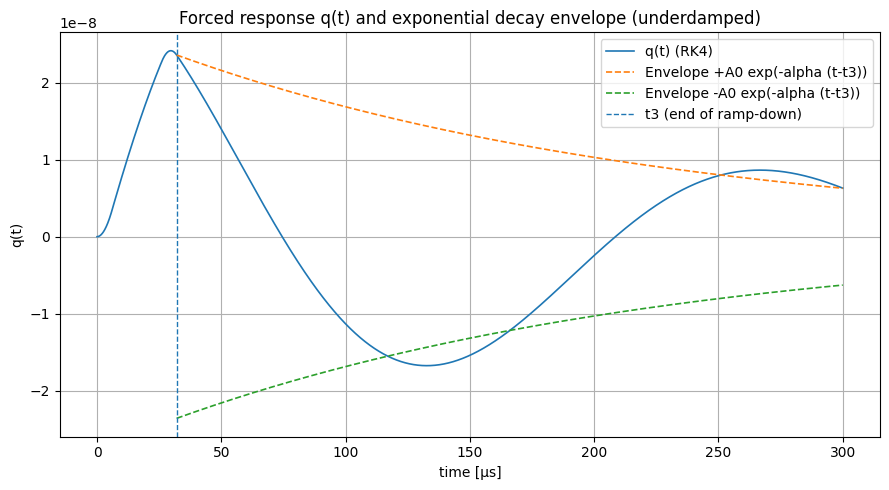

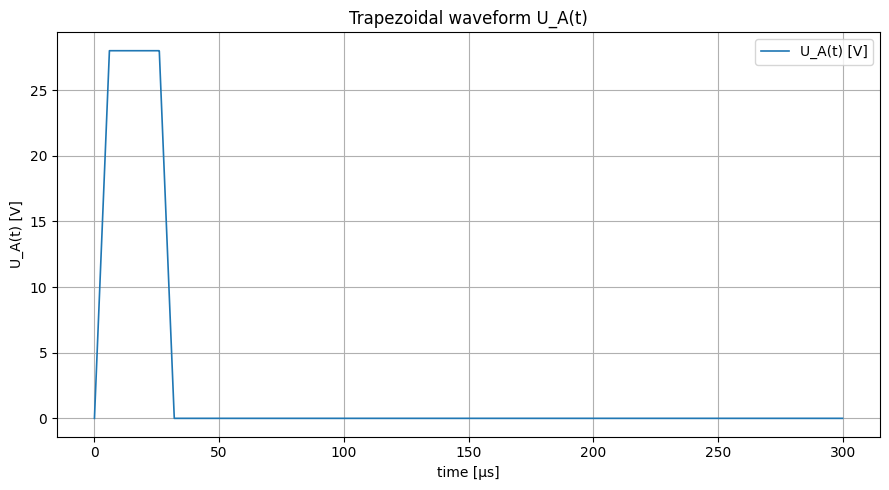

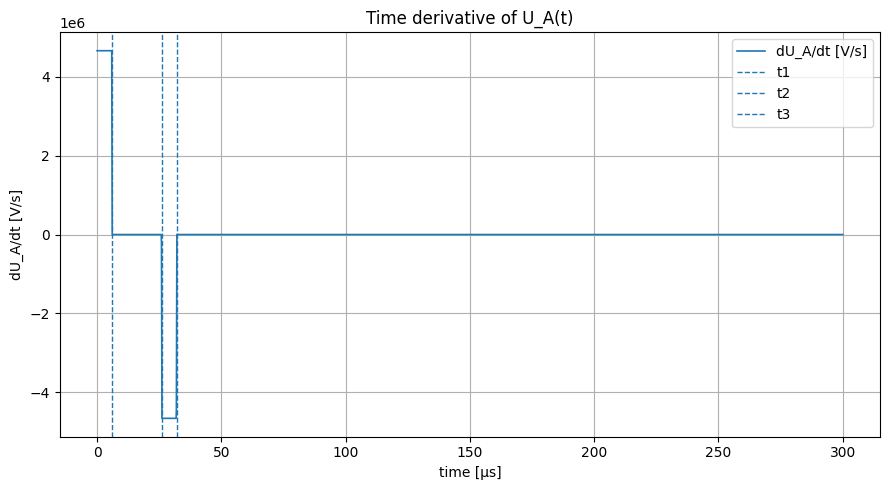


===== Envelope settings =====
t_ref = t3 = 3.200000e-05 [s]  (32.000 [µs])
A0 (from data in [t3, t3+5T]) = 2.357085e-08
alpha = 4.934745e+03 [1/s], tau = 2.026447e-04 [s]


In [37]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

# ----------------------------
# 1) Physical parameters (SI)
# ----------------------------
sigma = 0.047        # [N/m]
mu    = 0.0157       # [Pa·s]
rho   = 1111.4       # [kg/m^3]
alpha_piezo = 0.29e-9  # [C/N]
c     = 1600         # [m/s]

r      = 235e-6      # [m]
r_nozz = 25e-6       # [m]
l1, l2, l3, l4 = 0.012, 0.0084, 0.00542303, 0.00057697  # [m]

Vt = 1.0  # [V] (given)

# ----------------------------
# 2) Compute required quantities (SI)
# ----------------------------
l_tot = l1 + l2 + l3 + l4  # [m]
T_visc = 2.0 * l_tot / c   # [s]
delta_v = torch.sqrt(torch.tensor(mu * T_visc / (math.pi * rho)))  # [m]

C_channel = math.pi * (r ** 2) * l_tot / (rho * c ** 2)            # [m^3/Pa]
C_nozzle  = math.pi * (r_nozz ** 4) / (3.0 * sigma)                # [m^3/Pa]
C_total   = C_channel + C_nozzle                                   # [m^3/Pa]

L_total = rho * l_tot / (math.pi * r ** 2)                          # [kg/m^4]
R_total = 2.0 * mu * l_tot / (math.pi * float(delta_v.item()) * r ** 3)  # [Pa·s/m^3]

# F_total is used as the proportionality for pressure wrt voltage (model-dependent)
# In your prior formulation: RHS = F * dU/dt, so F should make RHS [Pa/s].
# Here we keep your given definition:
F_total = (2.0 * rho * (c ** 2) * alpha_piezo * Vt) / r             # [Pa] (as computed)

print("===== SI parameters =====")
print(f"L_total = {L_total:.6e}  [kg/m^4]")
print(f"R_total = {R_total:.6e}  [Pa·s/m^3]")
print(f"C_total = {C_total:.6e}  [m^3/Pa]")
print(f"F_total = {F_total:.6e}  [Pa]")

# --------------------------
# 3) Pulse params (physical unit)
# --------------------------
t1, t2, t3 = 6e-6, 26e-6, 32e-6   # [s]
V_max = 28.0                      # [V]
T_end = 300e-6                    # [s] (0 ~ 300 µs)
N = 3000

# --------------------------
# 4) Voltage waveform U_A(t): trapezoidal
# --------------------------
def U_A_trapezoid(t: torch.Tensor) -> torch.Tensor:
    """
    t: [s]
    return U_A(t): [V]
    """
    up   = (t <= t1)
    hold = (t > t1) & (t <= t2)
    down = (t > t2) & (t <= t3)

    u_up   = V_max * (t / t1)
    u_hold = V_max * torch.ones_like(t)
    u_down = V_max * (1.0 - (t - t2) / (t3 - t2))

    u = torch.zeros_like(t)
    u = torch.where(up, u_up, u)
    u = torch.where(hold, u_hold, u)
    u = torch.where(down, u_down, u)
    return u

# --------------------------
# 5) Numerical derivative dU/dt in [V/s] (finite difference)
# --------------------------
def dU_dt_V_per_s(U: torch.Tensor, t_s: torch.Tensor) -> torch.Tensor:
    """
    U: [V], t_s: [s]
    return dU/dt: [V/s]
    """
    dUdt = torch.zeros_like(U)
    dUdt[1:-1] = (U[2:] - U[:-2]) / (t_s[2:] - t_s[:-2])
    dUdt[0]    = (U[1] - U[0])   / (t_s[1] - t_s[0])
    dUdt[-1]   = (U[-1] - U[-2]) / (t_s[-1] - t_s[-2])
    return dUdt

# --------------------------
# 6) Time axis and forcing term
# --------------------------
t_s = torch.linspace(0.0, T_end, N)  # [s]
dt = float((t_s[1] - t_s[0]).item())

t_us = (t_s * 1e6).detach().cpu().numpy()  # [µs]

U = U_A_trapezoid(t_s)                     # [V]
dUdt = dU_dt_V_per_s(U, t_s)               # [V/s]

# Forcing term: f(t) = F * dU/dt  (consistent with your stated model form)
# Units: F_total [Pa] * dUdt [V/s] -> [Pa*V/s]. If your model interprets voltage as pressure directly,
# you may set F_total = 1 [Pa/V] scaled appropriately. Here we keep your defined F_total.
f_t = torch.tensor(F_total) * dUdt         # [model RHS units]

print("\n===== Waveform derivative info =====")
print(f"dt       = {dt:.6e} [s]")
print(f"max |dU/dt| = {float(torch.max(torch.abs(dUdt)).item()):.6e} [V/s]")

# --------------------------
# 7) Underdamped check and decay parameters
# --------------------------
alpha_damp = R_total / (2.0 * L_total)              # [1/s]
omega0 = 1.0 / math.sqrt(L_total * C_total)         # [rad/s]
disc = omega0**2 - alpha_damp**2

print("\n===== System decay info =====")
print(f"alpha     = {alpha_damp:.6e} [1/s]")
print(f"tau=1/alpha = {1.0/alpha_damp:.6e} [s]")
print(f"omega0    = {omega0:.6e} [rad/s]")
print(f"omega0^2 - alpha^2 = {disc:.6e}")

if disc <= 0.0:
    raise RuntimeError(
        f"Not underdamped: omega0^2 - alpha^2 = {disc:.6e} <= 0. "
        "The sinusoidal ring-down envelope e^{-alpha t} assumes underdamped."
    )
omega_d = math.sqrt(disc)  # [rad/s]
print(f"omega_d   = {omega_d:.6e} [rad/s]")

# --------------------------
# 8) Initial conditions
#   q(0)=0,  L dq/dt(0)=p0  -> dq/dt(0)=p0/L
#   You did not specify V0 (pre-charge). Provide it explicitly.
# --------------------------
V0_precharge = 0.0  # [V] set as needed (0 means no pre-charge)
p0 = F_total * V0_precharge  # [Pa] mapped/converted initial pressure level (model-dependent)

q0 = 0.0
qdot0 = p0 / L_total

y0 = torch.tensor([q0, qdot0], dtype=torch.float64)  # [q, qdot]

# --------------------------
# 9) RK4 integrator for the forced 2nd-order ODE
#   y = [q, qdot]
#   qddot = (1/L) ( f(t) - R qdot - (1/C) q )
# --------------------------
L_t = torch.tensor(L_total, dtype=torch.float64)
R_t = torch.tensor(R_total, dtype=torch.float64)
C_t = torch.tensor(C_total, dtype=torch.float64)

def rhs(y: torch.Tensor, f_scalar: torch.Tensor) -> torch.Tensor:
    q = y[0]
    qdot = y[1]
    qddot = (f_scalar - R_t * qdot - (1.0 / C_t) * q) / L_t
    return torch.stack([qdot, qddot])

Y = torch.zeros((N, 2), dtype=torch.float64)
Y[0, :] = y0

for n in range(N - 1):
    yn = Y[n, :]
    fn = f_t[n]
    fn1 = f_t[n + 1]

    # For RK4, approximate forcing within the step
    f_half = 0.5 * (fn + fn1)

    k1 = rhs(yn, fn)
    k2 = rhs(yn + 0.5 * dt * k1, f_half)
    k3 = rhs(yn + 0.5 * dt * k2, f_half)
    k4 = rhs(yn + dt * k3, fn1)

    Y[n + 1, :] = yn + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

q_t = Y[:, 0].detach().cpu().numpy()
qdot_t = Y[:, 1].detach().cpu().numpy()

# --------------------------
# 10) Exponential decay envelope for ring-down (after t3)
#   envelope(t) = A0 * exp(-alpha*(t - t_ref)), t_ref = t3
#   A0 is computed from data in a short window after t_ref (not a dummy value).
# --------------------------
t_ref = t3
idx_ref = int(np.searchsorted(t_s.detach().cpu().numpy(), t_ref))

# choose known physical window: from t3 to t3 + 5 periods (or until end)
T_period = 2.0 * math.pi / omega_d
window_T = 5.0 * T_period
t_end_window = min(T_end, t_ref + window_T)
idx_end = int(np.searchsorted(t_s.detach().cpu().numpy(), t_end_window))

if idx_end <= idx_ref + 5:
    idx_end = min(N, idx_ref + 200)

A0 = np.max(np.abs(q_t[idx_ref:idx_end])) if idx_ref < N else np.max(np.abs(q_t))

env = np.full_like(q_t, np.nan, dtype=np.float64)
t_np = t_s.detach().cpu().numpy()
mask = t_np >= t_ref
env[mask] = A0 * np.exp(-alpha_damp * (t_np[mask] - t_ref))

# --------------------------
# 11) Plot: q(t) with exponential envelope
# --------------------------
plt.figure(figsize=(9, 5))
plt.plot(t_us, q_t, linewidth=1.2, label="q(t) (RK4)")
plt.plot(t_us,  env, linestyle="--", linewidth=1.2, label="Envelope +A0 exp(-alpha (t-t3))")
plt.plot(t_us, -env, linestyle="--", linewidth=1.2, label="Envelope -A0 exp(-alpha (t-t3))")
plt.axvline(t3 * 1e6, linestyle="--", linewidth=1.0, label="t3 (end of ramp-down)")
plt.xlabel("time [µs]")
plt.ylabel("q(t)")
plt.title("Forced response q(t) and exponential decay envelope (underdamped)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------
# 12) Plot: waveform and dU/dt for reference
# --------------------------
U_np = U.detach().cpu().numpy()
dUdt_np = dUdt.detach().cpu().numpy()

plt.figure(figsize=(9, 5))
plt.plot(t_us, U_np, linewidth=1.2, label="U_A(t) [V]")
plt.xlabel("time [µs]")
plt.ylabel("U_A(t) [V]")
plt.title("Trapezoidal waveform U_A(t)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(t_us, dUdt_np, linewidth=1.2, label="dU_A/dt [V/s]")
plt.axvline(t1 * 1e6, linestyle="--", linewidth=1.0, label="t1")
plt.axvline(t2 * 1e6, linestyle="--", linewidth=1.0, label="t2")
plt.axvline(t3 * 1e6, linestyle="--", linewidth=1.0, label="t3")
plt.xlabel("time [µs]")
plt.ylabel("dU_A/dt [V/s]")
plt.title("Time derivative of U_A(t)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("\n===== Envelope settings =====")
print(f"t_ref = t3 = {t_ref:.6e} [s]  ({t_ref*1e6:.3f} [µs])")
print(f"A0 (from data in [t3, t3+5T]) = {A0:.6e}")
print(f"alpha = {alpha_damp:.6e} [1/s], tau = {1.0/alpha_damp:.6e} [s]")


===== System decay info (same for both V0_ic) =====
alpha   = 9.016189e+00  [1/s]
tau     = 1.109116e-01  [s]
omega0  = 8.671856e+01  [1/s]
omega_d = 8.624858e+01  [1/s]

[V0_ic = -10.0]
Bnat (scale) = -1.604316e+00
envelope(t=0)= 1.604316e+00
envelope(t=tau)= 5.901950e-01  (should be ~ e^-1 of t=0)

[V0_ic = -40.0]
Bnat (scale) = -6.417265e+00
envelope(t=0)= 6.417265e+00
envelope(t=tau)= 2.360780e+00  (should be ~ e^-1 of t=0)


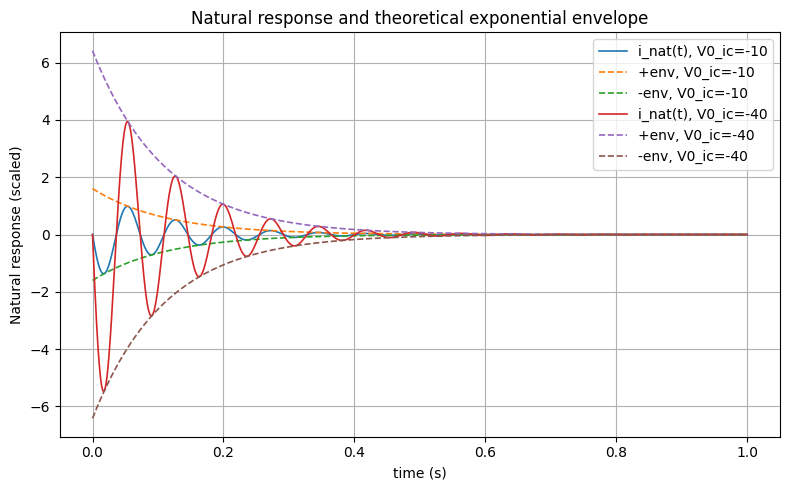

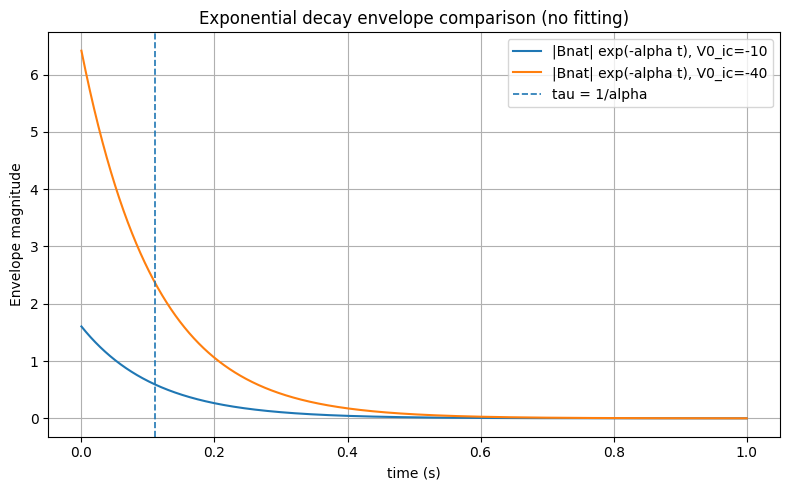

In [36]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ───── 1. 스케일 계수 A 하나만 지정 ─────────────────────────
A = 45  # 원하는 값으로 수정

# 파생 파라미터
L = 1.606e-03 * A
R = 2.896e-02 * A
C = 8.280e-02 * (1 / A)
F = -2.439e-01  # 여기서는 decay 자체엔 직접 사용하지 않음

# ───── 2. 공통 상수 ──────────────────────────────────────────
Vmax, t1, t2, t3 = 26.0, 6e-3, 26e-3, 32e-3   # [V], [s]

# 비교할 초기조건
V0_cases = [-10.0, -40.0]

# ───── 3. 시스템 고유 파라미터(감쇠율) 계산 ──────────────────
alpha = R / (2.0 * L)                 # [1/s]
omega0 = 1.0 / math.sqrt(L * C)       # [1/s]
disc = omega0**2 - alpha**2

if disc <= 0.0:
    raise RuntimeError(
        f"Not underdamped: omega0^2 - alpha^2 = {disc:.6e} <= 0. "
        "This envelope form with sin(omega_d t) assumes underdamped."
    )

omega_d = math.sqrt(disc)             # [1/s]
tau = 1.0 / alpha                     # [s]

print("===== System decay info (same for both V0_ic) =====")
print(f"alpha   = {alpha:.6e}  [1/s]")
print(f"tau     = {tau:.6e}  [s]")
print(f"omega0  = {omega0:.6e}  [1/s]")
print(f"omega_d = {omega_d:.6e}  [1/s]")

# ───── 4. 시간축 ─────────────────────────────────────────────
t = np.linspace(0.0, 1.0, 3000)  # [s]

# ───── 5. 자연응답 및 envelope 계산 (log-fit 없이 이론값) ─────
results = {}
for V0_ic in V0_cases:
    Bnat = V0_ic / (L * omega_d)                  # natural response amplitude factor
    i_nat = Bnat * np.exp(-alpha * t) * np.sin(omega_d * t)
    env = np.abs(Bnat) * np.exp(-alpha * t)       # envelope magnitude

    results[V0_ic] = {
        "Bnat": Bnat,
        "i_nat": i_nat,
        "env": env
    }

    print(f"\n[V0_ic = {V0_ic:.1f}]")
    print(f"Bnat (scale) = {Bnat:.6e}")
    print(f"envelope(t=0)= {env[0]:.6e}")
    print(f"envelope(t=tau)= {np.abs(Bnat)*np.exp(-alpha*tau):.6e}  (should be ~ e^-1 of t=0)")

# ───── 6. 시각화 1: 각 케이스 자연응답 + envelope ────────────
plt.figure(figsize=(8, 5))
for V0_ic in V0_cases:
    i_nat = results[V0_ic]["i_nat"]
    env = results[V0_ic]["env"]
    plt.plot(t, i_nat, linewidth=1.2, label=f"i_nat(t), V0_ic={V0_ic:g}")
    plt.plot(t,  env, linewidth=1.2, linestyle="--", label=f"+env, V0_ic={V0_ic:g}")
    plt.plot(t, -env, linewidth=1.2, linestyle="--", label=f"-env, V0_ic={V0_ic:g}")

plt.xlabel("time (s)")
plt.ylabel("Natural response (scaled)")
plt.title("Natural response and theoretical exponential envelope")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ───── 7. 시각화 2: envelope만 비교 (두 케이스) ───────────────
plt.figure(figsize=(8, 5))
for V0_ic in V0_cases:
    env = results[V0_ic]["env"]
    plt.plot(t, env, linewidth=1.5, label=f"|Bnat| exp(-alpha t), V0_ic={V0_ic:g}")

plt.axvline(tau, linestyle="--", linewidth=1.2, label="tau = 1/alpha")
plt.xlabel("time (s)")
plt.ylabel("Envelope magnitude")
plt.title("Exponential decay envelope comparison (no fitting)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


[Metrics @ v24]  MSE=3.006713e-04  MAE=1.195722e-02  Pearson r=0.9926


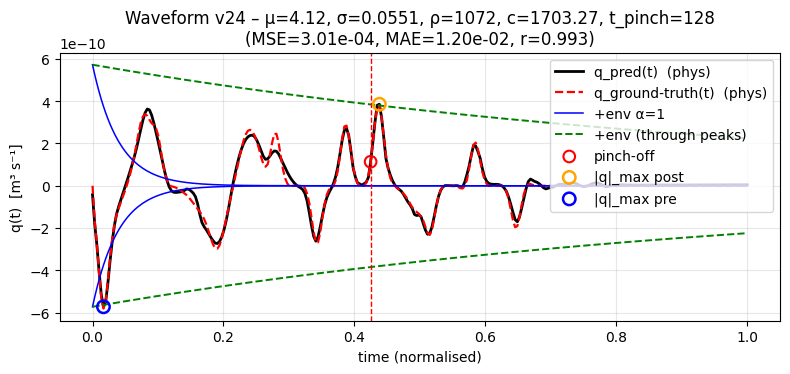

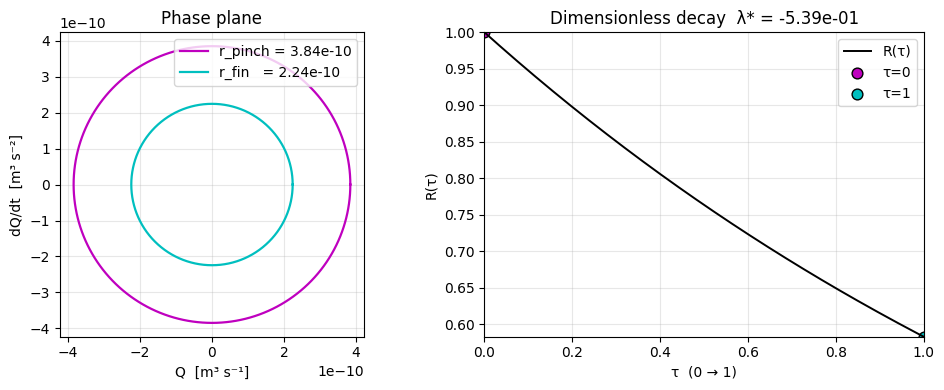

In [11]:
# ======================================================================
# 0) Imports & DEVICE ---------------------------------------------------
# ======================================================================
import math, os, numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ======================================================================
# 7) expo_decay (시각화용)  ← 스칼라 5개 체계로 수정 -------------------
# ======================================================================
def expo_decay(q_pred, scal_row, t_pinch_idx):
    """
    q_pred      : (300,) numpy  – 모델 예측(무차원 q) = Volumetric flowrate q(t): (Dynamic response, X(t))
    scal_row    : (5,)          – (μ, σ, ρ, c, t_pinch) = Feature data
    t_pinch_idx : int           – 0-based pinch index (t_pinch-1) = Drop on demand droplet pinch off time point = 
    반환: dict (모든 좌표·envelope) = Dynamic response exponential decay e^x(t)
    """
    t_norm = np.linspace(0, 1, 300)
    q_arr  = q_pred.copy()

    idx_pin   = t_pinch_idx
    t_star    = t_norm[idx_pin]
    q_star    = q_arr[idx_pin]

    # post-pinch
    idx_amp = t_amp = q_amp = None
    if idx_pin+1 < len(q_arr):
        post_q    = q_arr[idx_pin+1:]
        idx_rel   = np.argmax(np.abs(post_q))
        idx_amp   = idx_pin+1+idx_rel
        t_amp, q_amp = t_norm[idx_amp], q_arr[idx_amp]

    # pre-pinch
    idx_pre = t_pre = q_pre = None
    if idx_pin > 0:
        pre_q   = q_arr[:idx_pin]
        idx_pre = np.argmax(np.abs(pre_q))
        t_pre, q_pre = t_norm[idx_pre], q_arr[idx_pre]

    # ------------------------------  물성 파생 파라미터 (예: 감쇠)  ------------------------------
    mu, sigma, rho, c, t_pinch = scal_row
    l1,l2,l3,l4 = 0.012, 0.0084, 0.00542303, 0.00057697
    L_tot, r_ch = l1+l2+l3+l4, 235e-6
    T_visc = 2*L_tot / c
    delta_v= math.sqrt(mu*T_visc/math.pi/rho)
    R = 2*mu*L_tot/(math.pi*delta_v*r_ch**3)
    L = rho*L_tot/(math.pi*r_ch**2)
    C = math.pi*r_ch**2*L_tot/(c**2*rho)

    zeta    = R / (2*math.sqrt(L/C))
    omega_n = 1.0 / math.sqrt(L*C)

    # ------------------------------  envelope & 물리 스케일 변환  ------------------------------
    scale = 1e-9
    q_phys = q_arr*scale
    t_s    = t_norm*300e-6
    A_env  = np.max(np.abs(q_phys))
    env_a1 =  A_env*np.exp(-1.0*zeta*omega_n*t_s)

    env_cust = None
    if (idx_pre is not None) and (idx_amp is not None):
        t_pre_s = t_pre*300e-6
        t_amp_s = t_amp*300e-6
        denom = (zeta*omega_n*(t_amp_s - t_pre_s))
        if denom != 0 and (abs(q_pre) > 0) and (abs(q_amp) > 0):
            alpha_c = (np.log(abs(q_pre*scale)/abs(q_amp*scale)) / denom)
            env_cust = A_env*np.exp(-alpha_c*zeta*omega_n*t_s)

    return dict(t=t_norm, q=q_phys,
                idx_pin=idx_pin, t_star=t_star, q_star=q_star*scale,
                idx_amp=idx_amp, t_amp=t_amp, q_amp=q_amp*scale if q_amp is not None else None,
                idx_pre=idx_pre, t_pre=t_pre, q_pre=q_pre*scale if q_pre is not None else None,
                env_a1=env_a1, env_cust=env_cust)

def decay_rate(env: dict):
    """
    env : expo_decay()가 돌려준 dict
    반환 : None  (env_cust가 없으면)  또는
           {lam_star, r_pinch, r_fin, tau, R_tau}
    """
    env_c = env["env_cust"]
    if env_c is None:
        return None

    idx_p   = env["idx_pin"]
    r_pinch = abs(env_c[idx_p])             # |q| at pinch (envelope 값)
    r_fin   = abs(env_c[-1])                # |q| at t_norm = 1

    t       = env["t"]
    tau     = (t - t[idx_p]) / (t[-1] - t[idx_p])     # 0 → 1
    R_tau   = env_c / r_pinch
    mask    = (tau >= 0) & (tau <= 1)
    tau_seg = tau[mask]
    R_seg   = R_tau[mask]

    lam_star = math.log(r_fin / r_pinch) if r_pinch > 0 and r_fin > 0 else float('nan')

    return dict(lam_star=lam_star,
                r_pinch=r_pinch, r_fin=r_fin,
                tau=tau_seg, R_tau=R_seg)

# ======================================================================
# 8) Exponential decay & visualization  +  GT(원 데이터) 비교 ----------
# ======================================================================
# 전처리 블록에서 생성한 사전들을 그대로 사용:
#   - WAVE_DB : waveform_id → v1..v300 (np.float32)
#   - GT_DB   : waveform_id → q1..q300 (np.float32)

# 예측 입력 구성 (★ x1/x2 분리 인덱스 5로 수정)
single = (4.12, 0.0551, 1072, 1703.27, 128, "v24")   # 5 scalars + id
mu, sigma, rho, c_val, t_pinch, wid = single

v_wave = WAVE_DB[wid]  # (300,)

x_np  = np.concatenate([[mu, sigma, rho, c_val, t_pinch], v_wave]).astype(np.float32)
x1_np, x2_np = x_np[:5], x_np[5:]

model.eval()
with torch.no_grad():
    q_out = model(torch.from_numpy(x1_np).unsqueeze(0).to(DEVICE),
                  torch.from_numpy(x2_np).unsqueeze(0).to(DEVICE)
                 ).squeeze(0).cpu().numpy()   # (300,)  — 예측(무차원)

# 정답(무차원) 불러오기
if wid not in GT_DB:
    raise KeyError(f"waveform_id {wid} not found in GT_DB.")
q_gt = GT_DB[wid].astype(np.float32)          # (300,) — 원래 Y (무차원)

# expo_decay는 내부에서 예측을 물리단위(×1e-9)로 변환하여 반환
ed = expo_decay(q_out, np.array([mu, sigma, rho, c_val, t_pinch], dtype=np.float64), t_pinch-1)

# 원 데이터도 같은 스케일(물리 단위)로 일관 변환
scale = 1e-9
q_gt_phys = q_gt * scale

# ------------------  정량 지표 ------------------
mse = float(np.mean((q_out - q_gt)**2))
mae = float(np.mean(np.abs(q_out - q_gt)))
# Pearson r: 분산 0 방지
if (np.std(q_out) > 0) and (np.std(q_gt) > 0):
    r = float(np.corrcoef(q_out, q_gt)[0,1])
else:
    r = np.nan

print(f"[Metrics @ {wid}]  MSE={mse:.6e}  MAE={mae:.6e}  Pearson r={r:.4f}")

# ------------------  시각화 (예측 vs 원데이터) ------------------
plt.figure(figsize=(8,4))
plt.plot(ed['t'], ed['q'], 'k', lw=2, label='q_pred(t)  (phys)')
plt.plot(ed['t'], q_gt_phys, 'r--', lw=1.6, label='q_ground-truth(t)  (phys)')
plt.plot(ed['t'],  ed['env_a1'], 'b-', lw=1.1, label='+env α=1')
plt.plot(ed['t'], -ed['env_a1'], 'b-', lw=1.1)

if ed['env_cust'] is not None:
    plt.plot(ed['t'],  ed['env_cust'], 'g--', lw=1.4, label='+env (through peaks)')
    plt.plot(ed['t'], -ed['env_cust'], 'g--', lw=1.4)

plt.axvline(ed['t_star'], color='red', ls='--', lw=1)
plt.scatter(ed['t_star'], ed['q_star'], s=70, facecolors='none',
            edgecolors='red', linewidths=1.5, zorder=3, label='pinch-off')

if ed['idx_amp'] is not None:
    plt.scatter(ed['t_amp'], ed['q_amp'], s=80, facecolors='none',
                edgecolors='orange', linewidths=1.8, zorder=3,
                label='|q|_max post')
if ed['idx_pre'] is not None:
    plt.scatter(ed['t_pre'], ed['q_pre'], s=80, facecolors='none',
                edgecolors='blue', linewidths=1.8, zorder=3,
                label='|q|_max pre')

plt.xlabel('time (normalised)')
plt.ylabel('q(t)  [m³ s⁻¹]')
plt.title(f"Waveform {wid} – μ={mu}, σ={sigma}, ρ={rho}, c={c_val}, t_pinch={t_pinch}\n"
          f"(MSE={mse:.2e}, MAE={mae:.2e}, r={r:.3f})")
plt.grid(alpha=.3); plt.legend(loc='upper right'); plt.tight_layout(); plt.show()

# ======================================================================
# 9) Decay-rate ‧ phase-plane 시각화 -----------------------------------
# ======================================================================
dr = decay_rate(ed)
if dr is None:
    print("[skip] env_cust 없음 → λ* subplot 생략")
else:
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4))

    # (좌) phase plane : r_pinch, r_fin 원
    theta = np.linspace(0, 2*np.pi, 361)
    axL.plot(dr['r_pinch']*np.cos(theta), dr['r_pinch']*np.sin(theta),
             'm-', lw=1.6, label=f"r_pinch = {dr['r_pinch']:.2e}")
    axL.plot(dr['r_fin']  *np.cos(theta), dr['r_fin']  *np.sin(theta),
             'c-', lw=1.6, label=f"r_fin   = {dr['r_fin']:.2e}")
    axL.set_aspect("equal");   axL.grid(alpha=.3)
    axL.set_xlabel("Q  [m³ s⁻¹]")
    axL.set_ylabel("dQ/dt  [m³ s⁻²]")
    axL.set_title("Phase plane");   axL.legend(loc="upper right")

    # (우) R(τ) 곡선
    axR.plot(dr['tau'], dr['R_tau'], 'k-', lw=1.4, label="R(τ)")
    axR.scatter(0, 1,                          c='m', edgecolors='k', s=60, label="τ=0")
    axR.scatter(1, dr['r_fin']/dr['r_pinch'],  c='c', edgecolors='k', s=60, label="τ=1")
    axR.set_xlim(0, 1)
    axR.set_ylim(min(dr['R_tau'].min(), 1.0), max(dr['R_tau'].max(), 1.0))
    axR.set_xlabel("τ  (0 → 1)")
    axR.set_ylabel("R(τ)")
    axR.set_title(fr"Dimensionless decay  λ* = {dr['lam_star']:.2e}")
    axR.grid(alpha=.3);   axR.legend(loc="upper right")

    plt.tight_layout();   plt.show()


---
---

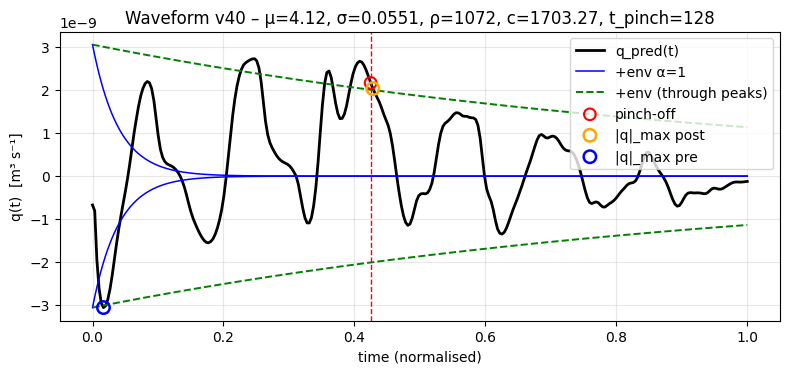

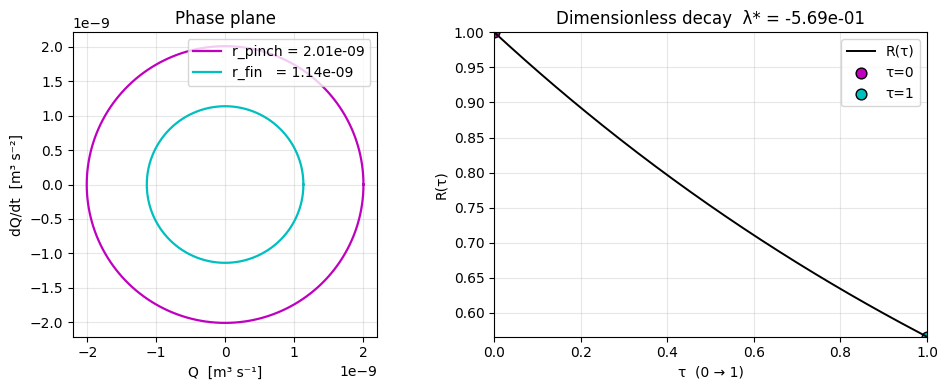

In [27]:
# ======================================================================
# 0) Imports & DEVICE ---------------------------------------------------
# ======================================================================
import math, os, numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ======================================================================
# 7) expo_decay (시각화용)  ← 스칼라 5개 체계로 수정 -------------------
# ======================================================================
def expo_decay(q_pred, scal_row, t_pinch_idx):
    """
    q_pred      : (300,) numpy  – 모델 예측(무차원 q)
    scal_row    : (5,)          – (μ, σ, ρ, c, t_pinch)   ★ 6 → 5
    t_pinch_idx : int           – 0-based pinch index (t_pinch-1)
    반환: dict (모든 좌표·envelope)
    """
    # ------------------------------
    # 1. pre/post-pinch max 검색
    # ------------------------------
    t_norm = np.linspace(0, 1, 300)
    q_arr  = q_pred.copy()

    idx_pin   = t_pinch_idx
    t_star    = t_norm[idx_pin]
    q_star    = q_arr[idx_pin]

    # post-pinch
    idx_amp = t_amp = q_amp = None
    if idx_pin+1 < len(q_arr):
        post_q    = q_arr[idx_pin+1:]
        idx_rel   = np.argmax(np.abs(post_q))
        idx_amp   = idx_pin+1+idx_rel
        t_amp, q_amp = t_norm[idx_amp], q_arr[idx_amp]

    # pre-pinch
    idx_pre = t_pre = q_pre = None
    if idx_pin > 0:
        pre_q   = q_arr[:idx_pin]
        idx_pre = np.argmax(np.abs(pre_q))
        t_pre, q_pre = t_norm[idx_pre], q_arr[idx_pre]

    # ------------------------------
    # 2. 비정규화 R,L,C 계산 (p_level 제거)
    # ------------------------------
    mu, sigma, rho, c, t_pinch = scal_row  # ★ 5개 언패킹
    l1,l2,l3,l4 = 0.012, 0.0084, 0.00542303, 0.00057697
    L_tot, r_ch = l1+l2+l3+l4, 235e-6
    T_visc = 2*L_tot / c
    delta_v= math.sqrt(mu*T_visc/math.pi/rho)
    R = 2*mu*L_tot/(math.pi*delta_v*r_ch**3)
    L = rho*L_tot/(math.pi*r_ch**2)
    C = math.pi*r_ch**2*L_tot/(c**2*rho)

    zeta    = R / (2*math.sqrt(L/C))
    omega_n = 1.0 / math.sqrt(L*C)

    # ------------------------------
    # 3. envelope 계산
    # ------------------------------
    scale = 1e-9
    q_phys = q_arr*scale
    t_s    = t_norm*300e-6
    A_env  = np.max(np.abs(q_phys))
    env_a1 =  A_env*np.exp(-1.0*zeta*omega_n*t_s)

    env_cust = None
    if (idx_pre is not None) and (idx_amp is not None):
        t_pre_s = t_pre*300e-6
        t_amp_s = t_amp*300e-6
        # 방어적 분모 보호
        denom = (zeta*omega_n*(t_amp_s - t_pre_s))
        if denom != 0 and (abs(q_pre) > 0) and (abs(q_amp) > 0):
            alpha_c = (np.log(abs(q_pre*scale)/abs(q_amp*scale)) / denom)
            env_cust = A_env*np.exp(-alpha_c*zeta*omega_n*t_s)

    return dict(t=t_norm, q=q_phys,
                idx_pin=idx_pin, t_star=t_star, q_star=q_star*scale,
                idx_amp=idx_amp, t_amp=t_amp, q_amp=q_amp*scale if q_amp is not None else None,
                idx_pre=idx_pre, t_pre=t_pre, q_pre=q_pre*scale if q_pre is not None else None,
                env_a1=env_a1, env_cust=env_cust)

def decay_rate(env: dict):
    """
    env : expo_decay()가 돌려준 dict
    반환 : None  (env_cust가 없으면)  또는
           {lam_star, r_pinch, r_fin, tau, R_tau}
    """
    env_c = env["env_cust"]
    if env_c is None:
        return None

    idx_p   = env["idx_pin"]
    r_pinch = abs(env_c[idx_p])             # |q| at pinch (envelope 값)
    r_fin   = abs(env_c[-1])                # |q| at t_norm = 1

    t       = env["t"]
    tau     = (t - t[idx_p]) / (t[-1] - t[idx_p])     # 0 → 1
    R_tau   = env_c / r_pinch
    mask    = (tau >= 0) & (tau <= 1)
    tau_seg = tau[mask]
    R_seg   = R_tau[mask]

    lam_star = math.log(r_fin / r_pinch) if r_pinch > 0 and r_fin > 0 else float('nan')

    return dict(lam_star=lam_star,
                r_pinch=r_pinch, r_fin=r_fin,
                tau=tau_seg, R_tau=R_seg)

# ======================================================================
# 8) Exponential decay & visualization ---------------------------------
# ======================================================================
# 예측 입력 구성 (★ x1/x2 분리 인덱스 5로 수정)
single = (4.12, 0.0551, 1072, 1703.27, 128, "v40")   # 5 scalars + id
mu, sigma, rho, c_val, t_pinch, wid = single

v_wave = WAVE_DB[wid]  # (300,)

x_np  = np.concatenate([[mu, sigma, rho, c_val, t_pinch], v_wave]).astype(np.float32)
x1_np, x2_np = x_np[:5], x_np[5:]  # ★ 6→5 로 수정

model.eval()
with torch.no_grad():
    q_out = model(torch.from_numpy(x1_np).unsqueeze(0).to(DEVICE),
                  torch.from_numpy(x2_np).unsqueeze(0).to(DEVICE)
                 ).squeeze(0).cpu().numpy()

# expo_decay 호출도 5개 스칼라로 전달
ed = expo_decay(q_out, np.array([mu, sigma, rho, c_val, t_pinch], dtype=np.float64), t_pinch-1)

# ------------------  시각화 ------------------
plt.figure(figsize=(8,4))
plt.plot(ed['t'], ed['q'], 'k', lw=2, label='q_pred(t)')
plt.plot(ed['t'],  ed['env_a1'], 'b-', lw=1.1, label='+env α=1')
plt.plot(ed['t'], -ed['env_a1'], 'b-', lw=1.1)

if ed['env_cust'] is not None:
    plt.plot(ed['t'],  ed['env_cust'], 'g--', lw=1.4, label='+env (through peaks)')
    plt.plot(ed['t'], -ed['env_cust'], 'g--', lw=1.4)

plt.axvline(ed['t_star'], color='red', ls='--', lw=1)
plt.scatter(ed['t_star'], ed['q_star'], s=70, facecolors='none',
            edgecolors='red', linewidths=1.5, zorder=3, label='pinch-off')

if ed['idx_amp'] is not None:
    plt.scatter(ed['t_amp'], ed['q_amp'], s=80, facecolors='none',
                edgecolors='orange', linewidths=1.8, zorder=3,
                label='|q|_max post')
if ed['idx_pre'] is not None:
    plt.scatter(ed['t_pre'], ed['q_pre'], s=80, facecolors='none',
                edgecolors='blue', linewidths=1.8, zorder=3,
                label='|q|_max pre')

plt.xlabel('time (normalised)')
plt.ylabel('q(t)  [m³ s⁻¹]')
plt.title(f"Waveform {wid} – μ={mu}, σ={sigma}, ρ={rho}, c={c_val}, t_pinch={t_pinch}")
plt.grid(alpha=.3); plt.legend(loc='upper right'); plt.tight_layout(); plt.show()

# ======================================================================
# 9) Decay-rate ‧ phase-plane 시각화 -----------------------------------
# ======================================================================
dr = decay_rate(ed)
if dr is None:
    print("[skip] env_cust 없음 → λ* subplot 생략")
else:
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4))

    # (좌) phase plane : r_pinch, r_fin 원
    theta = np.linspace(0, 2*np.pi, 361)
    axL.plot(dr['r_pinch']*np.cos(theta), dr['r_pinch']*np.sin(theta),
             'm-', lw=1.6, label=f"r_pinch = {dr['r_pinch']:.2e}")
    axL.plot(dr['r_fin']  *np.cos(theta), dr['r_fin']  *np.sin(theta),
             'c-', lw=1.6, label=f"r_fin   = {dr['r_fin']:.2e}")
    axL.set_aspect("equal");   axL.grid(alpha=.3)
    axL.set_xlabel("Q  [m³ s⁻¹]")
    axL.set_ylabel("dQ/dt  [m³ s⁻²]")
    axL.set_title("Phase plane");   axL.legend(loc="upper right")

    # (우) R(τ) 곡선
    axR.plot(dr['tau'], dr['R_tau'], 'k-', lw=1.4, label="R(τ)")
    axR.scatter(0, 1,                          c='m', edgecolors='k', s=60, label="τ=0")
    axR.scatter(1, dr['r_fin']/dr['r_pinch'],  c='c', edgecolors='k', s=60, label="τ=1")
    axR.set_xlim(0, 1)
    axR.set_ylim(min(dr['R_tau'].min(), 1.0), max(dr['R_tau'].max(), 1.0))
    axR.set_xlabel("τ  (0 → 1)")
    axR.set_ylabel("R(τ)")
    axR.set_title(fr"Dimensionless decay  λ* = {dr['lam_star']:.2e}")
    axR.grid(alpha=.3);   axR.legend(loc="upper right")

    plt.tight_layout();   plt.show()


---

In [19]:
# ======================================================================
# 8) Exponential decay & visualization ---------------------------------
# ======================================================================
# 예측 입력 구성 (★ x1/x2 분리 인덱스 5로 수정)
single = (15.76, 0.0474, 1114, 1688, 118, "v20")   # 5 scalars + id
mu, sigma, rho, c_val, t_pinch, wid = single

v_wave = WAVE_DB[wid]  # (300,)

x_np  = np.concatenate([[mu, sigma, rho, c_val, t_pinch], v_wave]).astype(np.float32)
x1_np, x2_np = x_np[:5], x_np[5:]  # ★ 6→5 로 수정

model.eval()
with torch.no_grad():
    q_out = model(torch.from_numpy(x1_np).unsqueeze(0).to(DEVICE),
                  torch.from_numpy(x2_np).unsqueeze(0).to(DEVICE)
                 ).squeeze(0).cpu().numpy()

# expo_decay 호출도 5개 스칼라로 전달
ed = expo_decay(q_out, np.array([mu, sigma, rho, c_val, t_pinch], dtype=np.float64), t_pinch-1)

# ------------------  시각화 ------------------
plt.figure(figsize=(8,4))
plt.plot(ed['t'], ed['q'], 'k', lw=2, label='q_pred(t)')
plt.plot(ed['t'],  ed['env_a1'], 'b-', lw=1.1, label='+env α=1')
plt.plot(ed['t'], -ed['env_a1'], 'b-', lw=1.1)

if ed['env_cust'] is not None:
    plt.plot(ed['t'],  ed['env_cust'], 'g--', lw=1.4, label='+env (through peaks)')
    plt.plot(ed['t'], -ed['env_cust'], 'g--', lw=1.4)

plt.axvline(ed['t_star'], color='red', ls='--', lw=1)
plt.scatter(ed['t_star'], ed['q_star'], s=70, facecolors='none',
            edgecolors='red', linewidths=1.5, zorder=3, label='pinch-off')

if ed['idx_amp'] is not None:
    plt.scatter(ed['t_amp'], ed['q_amp'], s=80, facecolors='none',
                edgecolors='orange', linewidths=1.8, zorder=3,
                label='|q|_max post')
if ed['idx_pre'] is not None:
    plt.scatter(ed['t_pre'], ed['q_pre'], s=80, facecolors='none',
                edgecolors='blue', linewidths=1.8, zorder=3,
                label='|q|_max pre')

plt.xlabel('time (normalised)')
plt.ylabel('q(t)  [m³ s⁻¹]')
plt.title(f"Waveform {wid} – μ={mu}, σ={sigma}, ρ={rho}, c={c_val}, t_pinch={t_pinch}")
plt.grid(alpha=.3); plt.legend(loc='upper right'); plt.tight_layout(); plt.show()

# ======================================================================
# 9) Decay-rate ‧ phase-plane 시각화 -----------------------------------
# ======================================================================
dr = decay_rate(ed)
if dr is None:
    print("[skip] env_cust 없음 → λ* subplot 생략")
else:
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4))

    # (좌) phase plane : r_pinch, r_fin 원
    theta = np.linspace(0, 2*np.pi, 361)
    axL.plot(dr['r_pinch']*np.cos(theta), dr['r_pinch']*np.sin(theta),
             'm-', lw=1.6, label=f"r_pinch = {dr['r_pinch']:.2e}")
    axL.plot(dr['r_fin']  *np.cos(theta), dr['r_fin']  *np.sin(theta),
             'c-', lw=1.6, label=f"r_fin   = {dr['r_fin']:.2e}")
    axL.set_aspect("equal");   axL.grid(alpha=.3)
    axL.set_xlabel("Q  [m³ s⁻¹]")
    axL.set_ylabel("dQ/dt  [m³ s⁻²]")
    axL.set_title("Phase plane");   axL.legend(loc="upper right")

    # (우) R(τ) 곡선
    axR.plot(dr['tau'], dr['R_tau'], 'k-', lw=1.4, label="R(τ)")
    axR.scatter(0, 1,                          c='m', edgecolors='k', s=60, label="τ=0")
    axR.scatter(1, dr['r_fin']/dr['r_pinch'],  c='c', edgecolors='k', s=60, label="τ=1")
    axR.set_xlim(0, 1)
    axR.set_ylim(min(dr['R_tau'].min(), 1.0), max(dr['R_tau'].max(), 1.0))
    axR.set_xlabel("τ  (0 → 1)")
    axR.set_ylabel("R(τ)")
    axR.set_title(fr"Dimensionless decay  λ* = {dr['lam_star']:.2e}")
    axR.grid(alpha=.3);   axR.legend(loc="upper right")

    plt.tight_layout();   plt.show()


NameError: name 'expo_decay' is not defined

x
→ Mean function(prior mean)
→ Covariance function
→ GP posterior mean
→ GP posterior std

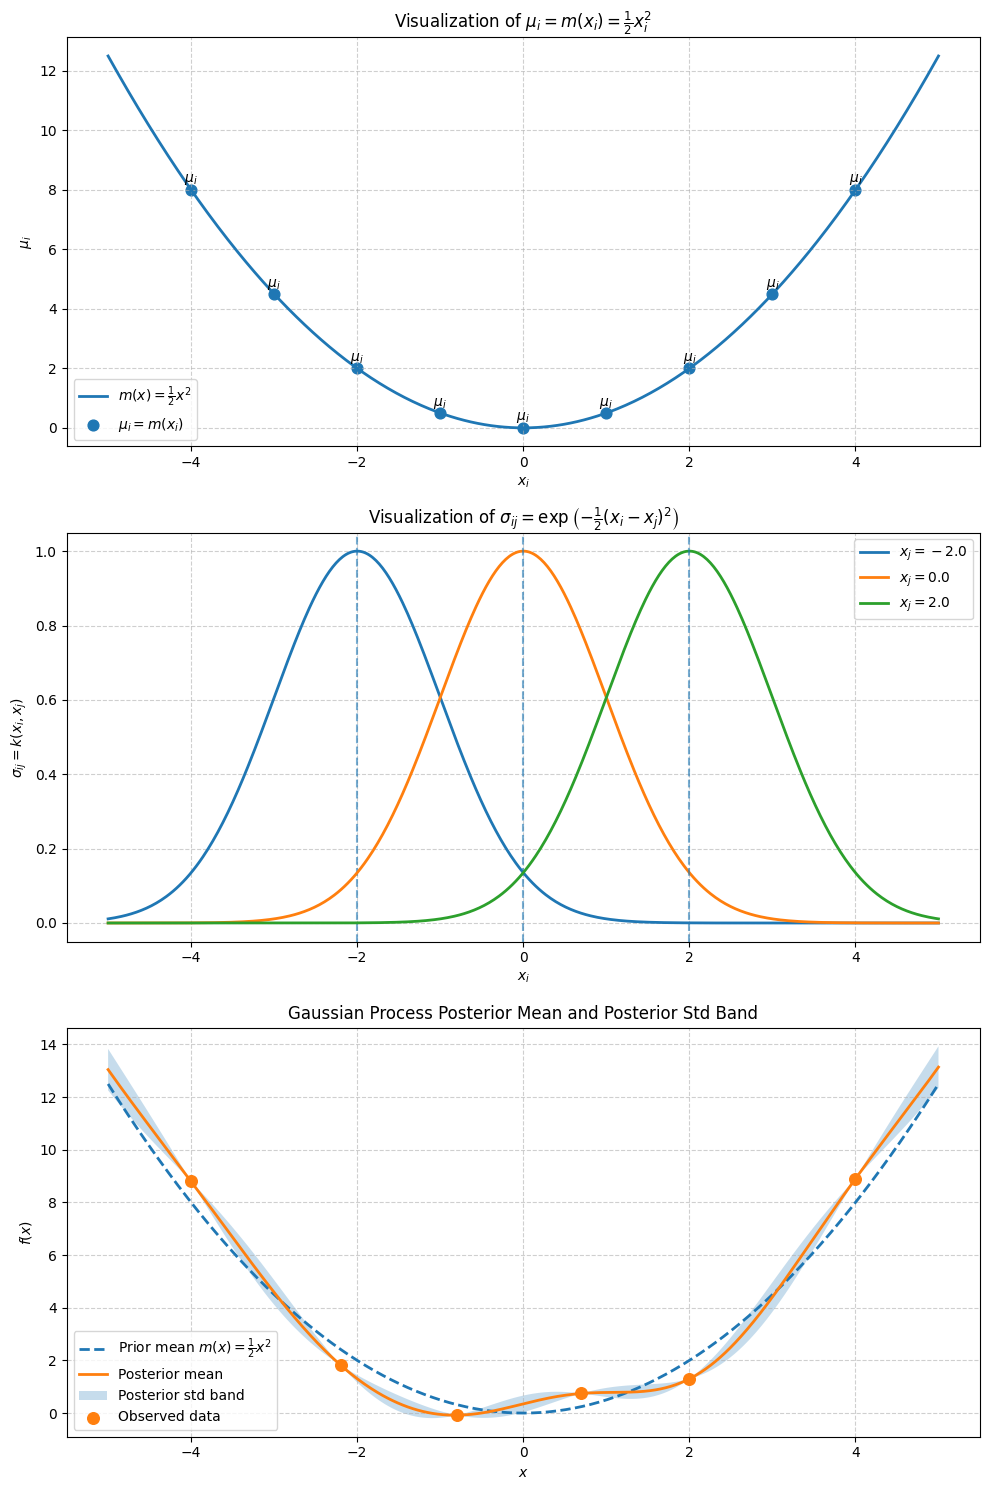

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Mean function
# m(x) = 0.5 * x^2
# ============================================================
def mean_function(x):
    return 0.5 * x**2

# ============================================================
# 2. Covariance / kernel function
# k(x, x') = exp( -0.5 * (x - x')^2 )
# ============================================================
def kernel_function(x1, x2):
    x1 = np.atleast_1d(x1)
    x2 = np.atleast_1d(x2)
    return np.exp(-0.5 * (x1[:, None] - x2[None, :])**2)

# ============================================================
# 3. GP posterior computation
# posterior mean:
#   mu_post(x*) = m(x*) + K(x*,X)[K(X,X)+noise*I]^{-1}(y - m(X))
#
# posterior covariance:
#   cov_post(x*) = K(x*,x*) - K(x*,X)[K(X,X)+noise*I]^{-1}K(X,x*)
# ============================================================
def gp_posterior(x_train, y_train, x_test, noise=1e-6):
    # Prior mean
    m_train = mean_function(x_train)
    m_test = mean_function(x_test)

    # Kernel matrices
    K_xx = kernel_function(x_train, x_train) + noise * np.eye(len(x_train))
    K_xs = kernel_function(x_train, x_test)
    K_sx = kernel_function(x_test, x_train)
    K_ss = kernel_function(x_test, x_test)

    # Inverse
    K_xx_inv = np.linalg.inv(K_xx)

    # Posterior mean
    posterior_mean = m_test + K_sx @ K_xx_inv @ (y_train - m_train)

    # Posterior covariance
    posterior_cov = K_ss - K_sx @ K_xx_inv @ K_xs

    # Numerical stabilization
    posterior_var = np.clip(np.diag(posterior_cov), 0.0, None)
    posterior_std = np.sqrt(posterior_var)

    return posterior_mean, posterior_std

# ============================================================
# 4. Data for mean-function visualization
# ============================================================
x_i_points = np.array([-4, -3, -2, -1, 0, 1, 2, 3, 4], dtype=float)
mu_i_points = mean_function(x_i_points)

x_dense = np.linspace(-5, 5, 500)
mu_dense = mean_function(x_dense)

# ============================================================
# 5. Data for covariance-entry visualization
# ============================================================
x_i_curve = np.linspace(-5, 5, 500)
x_j_list = [-2.0, 0.0, 2.0]

# ============================================================
# 6. Training data for GP posterior visualization
#    These are example observation points around the prior mean.
# ============================================================
x_train = np.array([-4.0, -2.2, -0.8, 0.7, 2.0, 4.0], dtype=float)

# You can modify these observed values freely.
# They do not need to lie exactly on the prior mean.
y_train = mean_function(x_train) + np.array([0.8, -0.6, -0.4, 0.5, -0.7, 0.9])

x_test = np.linspace(-5, 5, 500)

posterior_mean, posterior_std = gp_posterior(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    noise=1e-6
)

prior_mean_test = mean_function(x_test)

# ============================================================
# 7. Create one figure with three subplots
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# ============================================================
# [Top subplot] mu_i visualization
# ============================================================
axes[0].plot(
    x_dense,
    mu_dense,
    linewidth=2,
    label=r'$m(x)=\frac{1}{2}x^2$'
)

axes[0].scatter(
    x_i_points,
    mu_i_points,
    s=60,
    label=r'$\mu_i = m(x_i)$'
)

for x_val, mu_val in zip(x_i_points, mu_i_points):
    axes[0].text(
        x_val,
        mu_val + 0.25,
        r'$\mu_i$',
        ha='center',
        fontsize=10
    )

axes[0].set_xlabel(r'$x_i$')
axes[0].set_ylabel(r'$\mu_i$')
axes[0].set_title(r'Visualization of $\mu_i = m(x_i) = \frac{1}{2}x_i^2$')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# ============================================================
# [Middle subplot] sigma_ij visualization
# ============================================================
for x_j in x_j_list:
    sigma_ij = np.exp(-0.5 * (x_i_curve - x_j)**2)
    axes[1].plot(
        x_i_curve,
        sigma_ij,
        linewidth=2,
        label=rf'$x_j = {x_j}$'
    )
    axes[1].axvline(
        x=x_j,
        linestyle='--',
        alpha=0.6
    )

axes[1].set_xlabel(r'$x_i$')
axes[1].set_ylabel(r'$\sigma_{ij} = k(x_i, x_j)$')
axes[1].set_title(
    r'Visualization of $\sigma_{ij} = \exp\left(-\frac{1}{2}(x_i-x_j)^2\right)$'
)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# ============================================================
# [Bottom subplot] GP posterior mean + std band
# ============================================================
axes[2].plot(
    x_test,
    prior_mean_test,
    linestyle='--',
    linewidth=2,
    label=r'Prior mean $m(x)=\frac{1}{2}x^2$'
)

axes[2].plot(
    x_test,
    posterior_mean,
    linewidth=2,
    label='Posterior mean'
)

axes[2].fill_between(
    x_test,
    posterior_mean - posterior_std,
    posterior_mean + posterior_std,
    alpha=0.25,
    label='Posterior std band'
)

axes[2].scatter(
    x_train,
    y_train,
    s=70,
    zorder=3,
    label='Observed data'
)

axes[2].set_xlabel(r'$x$')
axes[2].set_ylabel(r'$f(x)$')
axes[2].set_title('Gaussian Process Posterior Mean and Posterior Std Band')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

# ============================================================
# 8. Layout and show
# ============================================================
plt.tight_layout()
plt.show()

f_best(x) = minimize problem
f_best : current best objective value
z : standardized improvement
Phi(z) : standard normal CDF
phi(z) : standard normal PDF
EI(x) : Expected Improvement

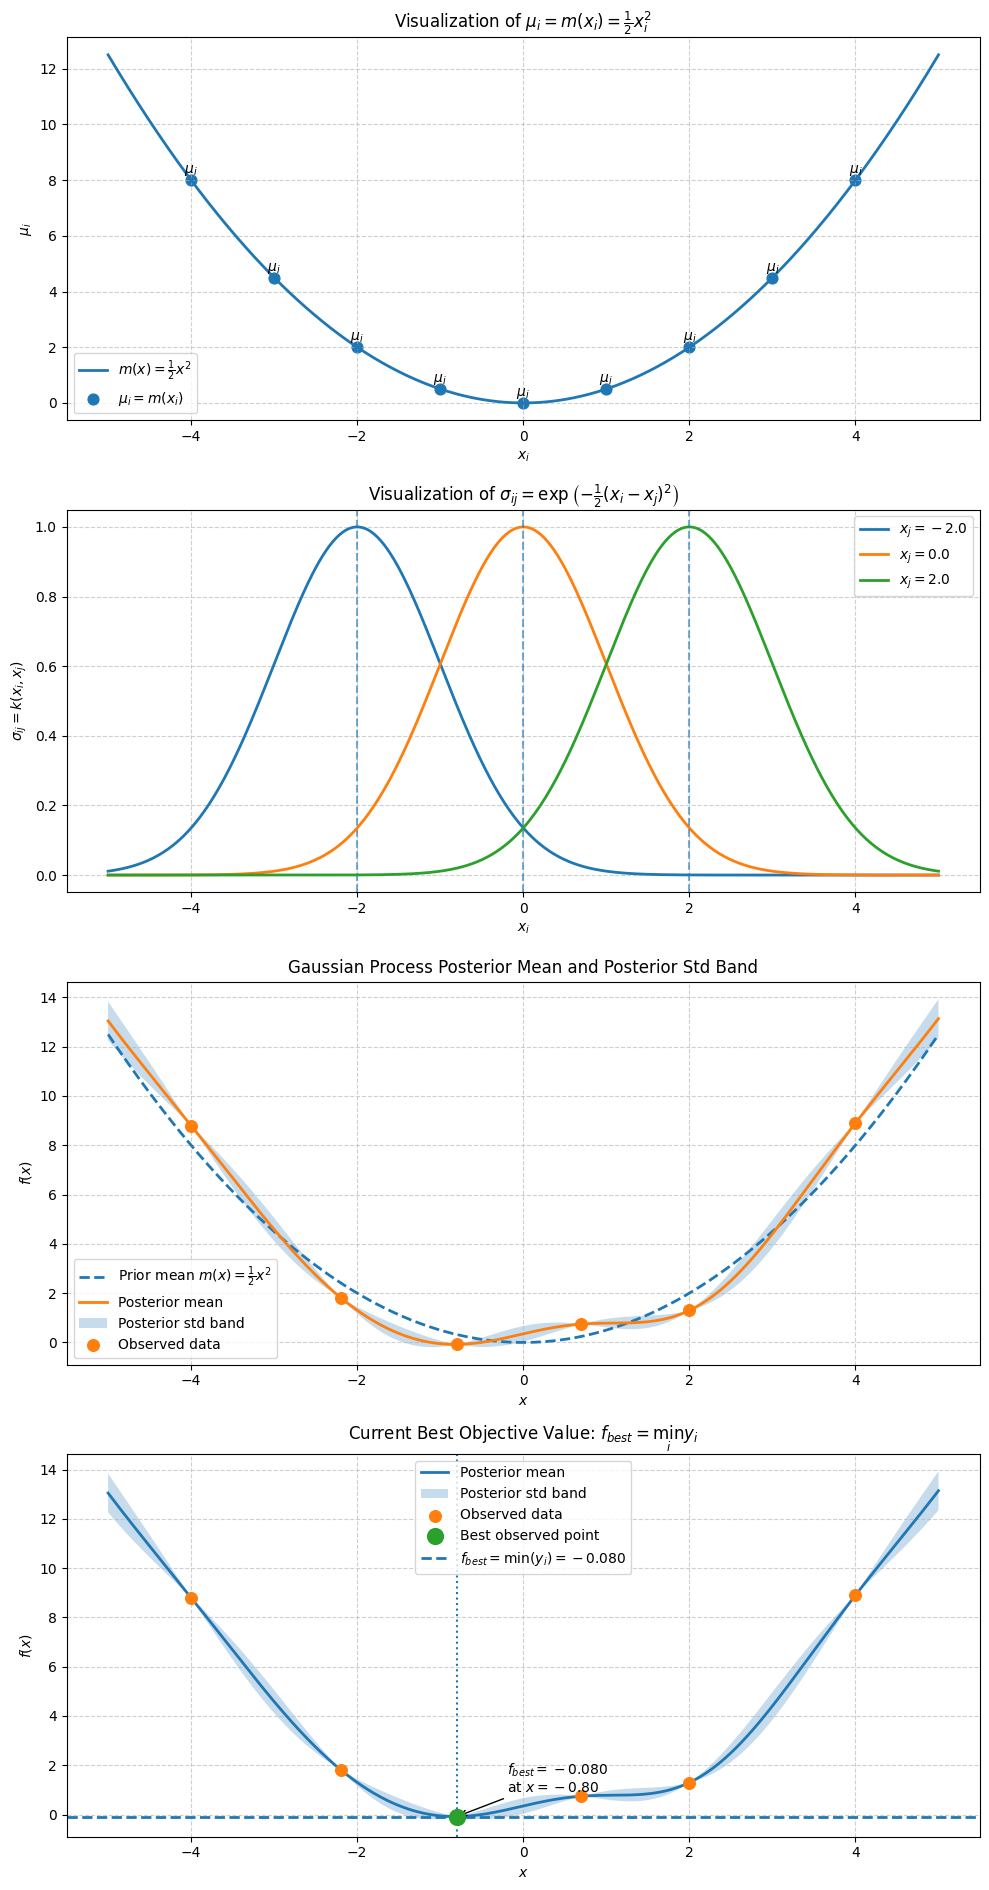

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Mean function
# m(x) = 0.5 * x^2
# ============================================================
def mean_function(x):
    return 0.5 * x**2

# ============================================================
# 2. Covariance / kernel function
# k(x, x') = exp( -0.5 * (x - x')^2 )
# ============================================================
def kernel_function(x1, x2):
    x1 = np.atleast_1d(x1)
    x2 = np.atleast_1d(x2)
    return np.exp(-0.5 * (x1[:, None] - x2[None, :])**2)

# ============================================================
# 3. GP posterior computation
# ============================================================
def gp_posterior(x_train, y_train, x_test, noise=1e-6):
    m_train = mean_function(x_train)
    m_test = mean_function(x_test)

    K_xx = kernel_function(x_train, x_train) + noise * np.eye(len(x_train))
    K_xs = kernel_function(x_train, x_test)
    K_sx = kernel_function(x_test, x_train)
    K_ss = kernel_function(x_test, x_test)

    K_xx_inv = np.linalg.inv(K_xx)

    posterior_mean = m_test + K_sx @ K_xx_inv @ (y_train - m_train)
    posterior_cov = K_ss - K_sx @ K_xx_inv @ K_xs

    posterior_var = np.clip(np.diag(posterior_cov), 0.0, None)
    posterior_std = np.sqrt(posterior_var)

    return posterior_mean, posterior_std

# ============================================================
# 4. Data for mean-function visualization
# ============================================================
x_i_points = np.array([-4, -3, -2, -1, 0, 1, 2, 3, 4], dtype=float)
mu_i_points = mean_function(x_i_points)

x_dense = np.linspace(-5, 5, 500)
mu_dense = mean_function(x_dense)

# ============================================================
# 5. Data for covariance-entry visualization
# ============================================================
x_i_curve = np.linspace(-5, 5, 500)
x_j_list = [-2.0, 0.0, 2.0]

# ============================================================
# 6. Training data for GP posterior visualization
# ============================================================
x_train = np.array([-4.0, -2.2, -0.8, 0.7, 2.0, 4.0], dtype=float)
y_train = mean_function(x_train) + np.array([0.8, -0.6, -0.4, 0.5, -0.7, 0.9])

x_test = np.linspace(-5, 5, 500)

posterior_mean, posterior_std = gp_posterior(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    noise=1e-6
)

prior_mean_test = mean_function(x_test)

# ============================================================
# 7. f_best calculation for minimization
# f_best = min_i y_i
# ============================================================
best_idx = np.argmin(y_train)
x_best = x_train[best_idx]
f_best = y_train[best_idx]

# ============================================================
# 8. Create one figure with four subplots
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(10, 19))

# ============================================================
# [1] mu_i visualization
# ============================================================
axes[0].plot(
    x_dense,
    mu_dense,
    linewidth=2,
    label=r'$m(x)=\frac{1}{2}x^2$'
)

axes[0].scatter(
    x_i_points,
    mu_i_points,
    s=60,
    label=r'$\mu_i = m(x_i)$'
)

for x_val, mu_val in zip(x_i_points, mu_i_points):
    axes[0].text(
        x_val,
        mu_val + 0.25,
        r'$\mu_i$',
        ha='center',
        fontsize=10
    )

axes[0].set_xlabel(r'$x_i$')
axes[0].set_ylabel(r'$\mu_i$')
axes[0].set_title(r'Visualization of $\mu_i = m(x_i) = \frac{1}{2}x_i^2$')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# ============================================================
# [2] sigma_ij visualization
# ============================================================
for x_j in x_j_list:
    sigma_ij = np.exp(-0.5 * (x_i_curve - x_j)**2)
    axes[1].plot(
        x_i_curve,
        sigma_ij,
        linewidth=2,
        label=rf'$x_j = {x_j}$'
    )
    axes[1].axvline(
        x=x_j,
        linestyle='--',
        alpha=0.6
    )

axes[1].set_xlabel(r'$x_i$')
axes[1].set_ylabel(r'$\sigma_{ij} = k(x_i, x_j)$')
axes[1].set_title(
    r'Visualization of $\sigma_{ij} = \exp\left(-\frac{1}{2}(x_i-x_j)^2\right)$'
)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# ============================================================
# [3] GP posterior mean + std band
# ============================================================
axes[2].plot(
    x_test,
    prior_mean_test,
    linestyle='--',
    linewidth=2,
    label=r'Prior mean $m(x)=\frac{1}{2}x^2$'
)

axes[2].plot(
    x_test,
    posterior_mean,
    linewidth=2,
    label='Posterior mean'
)

axes[2].fill_between(
    x_test,
    posterior_mean - posterior_std,
    posterior_mean + posterior_std,
    alpha=0.25,
    label='Posterior std band'
)

axes[2].scatter(
    x_train,
    y_train,
    s=70,
    zorder=3,
    label='Observed data'
)

axes[2].set_xlabel(r'$x$')
axes[2].set_ylabel(r'$f(x)$')
axes[2].set_title('Gaussian Process Posterior Mean and Posterior Std Band')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

# ============================================================
# [4] f_best visualization
# ============================================================
axes[3].plot(
    x_test,
    posterior_mean,
    linewidth=2,
    label='Posterior mean'
)

axes[3].fill_between(
    x_test,
    posterior_mean - posterior_std,
    posterior_mean + posterior_std,
    alpha=0.25,
    label='Posterior std band'
)

axes[3].scatter(
    x_train,
    y_train,
    s=70,
    zorder=3,
    label='Observed data'
)

axes[3].scatter(
    x_best,
    f_best,
    s=130,
    zorder=4,
    label='Best observed point'
)

axes[3].axhline(
    y=f_best,
    linestyle='--',
    linewidth=2,
    label=rf'$f_{{best}} = \min(y_i) = {f_best:.3f}$'
)

axes[3].axvline(
    x=x_best,
    linestyle=':',
    linewidth=1.5
)

axes[3].annotate(
    rf'$f_{{best}}={f_best:.3f}$' + '\n' + rf'at $x={x_best:.2f}$',
    xy=(x_best, f_best),
    xytext=(x_best + 0.6, f_best + 1.0),
    arrowprops=dict(arrowstyle='->'),
    fontsize=10
)

axes[3].set_xlabel(r'$x$')
axes[3].set_ylabel(r'$f(x)$')
axes[3].set_title(r'Current Best Objective Value: $f_{best} = \min_i y_i$')
axes[3].grid(True, linestyle='--', alpha=0.6)
axes[3].legend()

# ============================================================
# 9. Layout and show
# ============================================================
plt.tight_layout()
plt.show()

# 6. Standardized improvement
# z(x) = (f_best - mu(x)) / sigma(x)

phi(z)는 표준정규분포의 확률밀도함수입니다.

𝜙
(
𝑧
)
=
1
2
𝜋
exp
⁡
(
−
𝑧
2
2
)
ϕ(z)=
2π
	​

1
	​

exp(−
2
z
2
	​

)

그리고 Phi(z)는 표준정규분포의 누적분포함수입니다.

Φ
(
𝑧
)
=
∫
−
∞
𝑧
𝜙
(
𝑡
)
 
𝑑
𝑡
Φ(z)=∫
−∞
z
	​

ϕ(t)dt

Observed data
→ GP posterior mean, posterior std
→ f_best 계산
→ z(x) = (f_best - mu(x)) / sigma(x)
→ phi(z), Phi(z) 해석

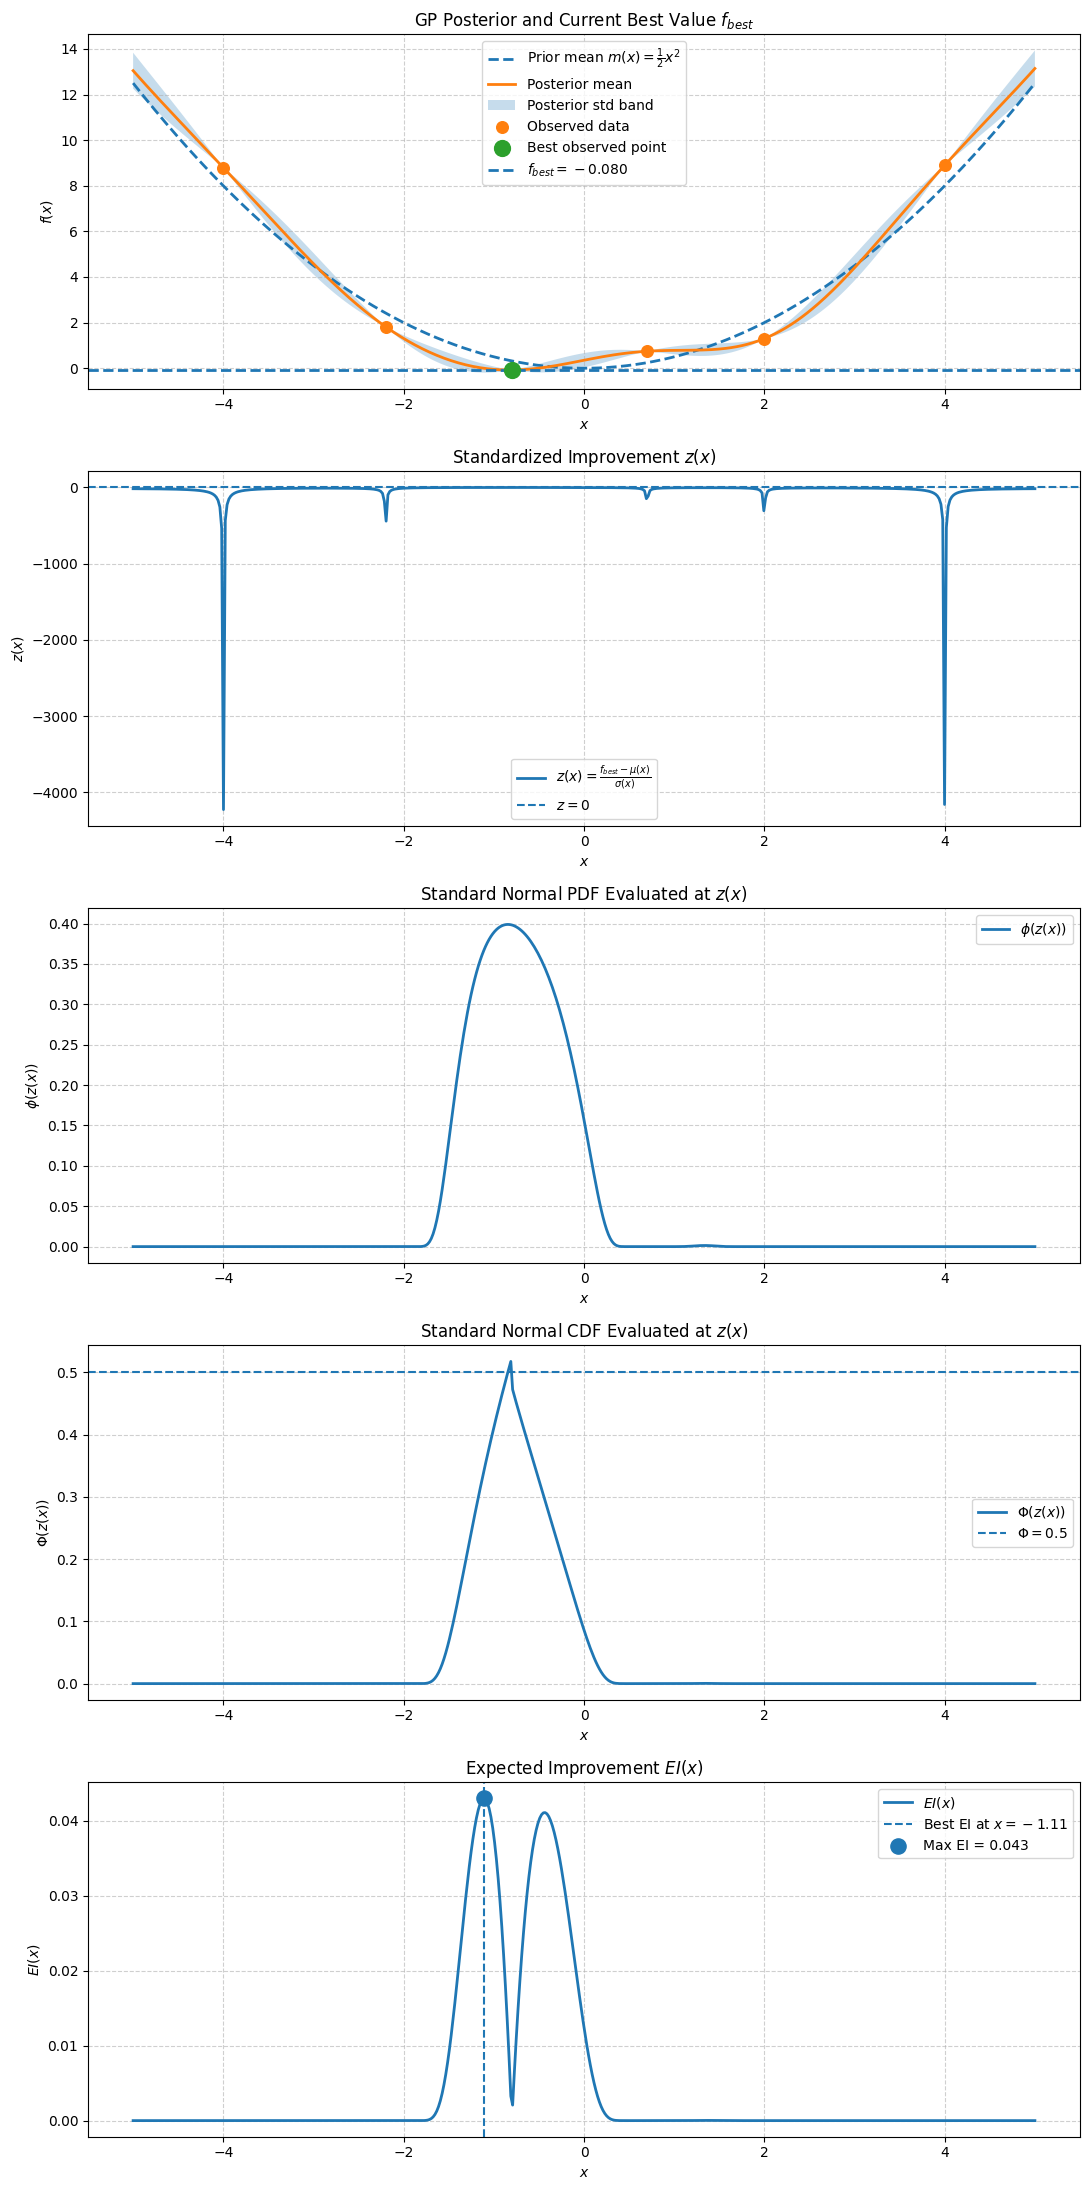

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf

# ============================================================
# 1. Mean function
# m(x) = 0.5 * x^2
# ============================================================
def mean_function(x):
    return 0.5 * x**2

# ============================================================
# 2. Covariance / kernel function
# k(x, x') = exp( -0.5 * (x - x')^2 )
# ============================================================
def kernel_function(x1, x2):
    x1 = np.atleast_1d(x1)
    x2 = np.atleast_1d(x2)
    return np.exp(-0.5 * (x1[:, None] - x2[None, :])**2)

# ============================================================
# 3. GP posterior computation
# ============================================================
def gp_posterior(x_train, y_train, x_test, noise=1e-6):
    m_train = mean_function(x_train)
    m_test = mean_function(x_test)

    K_xx = kernel_function(x_train, x_train) + noise * np.eye(len(x_train))
    K_xs = kernel_function(x_train, x_test)
    K_sx = kernel_function(x_test, x_train)
    K_ss = kernel_function(x_test, x_test)

    K_xx_inv = np.linalg.inv(K_xx)

    posterior_mean = m_test + K_sx @ K_xx_inv @ (y_train - m_train)
    posterior_cov = K_ss - K_sx @ K_xx_inv @ K_xs

    posterior_var = np.clip(np.diag(posterior_cov), 0.0, None)
    posterior_std = np.sqrt(posterior_var)

    return posterior_mean, posterior_std

# ============================================================
# 4. Standard normal PDF / CDF
# ============================================================
def phi(z):
    return (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * z**2)

def Phi(z):
    z = np.asarray(z)
    return 0.5 * (1.0 + np.vectorize(erf)(z / np.sqrt(2.0)))

# ============================================================
# 5. Expected Improvement for minimization
# EI(x) = (f_best - mu(x)) Phi(z) + sigma(x) phi(z)
# ============================================================
def expected_improvement(mu, sigma, f_best):
    sigma_safe = np.maximum(sigma, 1e-12)
    z = (f_best - mu) / sigma_safe
    ei = (f_best - mu) * Phi(z) + sigma_safe * phi(z)
    return ei, z

# ============================================================
# 6. Example observed data
# ============================================================
x_train = np.array([-4.0, -2.2, -0.8, 0.7, 2.0, 4.0], dtype=float)
y_train = mean_function(x_train) + np.array([0.8, -0.6, -0.4, 0.5, -0.7, 0.9])

x_test = np.linspace(-5, 5, 500)

posterior_mean, posterior_std = gp_posterior(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    noise=1e-6
)

prior_mean_test = mean_function(x_test)

# ============================================================
# 7. Current best objective value for minimization
# ============================================================
best_idx = np.argmin(y_train)
x_best = x_train[best_idx]
f_best = y_train[best_idx]

# ============================================================
# 8. z(x), phi(z(x)), Phi(z(x)), EI(x)
# ============================================================
ei_values, z_values = expected_improvement(
    mu=posterior_mean,
    sigma=posterior_std,
    f_best=f_best
)

phi_of_zx = phi(z_values)
Phi_of_zx = Phi(z_values)

# Candidate suggested by EI
ei_best_idx = np.argmax(ei_values)
x_ei_best = x_test[ei_best_idx]
ei_best = ei_values[ei_best_idx]

# ============================================================
# 9. Plot
# ============================================================
fig, axes = plt.subplots(5, 1, figsize=(11, 22))

# ------------------------------------------------------------
# [1] GP posterior mean + std band + f_best
# ------------------------------------------------------------
axes[0].plot(
    x_test,
    prior_mean_test,
    linestyle='--',
    linewidth=2,
    label=r'Prior mean $m(x)=\frac{1}{2}x^2$'
)

axes[0].plot(
    x_test,
    posterior_mean,
    linewidth=2,
    label='Posterior mean'
)

axes[0].fill_between(
    x_test,
    posterior_mean - posterior_std,
    posterior_mean + posterior_std,
    alpha=0.25,
    label='Posterior std band'
)

axes[0].scatter(
    x_train,
    y_train,
    s=70,
    zorder=3,
    label='Observed data'
)

axes[0].scatter(
    x_best,
    f_best,
    s=130,
    zorder=4,
    label='Best observed point'
)

axes[0].axhline(
    y=f_best,
    linestyle='--',
    linewidth=2,
    label=rf'$f_{{best}} = {f_best:.3f}$'
)

axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$f(x)$')
axes[0].set_title(r'GP Posterior and Current Best Value $f_{best}$')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# ------------------------------------------------------------
# [2] z(x)
# ------------------------------------------------------------
axes[1].plot(
    x_test,
    z_values,
    linewidth=2,
    label=r'$z(x)=\frac{f_{best}-\mu(x)}{\sigma(x)}$'
)

axes[1].axhline(
    y=0.0,
    linestyle='--',
    linewidth=1.5,
    label=r'$z=0$'
)

axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r'$z(x)$')
axes[1].set_title(r'Standardized Improvement $z(x)$')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# ------------------------------------------------------------
# [3] phi(z(x))
# ------------------------------------------------------------
axes[2].plot(
    x_test,
    phi_of_zx,
    linewidth=2,
    label=r'$\phi(z(x))$'
)

axes[2].set_xlabel(r'$x$')
axes[2].set_ylabel(r'$\phi(z(x))$')
axes[2].set_title(r'Standard Normal PDF Evaluated at $z(x)$')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

# ------------------------------------------------------------
# [4] Phi(z(x))
# ------------------------------------------------------------
axes[3].plot(
    x_test,
    Phi_of_zx,
    linewidth=2,
    label=r'$\Phi(z(x))$'
)

axes[3].axhline(
    y=0.5,
    linestyle='--',
    linewidth=1.5,
    label=r'$\Phi=0.5$'
)

axes[3].set_xlabel(r'$x$')
axes[3].set_ylabel(r'$\Phi(z(x))$')
axes[3].set_title(r'Standard Normal CDF Evaluated at $z(x)$')
axes[3].grid(True, linestyle='--', alpha=0.6)
axes[3].legend()

# ------------------------------------------------------------
# [5] EI(x)
# ------------------------------------------------------------
axes[4].plot(
    x_test,
    ei_values,
    linewidth=2,
    label=r'$EI(x)$'
)

axes[4].axvline(
    x=x_ei_best,
    linestyle='--',
    linewidth=1.5,
    label=rf'Best EI at $x={x_ei_best:.2f}$'
)

axes[4].scatter(
    x_ei_best,
    ei_best,
    s=120,
    zorder=4,
    label=rf'Max EI = {ei_best:.3f}'
)

axes[4].set_xlabel(r'$x$')
axes[4].set_ylabel(r'$EI(x)$')
axes[4].set_title(r'Expected Improvement $EI(x)$')
axes[4].grid(True, linestyle='--', alpha=0.6)
axes[4].legend()

plt.tight_layout()
plt.show()

현재 observed data (x_train, y_train)
→ GP posterior 업데이트
→ posterior mean, posterior std 계산
→ f_best 계산
→ z(x) 계산
→ Phi(z), phi(z) 계산
→ EI(x) 계산
→ EI가 최대인 다음 후보 x_next 선택

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf

# ============================================================
# 1. Standard normal PDF
# phi(z) = 1/sqrt(2*pi) * exp(-z^2 / 2)
# ============================================================
def phi(z):
    return (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * z**2)

# ============================================================
# 2. Standard normal CDF
# Phi(z) = 0.5 * [1 + erf(z / sqrt(2))]
# ============================================================
def Phi(z):
    z = np.asarray(z)
    return 0.5 * (1.0 + np.vectorize(erf)(z / np.sqrt(2.0)))

# ============================================================
# 3. z range
# ============================================================
z = np.linspace(-4, 4, 500)

phi_vals = phi(z)
Phi_vals = Phi(z)

# ============================================================
# 4. Plot
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(9, 10))

# ------------------------------------------------------------
# [Top] phi(z): standard normal PDF
# ------------------------------------------------------------
axes[0].plot(
    z,
    phi_vals,
    linewidth=2,
    label=r'$\phi(z)=\frac{1}{\sqrt{2\pi}}e^{-z^2/2}$'
)

axes[0].axvline(x=0.0, linestyle='--', linewidth=1.5)
axes[0].set_xlabel(r'$z$')
axes[0].set_ylabel(r'$\phi(z)$')
axes[0].set_title(r'Standard Normal PDF $\phi(z)$')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# ------------------------------------------------------------
# [Bottom] Phi(z): standard normal CDF
# ------------------------------------------------------------
axes[1].plot(
    z,
    Phi_vals,
    linewidth=2,
    label=r'$\Phi(z)=\int_{-\infty}^{z}\phi(t)\,dt$'
)

axes[1].axvline(x=0.0, linestyle='--', linewidth=1.5)
axes[1].axhline(y=0.5, linestyle='--', linewidth=1.5)
axes[1].set_xlabel(r'$z$')
axes[1].set_ylabel(r'$\Phi(z)$')
axes[1].set_title(r'Standard Normal CDF $\Phi(z)$')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# ────────────────────────────────────────────────────────────────
# (A) BO objective : dimensionless decay index λ*
#       candidate  = (μ, σ, ρ, c, p_level, t_us, wave_id)
#       returns    = float (smaller is better)
# ────────────────────────────────────────────────────────────────
import numpy as np
import torch

def bo_objective(candidate,
                 model,
                 wave_db,
                 device: torch.device = torch.device("cpu")) -> float:
    """
    Parameters
    ----------
    candidate : tuple
        (mu, sigma, rho, c_val, t_us, wave_id)
    model     : torch.nn.Module
        Trained DeepONet that maps (x1, x2) -> q̂
    wave_db   : dict
        Mapping  wave_id -> (300,) numpy array of the driving waveform
    device    : torch.device
        CUDA / CPU device on which to run the model

    Returns
    -------
    float
        λ*  (more-negative ⇒ faster decay).  Raises if waveform or index is invalid.
    """
    # ── unpack candidate tuple ───────────────────────────────────────
    mu, sigma, rho, c_val, t_us, wid = candidate

    # ── fetch waveform & sanity-check ────────────────────────────────
    try:
        wave = wave_db[wid]
    except KeyError as e:
        raise KeyError(f"wave_id '{wid}' not found in wave_db") from e
    if wave.shape[0] != 300:
        raise ValueError("waveform length must be exactly 300")

    # ── build DeepONet inputs ───────────────────────────────────────
    x1_np = np.array([mu, sigma, rho, c_val, t_us],
                     dtype=np.float32)           # (6,)
    x2_np = wave.astype(np.float32)              # (300,)

    x1 = torch.from_numpy(x1_np).unsqueeze(0).to(device)  # (1, 6)
    x2 = torch.from_numpy(x2_np).unsqueeze(0).to(device)  # (1, 300)

    # ── forward pass ────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        q_hat = model(x1, x2).squeeze(0)         # (300,)

    # ── compute λ*  (= ln(r_fin / r_pinch)) ─────────────────────────
    idx_pinch = int(t_us) - 1                    # 0-based
    if not 0 <= idx_pinch < 300:
        raise ValueError("t_us must map to an index between 1 and 300")

    r_pinch = q_hat[idx_pinch].abs() + 1e-12     # avoid log(0)
    r_fin   = q_hat[-1].abs()       + 1e-12
    lam_star = torch.log(r_fin / r_pinch).item()

    return lam_star


# ────────────────────────────────────────────────────────────────
# (B) Expected Improvement (EI) for minimisation
#       μ, σ : GP posterior mean / std  (same tensor shape)
#       f_best: current best observed objective value
# ────────────────────────────────────────────────────────────────
import torch.distributions as D

def expected_improvement(mu: torch.Tensor,
                         sigma: torch.Tensor,
                         f_best: float) -> torch.Tensor:
    """
    EI(x) = (f_best - μ) Φ(z) + σ φ(z) ,
    z = (f_best - μ) / σ .
    Larger EI values indicate better candidates.

    Parameters
    ----------
    mu : torch.Tensor
        Posterior mean at candidate points.
    sigma : torch.Tensor
        Posterior standard deviation at candidate points.
    f_best : float
        Current minimum observed objective value.

    Returns
    -------
    torch.Tensor
        Expected Improvement for each candidate (same shape as μ).
    """
    sigma = sigma.clamp_min(1e-9)                 # avoid division by zero
    z = (f_best - mu) / sigma

    normal = D.Normal(torch.zeros_like(mu), torch.ones_like(mu))
    Phi = normal.cdf(z)                           # Φ(z)
    phi = torch.exp(normal.log_prob(z))           # φ(z)

    ei = (f_best - mu) * Phi + sigma * phi
    return ei


In [10]:
rows = [
    #  μ     σ      ρ     c       t_us wave_id
    (15.76, 0.0474, 1114, 1679.5, 120, "v24"),
    (15.76, 0.0474, 1114, 1679.5, 121, "v26"),
    (15.76, 0.0474, 1114, 1679.5, 122, "v28"),
    (15.76, 0.0474, 1114, 1679.5, 123, "v30"),
    (15.76, 0.0474, 1114, 1679.5, 124, "v32"),
    (15.76, 0.0474, 1114, 1679.5, 125, "v34"),
    (15.76, 0.0474, 1114, 1679.5, 126, "v36"),
    (15.76, 0.0474, 1114, 1679.5, 127, "v38"),
    (15.76, 0.0474, 1114, 1679.5, 128, "v40"),
]
wave_ids = [r[-1] for r in rows]

lam_list = [bo_objective(cand, model, WAVE_DB, DEVICE) for cand in rows]

# 최소값과 대응 파라미터 가져오기
idx_min   = int(np.argmin(lam_list))
best_row  = rows[idx_min]
best_lam  = lam_list[idx_min]

print(f"λ* 최소 = {best_lam:+.3e}  →  {best_row}")

λ* 최소 = -4.123e+00  →  (15.76, 0.0474, 1114, 1679.5, 120, 'v24')


In [11]:
for cand, lam in zip(rows, lam_list):
    print(f"{cand[-1]} @ t={cand[5]} µs  →  λ*={lam:+.3e}")

v24 @ t=v24 µs  →  λ*=-4.123e+00
v26 @ t=v26 µs  →  λ*=-3.817e+00
v28 @ t=v28 µs  →  λ*=-2.952e+00
v30 @ t=v30 µs  →  λ*=-2.529e+00
v32 @ t=v32 µs  →  λ*=-2.218e+00
v34 @ t=v34 µs  →  λ*=-1.947e+00
v36 @ t=v36 µs  →  λ*=-1.702e+00
v38 @ t=v38 µs  →  λ*=-1.478e+00
v40 @ t=v40 µs  →  λ*=-1.283e+00


[Comp μ=15.76, σ=0.0474, ρ=1114, c=1688.0] min λ*=-4.197e+00 @ V=24 (wave=v24)
[Comp μ=10.52, σ=0.0497, ρ=1101, c=1688.0] min λ*=-5.570e+00 @ V=24 (wave=v24)
[Comp μ=6.46, σ=0.0521, ρ=1081, c=1709.38] min λ*=-5.794e+00 @ V=24 (wave=v24)
[Comp μ=4.95, σ=0.0539, ρ=1070, c=1707.98] min λ*=-5.923e+00 @ V=24 (wave=v24)
[Comp μ=4.12, σ=0.0551, ρ=1072, c=1703.27] min λ*=-6.591e+00 @ V=24 (wave=v24)
[Comp μ=3.07, σ=0.0565, ρ=1056, c=1683.21] min λ*=-6.612e+00 @ V=24 (wave=v24)


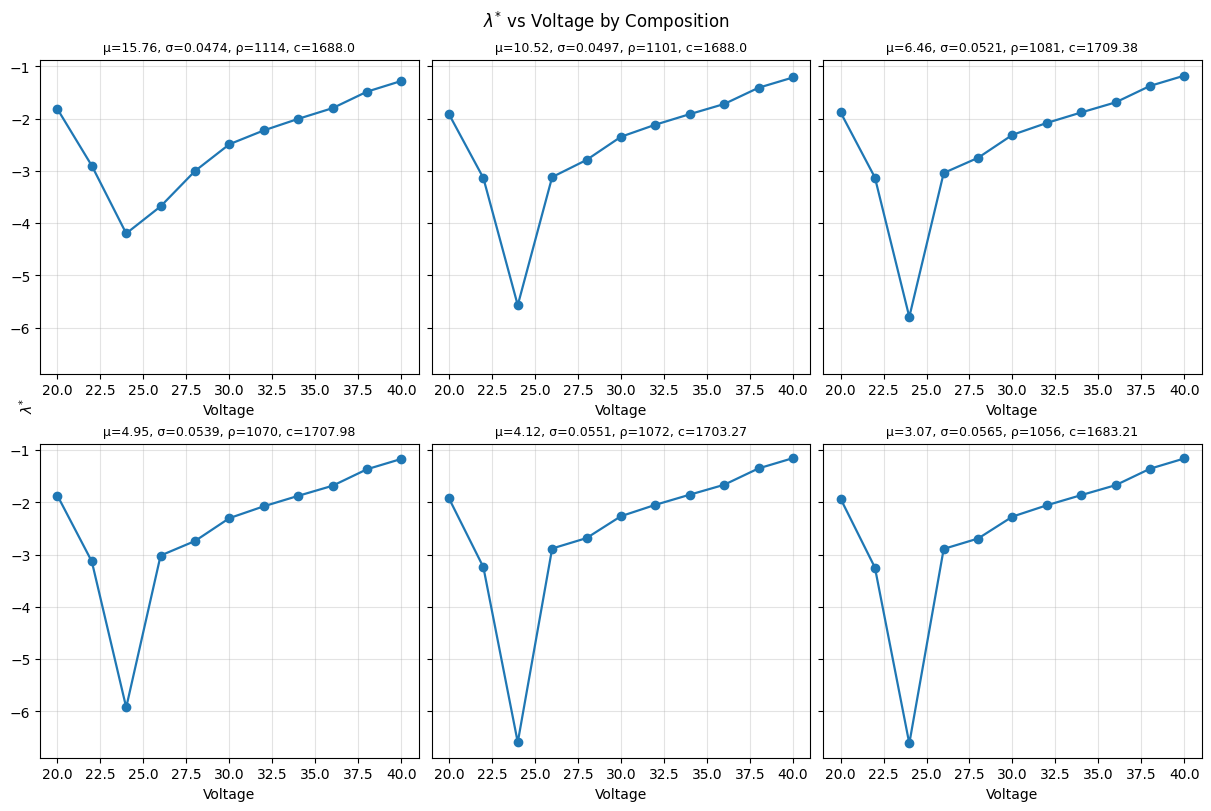

In [12]:
import io, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# 1) 제공된 표 데이터를 그대로 사용 (Dummy data 아님)
# ─────────────────────────────────────────────────────────────
data_str = """mu	sigma	rho	c	t	V_name
15.76	0.0474	1114	1688	118	v20
15.76	0.0474	1114	1688	121	v22
15.76	0.0474	1114	1688	122	v24
15.76	0.0474	1114	1688	130	v26
15.76	0.0474	1114	1688	123	v28
15.76	0.0474	1114	1688	122	v30
15.76	0.0474	1114	1688	123	v32
15.76	0.0474	1114	1688	123	v34
15.76	0.0474	1114	1688	122	v36
15.76	0.0474	1114	1688	120	v38
15.76	0.0474	1114	1688	128	v40
10.52	0.0497	1101	1688	118	v20
10.52	0.0497	1101	1688	121	v22
10.52	0.0497	1101	1688	122	v24
10.52	0.0497	1101	1688	130	v26
10.52	0.0497	1101	1688	123	v28
10.52	0.0497	1101	1688	122	v30
10.52	0.0497	1101	1688	123	v32
10.52	0.0497	1101	1688	123	v34
10.52	0.0497	1101	1688	122	v36
10.52	0.0497	1101	1688	120	v38
10.52	0.0497	1101	1688	128	v40
6.46	0.0521	1081	1709.38	118	v20
6.46	0.0521	1081	1709.38	121	v22
6.46	0.0521	1081	1709.38	122	v24
6.46	0.0521	1081	1709.38	130	v26
6.46	0.0521	1081	1709.38	123	v28
6.46	0.0521	1081	1709.38	122	v30
6.46	0.0521	1081	1709.38	123	v32
6.46	0.0521	1081	1709.38	123	v34
6.46	0.0521	1081	1709.38	122	v36
6.46	0.0521	1081	1709.38	120	v38
6.46	0.0521	1081	1709.38	128	v40
4.95	0.0539	1070	1707.98	118	v20
4.95	0.0539	1070	1707.98	121	v22
4.95	0.0539	1070	1707.98	122	v24
4.95	0.0539	1070	1707.98	130	v26
4.95	0.0539	1070	1707.98	123	v28
4.95	0.0539	1070	1707.98	122	v30
4.95	0.0539	1070	1707.98	123	v32
4.95	0.0539	1070	1707.98	123	v34
4.95	0.0539	1070	1707.98	122	v36
4.95	0.0539	1070	1707.98	120	v38
4.95	0.0539	1070	1707.98	128	v40
4.12	0.0551	1072	1703.27	118	v20
4.12	0.0551	1072	1703.27	121	v22
4.12	0.0551	1072	1703.27	122	v24
4.12	0.0551	1072	1703.27	130	v26
4.12	0.0551	1072	1703.27	123	v28
4.12	0.0551	1072	1703.27	122	v30
4.12	0.0551	1072	1703.27	123	v32
4.12	0.0551	1072	1703.27	123	v34
4.12	0.0551	1072	1703.27	122	v36
4.12	0.0551	1072	1703.27	120	v38
4.12	0.0551	1072	1703.27	128	v40
3.07	0.0565	1056	1683.21	118	v20
3.07	0.0565	1056	1683.21	121	v22
3.07	0.0565	1056	1683.21	122	v24
3.07	0.0565	1056	1683.21	130	v26
3.07	0.0565	1056	1683.21	123	v28
3.07	0.0565	1056	1683.21	122	v30
3.07	0.0565	1056	1683.21	123	v32
3.07	0.0565	1056	1683.21	123	v34
3.07	0.0565	1056	1683.21	122	v36
3.07	0.0565	1056	1683.21	120	v38
3.07	0.0565	1056	1683.21	128	v40
"""
df = pd.read_csv(io.StringIO(data_str), sep=r"\s+")

# 전압 숫자 추출
def parse_voltage(vname: str) -> int:
    m = re.search(r"(\d+)", str(vname))
    if not m:
        raise ValueError(f"Invalid V_name: {vname}")
    return int(m.group(1))

df["Voltage"] = df["V_name"].map(parse_voltage)

# 조성별 그룹핑
group_keys = ["mu", "sigma", "rho", "c"]
groups = list(df.groupby(group_keys, sort=False))

# ─────────────────────────────────────────────────────────────
# 2) 플롯: 2×3 서브플롯, y축 라벨은 fig.text 로 중앙 배치
#    bo_objective, model, WAVE_DB, DEVICE 는 사용자 환경에 정의되어 있어야 함
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharey=True, constrained_layout=True)
axes = axes.ravel()

for ax, (comp, g) in zip(axes, groups):
    g_sorted = g.sort_values("Voltage")

    # rows: (mu, sigma, rho, c, t, V_name)
    rows = [(float(comp[0]), float(comp[1]), float(comp[2]), float(comp[3]),
             float(t), str(vn)) for t, vn in zip(g_sorted["t"], g_sorted["V_name"])]

    # λ* 계산
    lam_list = [bo_objective(cand, model, WAVE_DB, DEVICE) for cand in rows]
    volts    = g_sorted["Voltage"].to_numpy()

    # 플롯
    ax.plot(volts, lam_list, marker="o", linewidth=1.6)
    ax.set_xlabel("Voltage")
    ax.grid(True, alpha=0.35)
    ax.set_title(f"μ={comp[0]}, σ={comp[1]}, ρ={comp[2]}, c={comp[3]}", fontsize=9)

    # 콘솔로 각 조성의 최소값 보고
    idx_min = int(np.argmin(lam_list))
    print(f"[Comp μ={comp[0]}, σ={comp[1]}, ρ={comp[2]}, c={comp[3]}] "
          f"min λ*={lam_list[idx_min]:+.3e} @ V={volts[idx_min]} (wave={rows[idx_min][-1]})")

# 공통 Y라벨(요청: fig.text 사용)
fig.text(0.01, 0.5, r"$\lambda^{*}$", va="center", rotation=90)
fig.suptitle(r"$\lambda^{*}$ vs Voltage by Composition", fontsize=12)

plt.show()


[Comp μ=15.76, σ=0.0474, ρ=1114, c=1688.0] min λ*=-4.197e+00 @ V=24 (wave=v24)
[Comp μ=10.52, σ=0.0497, ρ=1101, c=1688.0] min λ*=-5.570e+00 @ V=24 (wave=v24)
[Comp μ=6.46, σ=0.0521, ρ=1081, c=1709.38] min λ*=-5.794e+00 @ V=24 (wave=v24)
[Comp μ=4.95, σ=0.0539, ρ=1070, c=1707.98] min λ*=-5.923e+00 @ V=24 (wave=v24)
[Comp μ=4.12, σ=0.0551, ρ=1072, c=1703.27] min λ*=-6.591e+00 @ V=24 (wave=v24)
[Comp μ=3.07, σ=0.0565, ρ=1056, c=1683.21] min λ*=-6.612e+00 @ V=24 (wave=v24)


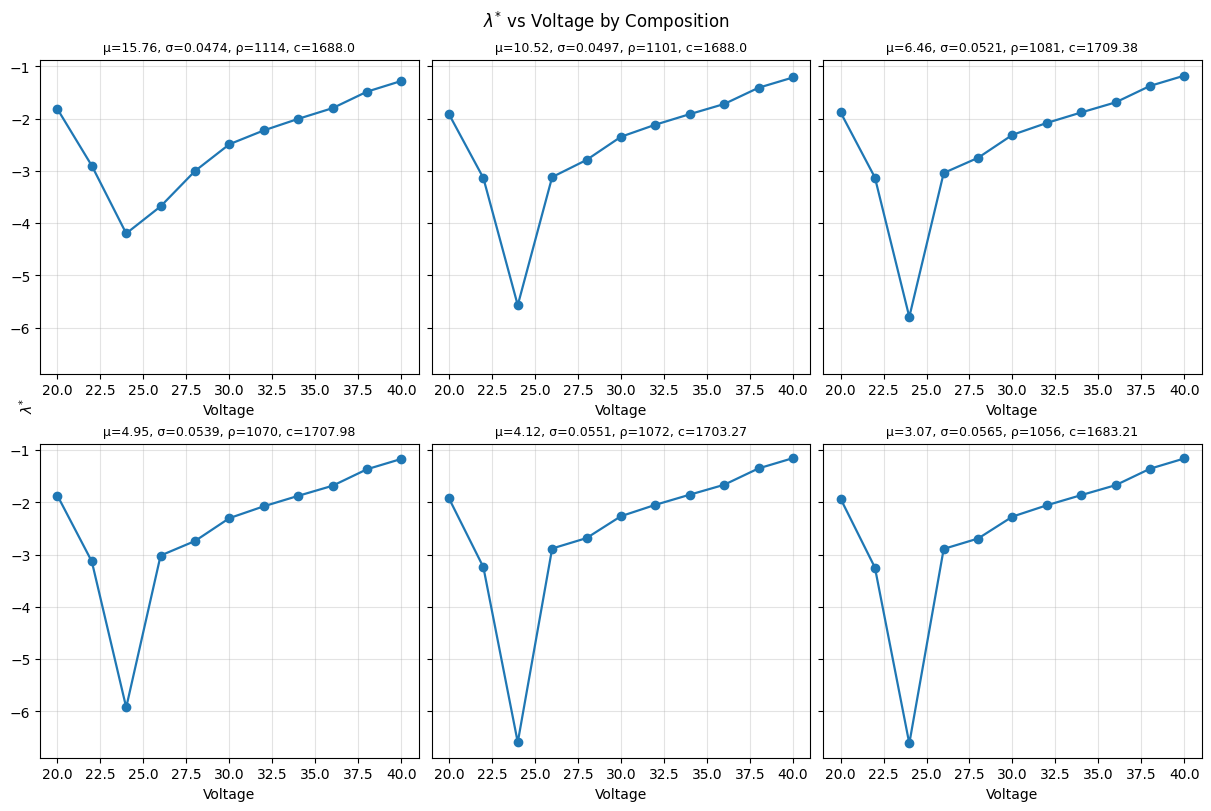

In [13]:
import io, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# 1) 제공된 표 데이터를 그대로 사용 (Dummy data 아님)
# ─────────────────────────────────────────────────────────────
data_str = """mu	sigma	rho	c	t	V_name
15.76	0.0474	1114	1688	118	v20
15.76	0.0474	1114	1688	121	v22
15.76	0.0474	1114	1688	122	v24
15.76	0.0474	1114	1688	130	v26
15.76	0.0474	1114	1688	123	v28
15.76	0.0474	1114	1688	122	v30
15.76	0.0474	1114	1688	123	v32
15.76	0.0474	1114	1688	123	v34
15.76	0.0474	1114	1688	122	v36
15.76	0.0474	1114	1688	120	v38
15.76	0.0474	1114	1688	128	v40
10.52	0.0497	1101	1688	118	v20
10.52	0.0497	1101	1688	121	v22
10.52	0.0497	1101	1688	122	v24
10.52	0.0497	1101	1688	130	v26
10.52	0.0497	1101	1688	123	v28
10.52	0.0497	1101	1688	122	v30
10.52	0.0497	1101	1688	123	v32
10.52	0.0497	1101	1688	123	v34
10.52	0.0497	1101	1688	122	v36
10.52	0.0497	1101	1688	120	v38
10.52	0.0497	1101	1688	128	v40
6.46	0.0521	1081	1709.38	118	v20
6.46	0.0521	1081	1709.38	121	v22
6.46	0.0521	1081	1709.38	122	v24
6.46	0.0521	1081	1709.38	130	v26
6.46	0.0521	1081	1709.38	123	v28
6.46	0.0521	1081	1709.38	122	v30
6.46	0.0521	1081	1709.38	123	v32
6.46	0.0521	1081	1709.38	123	v34
6.46	0.0521	1081	1709.38	122	v36
6.46	0.0521	1081	1709.38	120	v38
6.46	0.0521	1081	1709.38	128	v40
4.95	0.0539	1070	1707.98	118	v20
4.95	0.0539	1070	1707.98	121	v22
4.95	0.0539	1070	1707.98	122	v24
4.95	0.0539	1070	1707.98	130	v26
4.95	0.0539	1070	1707.98	123	v28
4.95	0.0539	1070	1707.98	122	v30
4.95	0.0539	1070	1707.98	123	v32
4.95	0.0539	1070	1707.98	123	v34
4.95	0.0539	1070	1707.98	122	v36
4.95	0.0539	1070	1707.98	120	v38
4.95	0.0539	1070	1707.98	128	v40
4.12	0.0551	1072	1703.27	118	v20
4.12	0.0551	1072	1703.27	121	v22
4.12	0.0551	1072	1703.27	122	v24
4.12	0.0551	1072	1703.27	130	v26
4.12	0.0551	1072	1703.27	123	v28
4.12	0.0551	1072	1703.27	122	v30
4.12	0.0551	1072	1703.27	123	v32
4.12	0.0551	1072	1703.27	123	v34
4.12	0.0551	1072	1703.27	122	v36
4.12	0.0551	1072	1703.27	120	v38
4.12	0.0551	1072	1703.27	128	v40
3.07	0.0565	1056	1683.21	118	v20
3.07	0.0565	1056	1683.21	121	v22
3.07	0.0565	1056	1683.21	122	v24
3.07	0.0565	1056	1683.21	130	v26
3.07	0.0565	1056	1683.21	123	v28
3.07	0.0565	1056	1683.21	122	v30
3.07	0.0565	1056	1683.21	123	v32
3.07	0.0565	1056	1683.21	123	v34
3.07	0.0565	1056	1683.21	122	v36
3.07	0.0565	1056	1683.21	120	v38
3.07	0.0565	1056	1683.21	128	v40
"""
df = pd.read_csv(io.StringIO(data_str), sep=r"\s+")

# 전압 숫자 추출
def parse_voltage(vname: str) -> int:
    m = re.search(r"(\d+)", str(vname))
    if not m:
        raise ValueError(f"Invalid V_name: {vname}")
    return int(m.group(1))

df["Voltage"] = df["V_name"].map(parse_voltage)

# 조성별 그룹핑
group_keys = ["mu", "sigma", "rho", "c"]
groups = list(df.groupby(group_keys, sort=False))

# ─────────────────────────────────────────────────────────────
# 2) 플롯: 2×3 서브플롯, y축 라벨은 fig.text 로 중앙 배치
#    bo_objective, model, WAVE_DB, DEVICE 는 사용자 환경에 정의되어 있어야 함
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharey=True, constrained_layout=True)
axes = axes.ravel()

# 시각화에 사용된 데이터 누적용 리스트
records = []

for ax, (comp, g) in zip(axes, groups):
    g_sorted = g.sort_values("Voltage")

    # rows: (mu, sigma, rho, c, t, V_name)
    rows = [(float(comp[0]), float(comp[1]), float(comp[2]), float(comp[3]),
             float(t), str(vn)) for t, vn in zip(g_sorted["t"], g_sorted["V_name"])]

    # λ* 계산
    lam_list = [bo_objective(cand, model, WAVE_DB, DEVICE) for cand in rows]
    volts    = g_sorted["Voltage"].to_numpy()

    # 플롯
    ax.plot(volts, lam_list, marker="o", linewidth=1.6)
    ax.set_xlabel("Voltage")
    ax.grid(True, alpha=0.35)
    ax.set_title(f"μ={comp[0]}, σ={comp[1]}, ρ={comp[2]}, c={comp[3]}", fontsize=9)

    # 콘솔로 각 조성의 최소값 보고
    idx_min = int(np.argmin(lam_list))
    print(f"[Comp μ={comp[0]}, σ={comp[1]}, ρ={comp[2]}, c={comp[3]}] "
          f"min λ*={lam_list[idx_min]:+.3e} @ V={volts[idx_min]} (wave={rows[idx_min][-1]})")

    # CSV 저장용 레코드 누적
    for lam, vol, row in zip(lam_list, volts, rows):
        records.append({
            "mu": comp[0], "sigma": comp[1], "rho": comp[2], "c": comp[3],
            "t": row[4], "V_name": row[5], "Voltage": int(vol),
            "lambda_star": float(lam)
        })

# 공통 Y라벨(요청: fig.text 사용)
fig.text(0.01, 0.5, r"$\lambda^{*}$", va="center", rotation=90)
fig.suptitle(r"$\lambda^{*}$ vs Voltage by Composition", fontsize=12)

# ─────────────────────────────────────────────────────────────
# 3) 시각화에 사용된 데이터 CSV로 저장
#    - 전체 곡선 데이터: lambda_vs_voltage_by_composition.csv
#    - 조성별 최소값 요약: lambda_min_by_composition.csv
# ─────────────────────────────────────────────────────────────
out_dir = os.path.join(os.getcwd(), "export_lambda")
os.makedirs(out_dir, exist_ok=True)

df_plot = pd.DataFrame.from_records(records)
df_plot = df_plot.sort_values(["mu", "sigma", "rho", "c", "Voltage"]).reset_index(drop=True)
df_plot.to_csv(os.path.join(out_dir, "lambda_vs_voltage_by_composition.csv"),
               index=False, encoding="utf-8-sig")

idxmin = df_plot.groupby(["mu", "sigma", "rho", "c"])["lambda_star"].idxmin()
df_min = df_plot.loc[idxmin].copy().sort_values(["mu", "sigma", "rho", "c"]).reset_index(drop=True)
df_min = df_min.rename(columns={"Voltage": "min_voltage", "lambda_star": "min_lambda_star"})
df_min.to_csv(os.path.join(out_dir, "lambda_min_by_composition.csv"),
              index=False, encoding="utf-8-sig")

plt.show()


In [20]:
true_lambda = np.array([bo_objective(r, model, WAVE_DB, DEVICE) for r in rows])

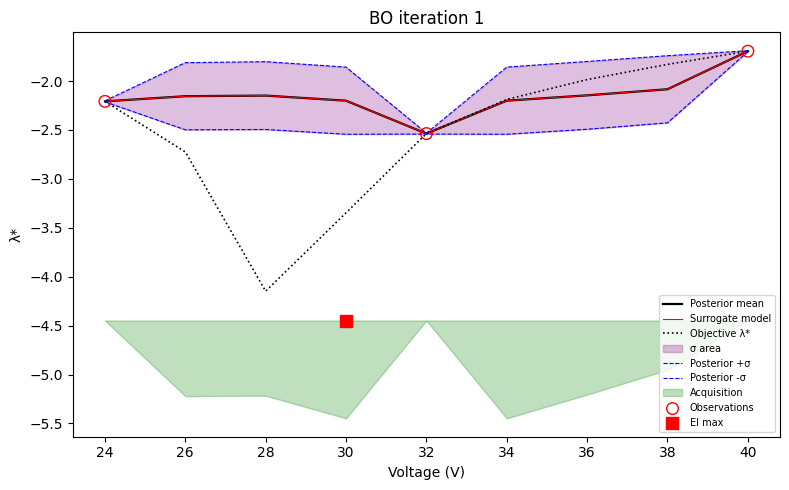

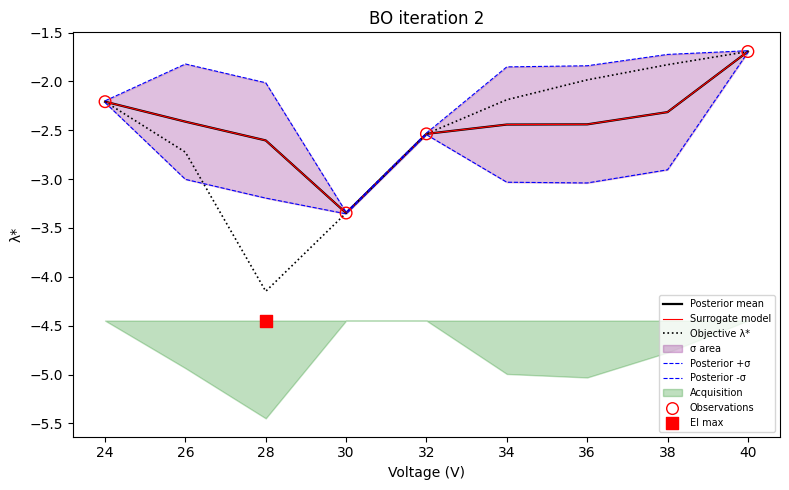

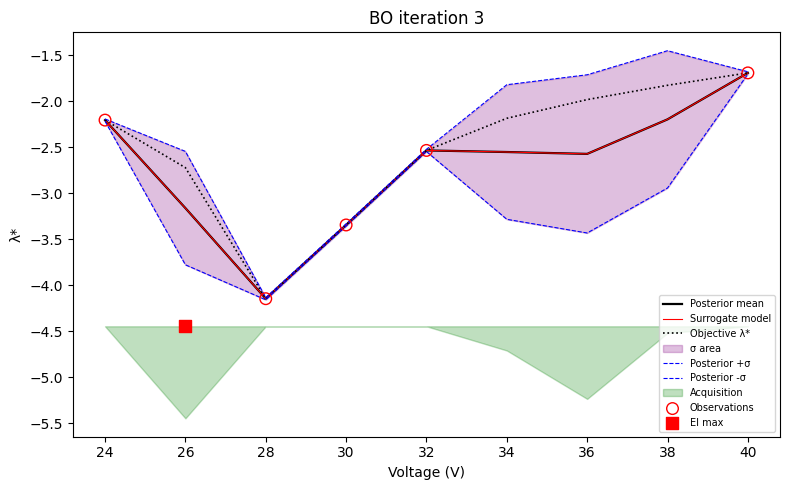

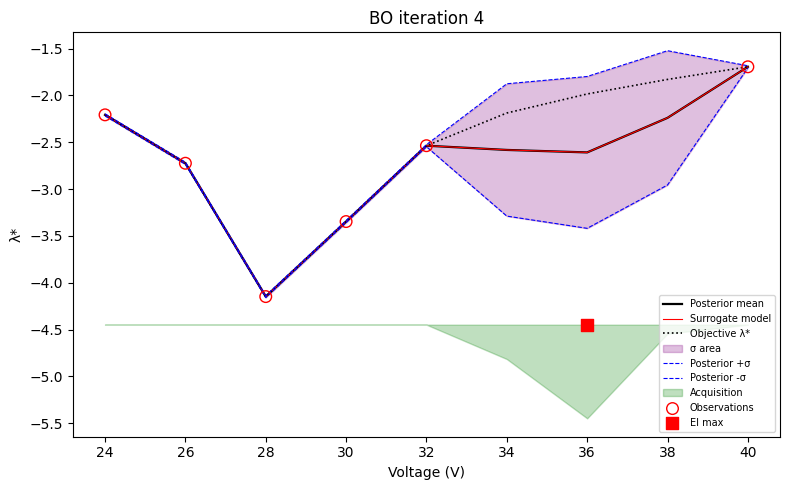

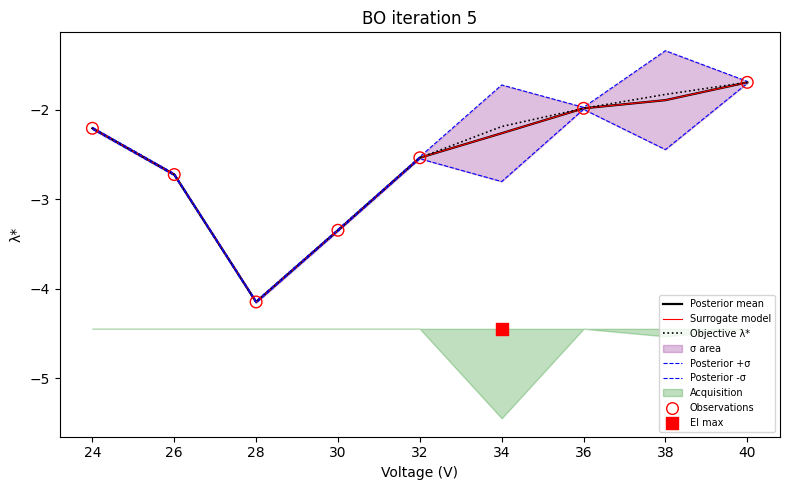

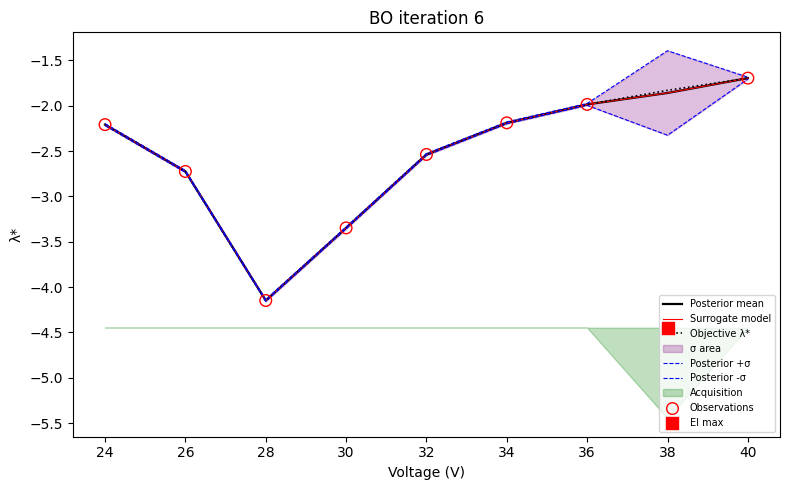

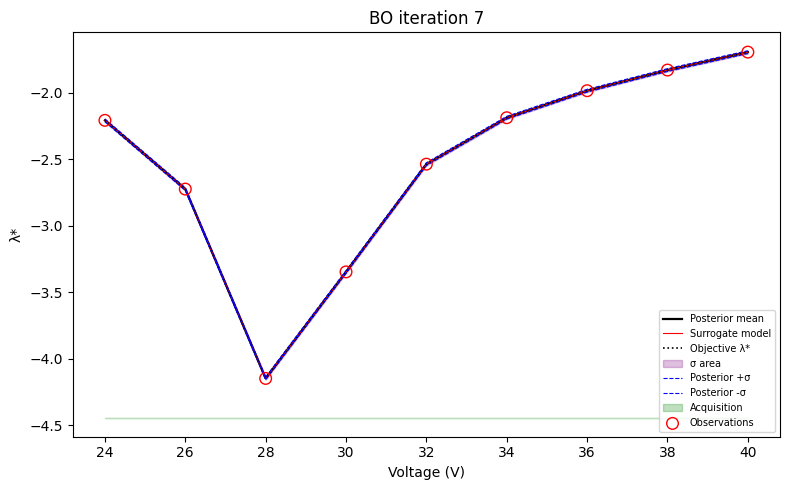

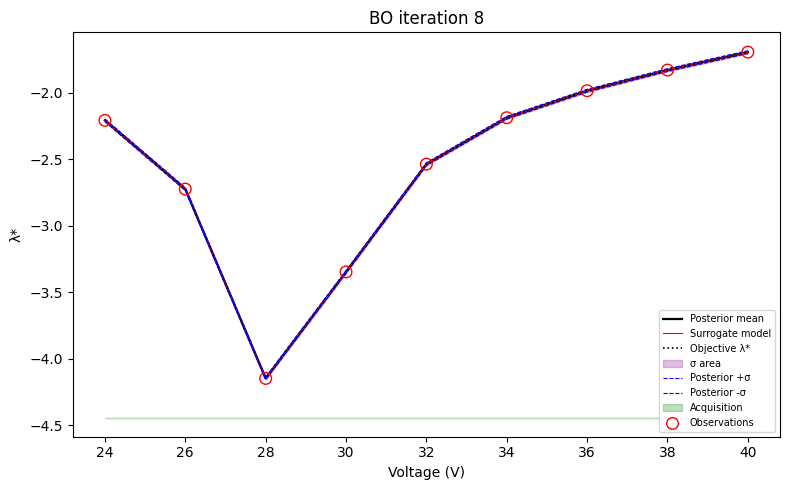

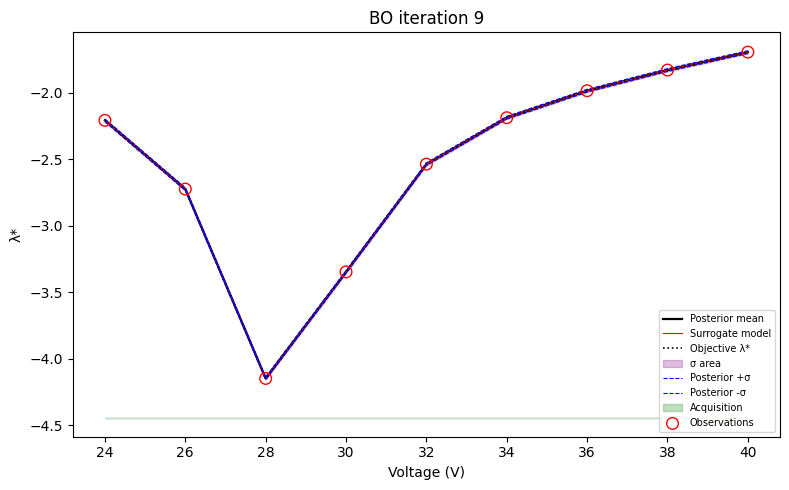

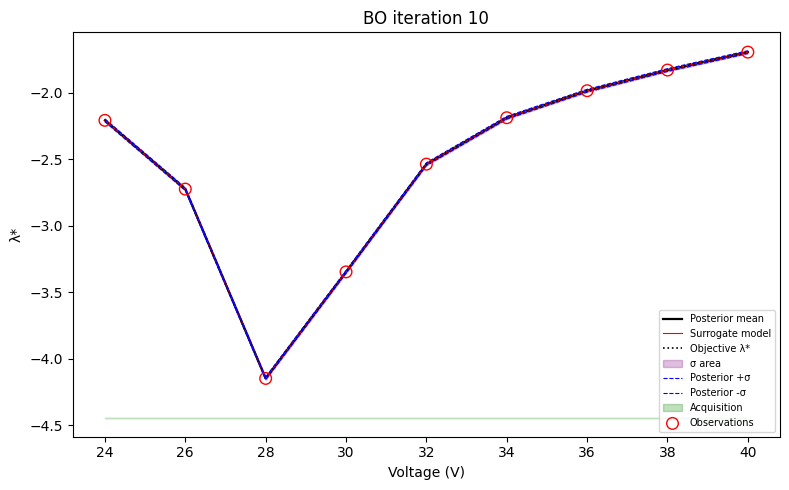

In [21]:
import re, numpy as np, matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from scipy.stats import norm        # EI 계산용 CDF/PDF

# ============================================================
# 0. 데이터 준비  ─ rows : ( … , wave_id )
# ============================================================
rows = [
    (15.76,0.0474,1114,1679.5,120,"v24"),
    (15.76,0.0474,1114,1679.5,121,"v26"),
    (15.76,0.0474,1114,1679.5,122,"v28"),
    (15.76,0.0474,1114,1679.5,123,"v30"),
    (15.76,0.0474,1114,1679.5,124,"v32"),
    (15.76,0.0474,1114,1679.5,125,"v34"),
    (15.76,0.0474,1114,1679.5,126,"v36"),
    (15.76,0.0474,1114,1679.5,127,"v38"),
    (15.76,0.0474,1114,1679.5,128,"v40"),
]

# --- 전압[V] 추출 → GP 입력 X --------------------------------
voltage_grid = np.array([int(re.sub(r"\D","", r[5])) for r in rows],  ### NEW ###
                        dtype=float).reshape(-1,1)                   # (9,1)

# true_lambda : 각 행에 대한 λ* (이미 계산해 둔다고 가정)
# e.g. true_lambda = np.array([...])  # shape (9,)

# ============================================================
# 1. GP 커널
# ============================================================
kernel = (ConstantKernel(1.0,(1e-2,1e2))
          * Matern(length_scale=1.0,nu=2.5)
          + WhiteKernel(noise_level=1e-4))

# ============================================================
# 2. 초기 관측 – 전압 24 V, 32 V, 40 V  (index 0,4,8)
# ============================================================
init_idx = [0,4,8]
obs_mask = np.zeros(len(rows),bool)
obs_mask[init_idx] = True

max_iter = 10
for it in range(max_iter):
    # --------------------------------------------------------
    # (1) GP 학습
    # --------------------------------------------------------
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
    gp.fit(voltage_grid[obs_mask],          # X_obs : (n_obs,1)   
           true_lambda[obs_mask])           # y_obs

    mu, std = gp.predict(voltage_grid, return_std=True)  

    # --------------------------------------------------------
    # (2) Expected Improvement
    # --------------------------------------------------------
    f_best = true_lambda[obs_mask].min()
    sigma  = np.maximum(std, 1e-9)
    z = (f_best - mu)/sigma
    ei = (f_best - mu)*norm.cdf(z) + sigma*norm.pdf(z)
    ei[obs_mask] = 0.0
    ei_norm = ei / (ei.max() + 1e-12)

    # --------------------------------------------------------
    # (3) 시각화
    # --------------------------------------------------------
    plt.figure(figsize=(8,5))

    plt.plot(voltage_grid, mu, 'k-', lw=1.6, label='Posterior mean')
    plt.plot(voltage_grid, mu, 'r-', lw=0.8, label='Surrogate model')
    plt.plot(voltage_grid, true_lambda, 'k:', lw=1.2, label='Objective λ*')

    plt.fill_between(voltage_grid.flatten(), mu-std, mu+std,
                     color='purple', alpha=0.25, label='σ area')
    plt.plot(voltage_grid, mu+std, 'b--', lw=0.8, label='Posterior +σ')
    plt.plot(voltage_grid, mu-std, 'b--', lw=0.8, label='Posterior -σ')

    ei_offset = true_lambda.min() - 0.3
    plt.fill_between(voltage_grid.flatten(), ei_offset,
                     ei_offset - ei_norm,
                     color='green', alpha=0.25, label='Acquisition')

    plt.scatter(voltage_grid[obs_mask], true_lambda[obs_mask],
                facecolors='none', edgecolors='red', s=70,
                zorder=5, label='Observations')

    if (~obs_mask).any():
        next_idx = int(np.argmax(ei))
        plt.scatter(voltage_grid[next_idx], ei_offset, marker='s',
                    color='red', s=80, zorder=6, label='EI max')

    plt.xlabel('Voltage (V)')               ### NEW ###
    plt.ylabel('λ*')
    plt.title(f'BO iteration {it+1}')
    plt.legend(loc='lower right', fontsize=7)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # (4) 관측 집합 업데이트
    # --------------------------------------------------------
    if (~obs_mask).any():
        obs_mask[next_idx] = True


---


[01] ls=[0.6931472 0.6931472 0.6931472 0.6931472 0.6931472 0.6931472], out=6.331e-02, noise=6.342e-02
[02] ls=[5.106795  5.055311  5.073879  2.1241665 5.1058316 5.106177 ], out=7.563e-02, noise=4.469e-02
[03] ls=[6.4060946 6.3126025 6.2938933 5.34624   5.9109383 1.0371886], out=2.508e-01, noise=7.189e-03
[04] ls=[ 7.705173   7.5412226 15.3813715 23.81373    6.688175   1.2871795], out=4.510e-01, noise=1.376e-03
[05] ls=[ 7.3339276  7.1639366 11.10873   25.700308   7.384197   0.9731529], out=3.781e-01, noise=3.562e-04
[06] ls=[ 7.066886   6.939519  11.582636  12.112617   8.000826   1.0740542], out=3.419e-01, noise=1.517e-04
[07] ls=[7.0083303 6.855377  9.196028  6.2546325 6.7049837 1.1652101], out=3.645e-01, noise=1.004e-04
[08] ls=[6.327155   6.165435   6.2568307  0.33765414 5.839938   1.2075921 ], out=5.416e-01, noise=1.000e-04
[09] ls=[6.05015   5.882131  6.0274014 0.4001181 5.56985   1.1153865], out=4.867e-01, noise=1.000e-04
[10] ls=[5.99018   5.8157263 5.9741445 0.7562751 5.574166 

c:\Users\HMCL-252\anaconda3\envs\myenv\lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-06.
  warnings.warn(


[14] ls=[6.4978957 6.2481294 7.454614  0.8558433 6.027648  1.0951257], out=6.024e-01, noise=1.000e-04
[15] ls=[6.542782  6.279988  5.8152437 0.7009879 5.808162  1.1614897], out=8.461e-01, noise=1.000e-04
[16] ls=[5.347071   5.1283545  5.2033014  0.17727019 4.8659687  1.356221  ], out=7.929e-01, noise=1.000e-04
[17] ls=[6.3534193 6.0810485 4.4821115 1.2740996 5.3462796 1.073415 ], out=7.879e-01, noise=1.000e-04
[18] ls=[6.419017  6.1309824 5.648014  0.503583  5.6935735 1.1792214], out=7.889e-01, noise=1.000e-04
[19] ls=[6.3768516  6.069378   4.7241864  0.98270667 5.3766303  1.0886059 ], out=7.410e-01, noise=1.000e-04
[20] ls=[6.5174203 6.180555  6.24225   0.5405118 5.905664  1.1843544], out=7.418e-01, noise=1.000e-04


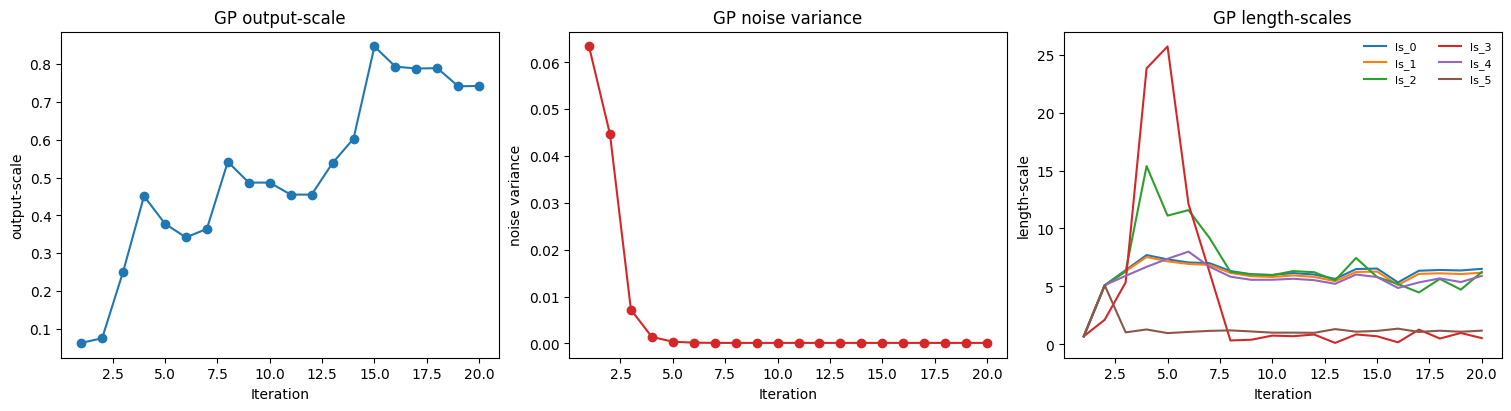

In [23]:
# ======================================================================
# 0) 라이브러리 · 환경 ----------------------------------------------------
# ======================================================================
import math, os, numpy as np, torch, gpytorch, pandas as pd, matplotlib.pyplot as plt
from gpytorch.mlls import ExactMarginalLogLikelihood
from typing import Dict, List, Tuple

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float32)
torch.manual_seed(0); np.random.seed(0)

# ======================================================================
# 1) DeepONet, WAVE_DB, model  ------------------------------------------
#  - DeepONet는 반드시 스칼라 5차원(branch1 입력=5) 버전이어야 함
#  - WAVE_DB: {'v24': np.ndarray(300,), ...}가 준비되어 있어야 함
# ======================================================================

# ──────────────────────────────────────────────────────────────────────
# 1-A) bo_objective  (DeepONet → λ*)
#    변경: p 제거 → candidate = (mu, sigma, rho, c_val, t_us, wid)
# ──────────────────────────────────────────────────────────────────────
def bo_objective(candidate,
                 model,
                 wave_db,
                 device: torch.device = torch.device("cpu")) -> float:
    """Return λ* (ln(r_fin / r_pinch)); more-negative ⇒ faster decay."""
    mu, sigma, rho, c_val, t_us, wid = candidate  # ★ p 제거

    # waveform
    wave = wave_db[wid]                                # KeyError → 전파
    if wave.shape[0] != 300:
        raise ValueError("waveform length must be exactly 300")

    # x1: (1,5), x2: (1,300)
    x1 = torch.tensor([mu, sigma, rho, c_val, t_us],
                      dtype=torch.float32, device=device).unsqueeze(0)   # ★ 6→5
    x2 = torch.from_numpy(wave.astype(np.float32)).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        q_hat = model(x1, x2).squeeze(0)               # (300,)

    idx_pinch = int(t_us) - 1
    if not 0 <= idx_pinch < 300:
        raise ValueError("t_us must be in [1, 300]")
    r_pinch = q_hat[idx_pinch].abs() + 1e-12
    r_fin   = q_hat[-1].abs()        + 1e-12
    return torch.log(r_fin / r_pinch).item()

# ======================================================================
# 2) wave_id ↔ 정수 매핑 -------------------------------------------------
# ======================================================================
wave_ids = sorted(WAVE_DB.keys())          # e.g. ['v1', 'v2', ...]
id2idx   = {wid: i for i, wid in enumerate(wave_ids)}
idx2id   = {i: wid for wid, i in id2idx.items()}

def enc(mu, sigma, rho, c, t_us, wid):
    """Encode candidate → (6,) tensor [mu, sigma, rho, c, t_us, wid_idx]."""
    return torch.tensor([mu, sigma, rho, c, t_us, float(id2idx[wid])],
                        dtype=torch.float32)                       # ★ p 제거, 길이 6

def dec(x: torch.Tensor):
    """Decode (6,) tensor back to tuple with wave_id string."""
    mu, sigma, rho, c, t_us, idx_f = x.tolist()
    return (mu, sigma, rho, c, t_us, idx2id[int(idx_f)])          # ★ 6개 체계

# ======================================================================
# 3) GP 모델 정의 --------------------------------------------------------
# ======================================================================
class ExactGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module  = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=train_x.shape[-1])
        )
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x= self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def extract_hp(model: ExactGP) -> Dict[str, np.ndarray]:
    base = model.covar_module.base_kernel
    return {
        "lengthscale": base.lengthscale.detach().cpu().numpy().ravel(),
        "outputscale": model.covar_module.outputscale.detach().cpu().item(),
        "noise":      model.likelihood.noise.detach().cpu().item()
    }

# ======================================================================
# 4) Expected Improvement ----------------------------------------------
# ======================================================================
import torch.distributions as D
def expected_improvement(mu, sigma, f_best, xi=0.0):
    sigma = sigma.clamp_min(1e-9)
    z     = (f_best - mu - xi) / sigma            # minimization
    std   = D.Normal(torch.zeros_like(mu), torch.ones_like(mu))
    return (f_best - mu - xi)*std.cdf(z) + sigma*torch.exp(std.log_prob(z))

# ======================================================================
# 5) Bayesian-Optimisation 루프 -----------------------------------------
# ======================================================================
def bayes_optimize(train_x, train_y, cand_pool,
                   wave_db, deepONet,
                   n_iter=15, lr=0.1, opt_steps=200, batch=128):

    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(DEVICE)
    hp_log: List[Dict] = []

    for it in range(1, n_iter+1):
        # --- GP 학습 ---------------------------------------------------
        gp = ExactGP(train_x, train_y, likelihood).to(DEVICE)
        gp.train(); likelihood.train()
        mll   = ExactMarginalLogLikelihood(likelihood, gp)
        optim = torch.optim.Adam(gp.parameters(), lr=lr)
        for _ in range(opt_steps):
            optim.zero_grad()
            loss = -mll(gp(train_x), train_y)
            loss.backward(); optim.step()
        gp.eval(); likelihood.eval()

        # --- 하이퍼 기록 -----------------------------------------------
        hp = extract_hp(gp); hp["iter"] = it; hp_log.append(hp)
        print(f"[{it:02d}] ls={hp['lengthscale']}, "
              f"out={hp['outputscale']:.3e}, noise={hp['noise']:.3e}")

        # --- EI 최대 후보 선택 -----------------------------------------
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            mu_all, sig_all = [], []
            for j in range(0, cand_pool.shape[0], batch):
                xb = cand_pool[j:j+batch].to(DEVICE)
                pred = likelihood(gp(xb))
                mu_all.append(pred.mean); sig_all.append(pred.stddev)
            mu, sig = torch.cat(mu_all), torch.cat(sig_all)

        ei  = expected_improvement(mu, sig, train_y.min().item())
        idx = torch.argmax(ei).item()
        x_n = cand_pool[idx:idx+1]

        # --- DeepONet 평가 --------------------------------------------
        y_val = bo_objective(dec(x_n[0]), model=deepONet,
                             wave_db=wave_db, device=DEVICE)
        y_n   = torch.tensor([y_val], dtype=torch.float32, device=DEVICE)

        train_x = torch.cat([train_x, x_n.to(DEVICE)], 0)
        train_y = torch.cat([train_y, y_n], 0)

    return train_x, train_y, hp_log

# ======================================================================
# 6) 초기 데이터 ---------------------------------------------------------
#    변경: p 제거 → 각 튜플은 (mu, sigma, rho, c, t_us, wid)
# ======================================================================
init_rows = [
    (15.76, 0.0474, 1114, 1679.5, 120, "v24"),
    (15.50, 0.0550, 1120, 1650.0, 125, "v26"),
    (16.00, 0.0400, 1100, 1700.0, 115, "v28"),
]
train_x0 = torch.stack([enc(*r) for r in init_rows]).to(DEVICE)      # (N0, 6)
train_y0 = torch.tensor(
    [bo_objective(r, model=model, wave_db=WAVE_DB, device=DEVICE)
     for r in init_rows],
    dtype=torch.float32, device=DEVICE)                               # (N0,)

# ======================================================================
# 7) 탐색 풀 샘플 (예시 200개) ------------------------------------------
#    변경: enc(mu, sigma, rho, c, t_us, wid)  ← p 제거
# ======================================================================
rng = np.random.default_rng(0)
cand_pool = []
for _ in range(200):
    mu, sigma = rng.uniform(15, 17), rng.uniform(0.03, 0.06)
    rho, c    = rng.uniform(1090, 1130), rng.uniform(1550, 1750)
    t_us      = int(rng.integers(110, 130))          # 보통 정수 시간 인덱스
    wid       = rng.choice(wave_ids)
    cand_pool.append(enc(mu, sigma, rho, c, t_us, wid))              # ★ p 제거
cand_pool = torch.stack(cand_pool)                                   # (200, 6)

# ======================================================================
# 8) BO 실행 ------------------------------------------------------------
# ======================================================================
_, _, hp_log = bayes_optimize(train_x0, train_y0, cand_pool,
                              WAVE_DB, model, n_iter=20)

# ======================================================================
# 9) 하이퍼파라미터 시각화 ---------------------------------------------
# ======================================================================
hp_df   = pd.DataFrame(hp_log)
len_dim = hp_df["lengthscale"][0].size
ls_cols = [f"ls_{i}" for i in range(len_dim)]
hp_df[ls_cols] = pd.DataFrame(hp_df["lengthscale"].tolist(), index=hp_df.index)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

# (a) output-scale
axes[0].plot(hp_df["iter"], hp_df["outputscale"], marker='o')
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("output-scale")
axes[0].set_title("GP output-scale")

# (b) noise
axes[1].plot(hp_df["iter"], hp_df["noise"], marker='o', color='tab:red')
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("noise variance")
axes[1].set_title("GP noise variance")

# (c) length-scales (ARD)
for i, col in enumerate(ls_cols):
    axes[2].plot(hp_df["iter"], hp_df[col], label=col)
axes[2].set_xlabel("Iteration"); axes[2].set_ylabel("length-scale")
axes[2].set_title("GP length-scales")
axes[2].legend(fontsize=8, ncol=2, frameon=False)
plt.show()


In [24]:
# ── CSV 저장 ───────────────────────────────────────────────────
hp_df[['iter', 'outputscale']].to_csv('gp_outputscale.csv', index=False)

hp_df[['iter', 'noise']].to_csv('gp_noise.csv', index=False)

hp_df[['iter'] + ls_cols].to_csv('gp_lengthscales.csv', index=False)
